# 리워드 광고 평가 축 기반 EDA

## 0. 프로젝트 문제 정의

이 프로젝트는 리워드 광고를 단순 클릭수나 CVR만으로 평가하지 않고, 반응성, 수익성, 안정성, 규모를 함께 고려하여 운영팀이 광고 확대/유지/점검/중단 후보를 판단할 수 있는 기준을 만드는 것을 목표로 한다.


### 0-1. 프로젝트 문제 정의 요약

**분석 배경**

리워드 광고는 클릭만 많다고 운영 가치가 높은 광고로 판단하기 어렵다. 유저가 광고를 클릭하더라도 완료까지 이어지지 않으면 광고주가 원하는 성과로 연결되지 않는다. 완료가 발생하더라도 리워드 비용이 커서 마진이 낮다면 플랫폼 관점에서도 좋은 성과로 보기 어렵다.

**분석 목적**

클릭 → 완료 → 반복 참여 → 수익성까지 이어지는 퍼널 관점으로 광고 성과를 재정의하고, 운영팀이 광고 확대/유지/점검/중단 후보를 판단할 수 있는 1차 평가 기준을 정리한다.

**분석 구조**

- **반응성** : 유저가 광고에 얼마나 잘 반응하고, 클릭이 완료까지 이어지는지 확인한다.
- **수익성** : 광고 반응이 실제 마진으로 연결되는지 확인한다.
- **안정성** : 성과가 일시적 현상이 아니라 관측 기간 동안 유지되는지 확인한다.
- **규모** : 개별 광고의 성과가 전체 운영에 미치는 영향력을 확인한다.
- **운영 후보 분류** : 앞의 네 축을 바탕으로 광고를 확대, 유지, 점검, 재검토 후보로 나누는 1차 운영 판단 기준을 만든다.

**분석 원칙**

- 전체 집계 CVR은 출발점이며, 단독 결론으로 사용하지 않는다. 반응성 / 수익성 / 안정성 / 규모 지표를 함께 본다.
- 통계 검정은 각 분석 흐름 직후 이어서 해석한다.

**핵심 지표 해석 기준**

- 유형·카테고리·운영 액션처럼 여러 광고를 묶어 보여주는 대표 CVR은 `총완료수 / 총클릭수 × 100` 기준의 집계 CVR을 사용한다.
- 광고별 `cvr_pct`는 광고 단위 분포, 박스플롯, 통계 검정에서 사용한다.
- 따라서 CVR은 단독 효율 지표로 해석하지 않고, 클릭 규모·완료 규모·마진·반복 참여·시간대/매체 의존도와 함께 해석한다.


## 1. 분석 기준 테이블 생성

모든 축 분석에 공통으로 쓰는 기준 테이블을 준비한다.

pandas 기반 분석 테이블은 스토리·시각화·운영 후보 분류에 사용하고, polars 기반 mart는 반응성 / 수익성 / 안정성 / 규모 평가 테이블의 원천으로 사용한다.

### 1-1. 분석별 기준 모집단 정리

전체 현황:
- 전체 클릭/완료 구조 확인
- 기준: main_funnel 전체

광고 성과 분석:
- 광고별 CVR 과대평가 방지
- 기준: click_cnt >= 30

운영 후보 분류:
- 실제 운영 조정이 의미 있는 광고만 판단
- 기준: click_cnt >= 1,000

안정성 분석:
- 일정 기간 이상 관측된 광고만 신뢰도 판단
- 기준: active_days >= 8, 필요 시 초기/후기 클릭수 >= 30

D3 재참여 분석:
- 첫 완료 이후 재참여 가능성 확인
- 기준: 첫 완료 유저 기준, 광고별 최소 first_complete_user_cnt 조건 적용

In [1]:
# 분석 기준 설정

# 광고 성과 분석 최소 클릭 수
MIN_AD_CLICKS = 30

# 운영 후보 분류 최소 클릭 수
MIN_OPERATION_CLICKS = 1000

# 안정성 분석 최소 관측 일수
MIN_ACTIVE_DAYS = 5

# D3 재참여 분석 최소 첫 완료 유저 수
MIN_FIRST_COMPLETE_USERS = 100

### 1-2. 데이터 로딩 및 분석 기준

- `main_funnel`, `ad_outcome`, `finance_clean1`, `user_daily_activity_clean`은 반응성·수익성·안정성·규모 및 운영 후보 분류를 위한 상세 분석 기준 테이블로 사용한다.
- `sche_analysis`, `ad_attr_map`, `ads_join_info_labeled`는 Polars 기반 mart를 만들기 위한 기준 테이블로 사용한다.
- pandas 기반 테이블은 시각화·운영 후보 분류에 사용하고, Polars 기반 mart는 축 통합 평가 테이블을 구성하는 데 사용한다.

따라서 분석의 핵심 판단은 `클릭 → 완료 → 반복 참여 → 수익성/리스크` 흐름을 중심으로 한다.

In [2]:
pip install scikit-posthocs

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display, Markdown
from scipy.stats import kruskal, spearmanr, mannwhitneyu
from scikit_posthocs import posthoc_dunn


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", "{:,.2f}".format)

font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False
mpl.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.constrained_layout.use"] = False

sns.set_theme(style="whitegrid", font=font_name)

PALETTE_3 = ["#2B2D42","#8D99AE", "#EF233C", "#2A9D8F"]
SINGLE_COLOR = "#8D99AE"
BASE_COLOR = SINGLE_COLOR
GREEN_COLOR = "#2A9D8F"
LINE_COLOR = "#2B2D42"
RISK_COLOR = "#EF233C"
GRAY_COLOR = SINGLE_COLOR
COLORS = PALETTE_3

sns.set_palette(PALETTE_3)

def get_plot_colors(n, base_colors=PALETTE_3):
    """그룹 수가 3개 이하이면 지정 팔레트, 4개 이상이면 단일 색상을 적용한다."""
    if n <= 3:
        return base_colors[:n]
    return [SINGLE_COLOR] * n


def apply_box_colors(ax=None, colors=PALETTE_3):
    """seaborn/matplotlib boxplot의 박스 색상을 지정 규칙에 맞게 적용한다."""
    ax = ax or plt.gca()
    boxes = [patch for patch in ax.patches if hasattr(patch, "set_facecolor")]
    palette = get_plot_colors(len(boxes), colors)
    for patch, color in zip(boxes, palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    return ax


MIN_GROUP_N = 5

DATA_DIR = Path(r"C:/Users/hoo58/OneDrive/바탕 화면/tables/DATA/eda_ready_new")
OUTPUT_DIR = DATA_DIR / "integrated_eda_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("사용 중인 한글 폰트:", font_name)
print("EDA_ready 폴더:", DATA_DIR)


사용 중인 한글 폰트: Malgun Gothic
EDA_ready 폴더: C:\Users\hoo58\OneDrive\바탕 화면\tables\DATA\eda_ready_new


In [4]:
FILE_PATHS = {
    "main_funnel": DATA_DIR / "main_funnel.parquet",
    "ad_outcome": DATA_DIR / "ad_outcome.parquet",
    "finance_clean1": DATA_DIR / "finance_clean1.parquet",
    "user_daily_activity_clean": DATA_DIR / "user_daily_activity_clean.parquet",
}

main_funnel = pd.read_parquet(FILE_PATHS["main_funnel"])
ad_outcome = pd.read_parquet(FILE_PATHS["ad_outcome"])
finance_clean1 = pd.read_parquet(FILE_PATHS["finance_clean1"])
user_daily_activity_clean = pd.read_parquet(FILE_PATHS["user_daily_activity_clean"])

loaded_tables = {
    "main_funnel": main_funnel,
    "ad_outcome": ad_outcome,
    "finance_clean1": finance_clean1,
    "user_daily_activity_clean": user_daily_activity_clean,
}

load_summary = pd.DataFrame([
    {
        "테이블": table_name,
        "행 수": table.shape[0],
        "컬럼 수": table.shape[1],
        "경로": str(FILE_PATHS[table_name]),
    }
    for table_name, table in loaded_tables.items()
])

display(load_summary)


,테이블,행 수,컬럼 수,경로
0,main_funnel,3181777,43,C:\Users\hoo58\OneDrive\바탕 화면\tables\DATA\eda_...
1,ad_outcome,445260,22,C:\Users\hoo58\OneDrive\바탕 화면\tables\DATA\eda_...
2,finance_clean1,1474776,33,C:\Users\hoo58\OneDrive\바탕 화면\tables\DATA\eda_...
3,user_daily_activity_clean,1554523,25,C:\Users\hoo58\OneDrive\바탕 화면\tables\DATA\eda_...


In [5]:
def show_table(title, df, n=20):
    display(Markdown(f"**{title}**"))
    display(df.head(n))


def safe_divide(numerator, denominator, scale=1):
    return np.where(denominator > 0, numerator / denominator * scale, np.nan)
#클릭당 마진, 완료당 마진처럼 “나눗셈 기반 지표”를 계산할 때 분모가 0인 경우를 NaN으로 처리해서 결과가 이상해지지 않게 하는 함수.

In [6]:
def shorten_label(value, max_len=18):
    text = "" if pd.isna(value) else str(value)
    text = text.replace("\n", " ").strip()

    if len(text) <= max_len:
        return text

    return text[: max_len - 1] + "…"
#긴 광고명·유형명·카테고리명을 그래프/표에서 보기 좋게 max_len 길이로 줄이고, 잘린 부분은 …로 표시하는 함수.

def make_ranked_labels(df, name_col="ads_name", id_col="ads_idx", max_len=18):
    labels = []
    names = df[name_col].astype(str)
    name_counts = names.value_counts()

    for rank, (_, row) in enumerate(df.iterrows(), start=1):
        raw_name = str(row[name_col])
        name = shorten_label(raw_name, max_len=max_len)

        if name_counts.get(raw_name, 0) > 1:
            labels.append(f"{rank}. {name} ({row[id_col]})")
        else:
            labels.append(f"{rank}. {name}")

    return labels
#TOP10 그래프 같은 순위형 시각화에서 “순위 번호 + 짧은 광고명” 라벨을 만들고, 같은 광고명이 여러 개면 ads_idx까지 붙여서 구분해주는 함수.


In [7]:
def plot_ranked_barh(
    ax,
    df,
    value_col,
    title,
    xlabel,
    color=BASE_COLOR,
    total_value=None,
    name_col="ads_name",
    id_col="ads_idx",
    max_label_len=18,
    value_format="{:,.0f}",
):
    plot_df = df.reset_index(drop=True).copy()
    values = plot_df[value_col].fillna(0).to_numpy()
    labels = make_ranked_labels(
        plot_df,
        name_col=name_col,
        id_col=id_col,
        max_len=max_label_len,
    )

    y_pos = np.arange(len(plot_df))

    ax.barh(y_pos, values, color=color, alpha=0.9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.3)

    max_value = np.nanmax(values) if len(values) > 0 else 0

    if max_value > 0:
        ax.set_xlim(0, max_value * 1.45)

        for i, value in enumerate(values):
            if total_value is not None and total_value > 0:
                pct = value / total_value * 100
                label = f"{value_format.format(value)} ({pct:.1f}%)"
            else:
                label = value_format.format(value)

            ax.text(
                value + max_value * 0.015,
                i,
                label,
                va="center",
                ha="left",
                fontsize=10,
                clip_on=False,
            )
#순위형 데이터프레임을 받아서, 순위 번호가 붙은 라벨과 값 표시까지 포함한 가로 막대그래프를 자동으로 그리는 시각화용 함수.

In [8]:
def label_barh(ax, values, fmt="{:,.0f}"):
    max_value = pd.Series(values).max()

    for i, value in enumerate(values):
        if pd.notna(value):
            ax.text(value, i, " " + fmt.format(value), va="center", fontsize=9)

    if pd.notna(max_value) and max_value > 0:
        ax.set_xlim(0, max_value * 1.25)
#가로 막대그래프의 각 막대 끝에 실제 숫자 값을 표시하고, 숫자가 잘리지 않도록 x축 범위를 넓혀주는 시각화 보조 함수.

In [9]:
def make_lorenz(values):
    values = pd.Series(values).fillna(0)
    values = values[values >= 0]

    if len(values) == 0 or values.sum() <= 0:
        return pd.DataFrame({"x": [0, 1], "y": [0, 1]})

    shares = values / values.sum()
    sorted_shares = np.sort(shares.to_numpy())
    y = np.cumsum(sorted_shares) / sorted_shares.sum()
    x = np.linspace(0, 1, len(y))

    return pd.DataFrame({"x": x, "y": y})
#로렌츠 곡선을 그리기 위한 x, y 좌표를 계산하는 함수. 입력값이 모두 0이거나 음수인 경우에는 대각선(완전 평등)을 나타내는 (0,0)에서 (1,1)로 이어지는 선분 좌표를 반환.

def hhi(values):
    values = pd.Series(values).fillna(0)
    total = values.sum()

    if total <= 0:
        return np.nan

    shares = values / total
    return float((shares ** 2).sum())
#시장 집중도를 나타내는 지표인 HHI를 계산하는 함수. 입력값이 모두 0이거나 음수인 경우에는 NaN을 반환.

In [10]:
# 광고 단위 성과 분석 기준: 클릭 30건 이상 광고를 기본 분석 대상으로 사용한다.

ad_outcome_work = ad_outcome.copy()

ad_df = ad_outcome_work[
    ad_outcome_work["click_cnt"] >= MIN_AD_CLICKS
].copy()

# 기본 분석용 광고유형은 전처리에서 확정된 analysis_ads_type_label을 사용한다.
type_col = "analysis_ads_type_label"

print("광고 단위 전체 행 수:", len(ad_outcome_work))
print(f"광고 성과 분석 대상 행 수(click>={MIN_AD_CLICKS}):", len(ad_df))
print("광고유형 기준 컬럼:", type_col)

광고 단위 전체 행 수: 445260
광고 성과 분석 대상 행 수(click>=30): 3628
광고유형 기준 컬럼: analysis_ads_type_label


In [11]:
# main_funnel 시간대/유저 분석용 복사본
main_funnel_work = main_funnel.copy()

main_funnel_work["click_date_dt"] = pd.to_datetime(main_funnel_work["click_date"], errors="coerce")
main_funnel_work["regdate"] = pd.to_datetime(main_funnel_work["regdate"], errors="coerce")
main_funnel_work["click_date_only"] = main_funnel_work["click_date_dt"].dt.date
main_funnel_work["click_hour"] = main_funnel_work["click_date_dt"].dt.hour
main_funnel_work["click_weekday"] = main_funnel_work["click_date_dt"].dt.day_name().map({
    "Monday": "월",
    "Tuesday": "화",
    "Wednesday": "수",
    "Thursday": "목",
    "Friday": "금",
    "Saturday": "토",
    "Sunday": "일",
})

main_funnel_work["is_completed"] = (
    pd.to_numeric(main_funnel_work["is_completed"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# main_funnel에는 광고유형 라벨이 이미 포함되어 있으므로 그대로 사용한다.
print("main_funnel_work 광고유형 라벨 결측률:", main_funnel_work[type_col].isna().mean())
print("main_funnel_work 광고유형 수:", main_funnel_work[type_col].nunique(dropna=True))


# user_daily 분석용 복사본
user_daily_work = user_daily_activity_clean.copy()

user_daily_work["active_date_dt"] = pd.to_datetime(user_daily_work["active_date"], errors="coerce")
user_daily_work["active_date_only"] = user_daily_work["active_date_dt"].dt.date
user_daily_work["weekday_ko"] = user_daily_work["active_date_dt"].dt.day_name().map({
    "Monday": "월",
    "Tuesday": "화",
    "Wednesday": "수",
    "Thursday": "목",
    "Friday": "금",
    "Saturday": "토",
    "Sunday": "일",
})

user_daily_work["start_hour"] = pd.to_numeric(user_daily_work["start_hour"], errors="coerce")



main_funnel_work 광고유형 라벨 결측률: 0.0
main_funnel_work 광고유형 수: 10


### 1-3. Polars 기준 테이블 로드

이미 저장된 EDA-ready parquet를 읽어 mart를 구성하는 단계부터 시작한다.

In [12]:
import polars as pl

POLARS_EDA_DIR = Path(r"C:/Users/hoo58/OneDrive/바탕 화면/tables/DATA/eda_ready_new")

df_sche_analysis = pl.read_parquet(POLARS_EDA_DIR / "sched_clean.parquet")  # sche_analysis 없음
df_list = pl.read_parquet(POLARS_EDA_DIR / "ad_attr_map.parquet")
main_funnel_for_eda = pl.read_parquet(POLARS_EDA_DIR / "ads_join_info_labeled.parquet")

In [13]:
# EDA-ready 라벨 매핑 기준
# - 현재 분석 기준은 기존 ads_type 기반 라벨을 사용한다.
# - 버트토픽/action_type_5는 아직 적용하지 않는다.

ADS_TYPE_LABEL_MAP = {
    1: "설치형",
    2: "실행형",
    3: "참여형",
    4: "클릭형",
    5: "제휴",
    6: "트위터",
    7: "인스타",
    8: "노출형",
    9: "퀘스트",
    10: "유튜브",
    11: "네이버",
    12: "CPS(물건구매)",
}

CATEGORY_LABEL_MAP = {
    0: "선택안함",
    1: "앱(간편적립)",
    2: "경험하기(CPI/CPE)",
    3: "구독(간편적립)",
    4: "간편미션-퀴즈",
    5: "경험하기(CPA)",
    6: "멀티보상(게임)",
    7: "금융(참여)",
    8: "무료참여",
    10: "유료참여",
    11: "쇼핑-상품별",
    12: "제휴몰",
    13: "간편미션",
}

### 1-4. 파생 테이블 및 플래그 적용 기준

1. `main_funnel_for_eda`는 `df_fact_clean` 기반
   - 수익성/안정성 평가에서도 재사용할 수 있는 공통 베이스

2. 반응성 분석은 `remove_cond2_flag == False`만 남긴 뒤 다시 집계
   - 클릭수, 완료수, CVR은 사용자 행동 지표라서 비정상 참여/이상 참여일의 영향을 직접 받음

3. 수익성 집계(`finance_daily`)는 `main_funnel_for_eda` 기준으로 유지

4. 규모(impact)는 `main_funnel_for_eda`, `ads_eval` 기반
   - 총 클릭수, 총 완료수, 전체 클릭/완료 기여율, 관측 일수 등을 관측하기 위함

5. `mart`는 광고 × 일자 단위의 공통 분석 테이블 
   - 단, `click_cnt`, `complete_cnt`, `daily_cvr`는 반응성 기준에 맞춰 `reaction_daily` 값으로 교체


### 1-5. 분석 기준 정리

| 분석 축 | 핵심 질문 | 주요 지표 | 적용 기준 |
|---|---|---|---|
| 반응성 | 유저가 잘 반응했는가? | 클릭수, 완료수, CVR | `remove_cond2_flag == False` |
| 수익성 | 돈이 되는 광고인가? | 마진, 클릭당 마진, 완료당 마진 | `df_fact_clean` 기반, 필요 시 이상 여부 비교 |
| 안정성 | 성과가 꾸준한가? | `observed_stage`별 변동성, 표준편차 | `df_fact_clean` 기반, 필요 시 별도 비교 |
| 규모(운영 영향력) | 전체 성과에 얼마나 크게 기여했는가? | 총 클릭수, 총 완료수, 클릭/완료 기여율, 관측 일수 | 광고 단위 집계(`ads_eval`) 기준 |


### 기준 테이블 grain 정리

| 테이블/변수 | grain | 역할 | 주의점 |
|---|---|---|---|
| main_funnel | 클릭 1행 | 전체 클릭-완료 원천 흐름 확인 | 원천 이벤트 단위이므로 광고 단위 지표와 직접 비교하지 않는다 |
| main_funnel_for_eda | 클릭 1행 | Polars 기반 EDA 공통 베이스 | 반응성은 `remove_cond2_flag == False` 적용 후 재집계한다 |
| reaction_daily | 광고 × 일자 1행 | 반응성 지표 집계 | `click_cnt`, `complete_cnt`, `daily_cvr` 기준 |
| finance_daily | 광고 × 일자 1행 | 수익성 지표 집계 | `daily_observed_margin`, `daily_valid_margin` 구분 |
| mart | 광고 × 일자 1행 | 반응성·수익성·안정성·규모 통합 기준 | 광고 단위 분석 전에는 반드시 `ads_idx` 기준으로 재집계한다 |
| ads_stage_perf | 광고 × observed_stage 1행 | 초기/유지 구간별 성과 비교 | `observed_stage` 기준의 중간 테이블 |
| ads_eval | 광고 1행 | 광고 단위 최종 평가 테이블 | `total_click_cnt`, `total_cvr`, `total_valid_margin_per_complete` 기준 |
| ad_df | 광고 1행 | pandas 기반 광고 성과 분석 테이블 | `ad_outcome`에서 `click_cnt >= MIN_AD_CLICKS` 적용 |
| operation_candidates | 광고 1행 | 운영 액션 분류 결과 | `MIN_OPERATION_CLICKS` 이상 광고 중심으로 해석 |

In [14]:
# main_funnel_for_eda 기본 타입 정리
# main_funnel_for_eda는 df_fact_clean 기반
# 뒤에서 수익성/안정성까지 재사용할 공통 베이스
# 반응성만 별도로 remove_cond2_flag를 적용해 다시 집계
# mart 생성 전 key 컬럼 타입을 먼저 맞춤

main_funnel_for_eda = main_funnel_for_eda.with_columns([
    pl.col("ads_idx").cast(pl.String).alias("ads_idx"),
    # click_day는 광고 클릭 날짜.
    # 광고 × 일자 단위 mart의 날짜 key로 사용하므로 Date 타입으로 통일.
    pl.col("click_day").cast(pl.Date, strict=False).alias("click_day"),
    pl.col("click_date").cast(pl.Datetime, strict=False).alias("click_date"),
    pl.col("click_time").cast(pl.Int64, strict=False).alias("click_time"),
    pl.col("dvc_idx").cast(pl.String).alias("dvc_idx"),
    pl.col("mda_idx").cast(pl.String).alias("mda_idx"),

    # 아래 비용/수익 컬럼은 집계 대상.
    # 문자열/정수/실수 혼재 가능성을 줄이기 위해 Float64로 맞추고,
    # 결측값은 합계 계산에서 문제가 없도록 0으로 채운다.
    pl.col("show_cost").cast(pl.Float64, strict=False).fill_null(0).alias("show_cost"),
    pl.col("adv_cost").cast(pl.Float64, strict=False).fill_null(0).alias("adv_cost"),
    pl.col("earn_cost").cast(pl.Float64, strict=False).fill_null(0).alias("earn_cost"),
    pl.col("rwd_cost").cast(pl.Float64, strict=False).fill_null(0).alias("rwd_cost"),
    # margin도 뒤에서 합계/클릭당/완료당 계산에 사용되므로 숫자형으로 맞춘다.
    pl.col("margin").cast(pl.Float64, strict=False).fill_null(0).alias("margin"),
    # remove_cond2_flag는 반응성 분석에서 사용할 행 제거 기준.
    # 결측은 False로 두어, flag가 없는 행을 실수로 제거하지 않게 한다.
    pl.col("remove_cond2_flag").cast(pl.Boolean, strict=False).fill_null(False).alias("remove_cond2_flag"),
])

# 재무 이상 플래그 재확인
main_funnel_for_eda = main_funnel_for_eda.with_columns([
    # show_cost가 0원 또는 1원일 때
    (pl.col("show_cost") <= 1).alias("flag_show_cost_low"),
    # adv_cost가 0원일 때
    (pl.col("adv_cost") == 0).alias("flag_adv_cost_zero"),
])

main_funnel_for_eda = main_funnel_for_eda.with_columns([
    (
        pl.col("flag_show_cost_low") |
        pl.col("flag_adv_cost_zero")
    ).alias("is_finance_anomaly")
])

main_funnel_for_eda.select([
    "ads_idx",
    "click_day",
    "show_cost",
    "adv_cost",
    "margin",
    "remove_cond2_flag",
    "flag_show_cost_low",
    "flag_adv_cost_zero",
    "is_finance_anomaly"
]).head()

# 규모 축의 유입 다양성 분석에서 사용한다.
df_fact_clean2 = main_funnel_for_eda.filter(pl.col("remove_cond2_flag") == False)

In [15]:
# mart 기본 뼈대 생성
# 광고 × 일자 단위
# 반응성 컬럼은 뒤에서 reaction_daily 기준으로 다시 확정한다.

mart = (
    df_sche_analysis
    .clone()
    .with_columns([
        pl.col("ads_idx").cast(pl.String).alias("ads_idx"),
        pl.col("click_date").cast(pl.Date, strict=False).alias("click_day"),
    ])
)

# 광고 속성 라벨 생성
# ads_idx 기준 1행으로 고정해서 mart join 시 행이 늘어나지 않게 한다.
reward_price = pl.col("ads_reward_price").cast(pl.Float64, strict=False)

ad_attr_label = (
    df_list
    .with_columns([
        pl.col("ads_idx").cast(pl.String).alias("ads_idx"),

        pl.col("ads_type")
        .cast(pl.String)
        .cast(pl.Int64, strict=False)
        .replace_strict(
            ADS_TYPE_LABEL_MAP,
            default=pl.lit("기타/미분류"),
            return_dtype=pl.String,
        )
        .alias("analysis_ads_type_label"),

        pl.col("ads_category")
        .cast(pl.String)
        .cast(pl.Int64, strict=False)
        .replace_strict(
            CATEGORY_LABEL_MAP,
            default=pl.lit("미분류/코드확인필요"),
            return_dtype=pl.String,
        )
        .alias("category_name"),

        pl.when(reward_price.is_null()).then(pl.lit("미상"))
        .when(reward_price < 50).then(pl.lit("50원 미만"))
        .when(reward_price < 100).then(pl.lit("50~99원"))
        .when(reward_price < 300).then(pl.lit("100~299원"))
        .when(reward_price < 500).then(pl.lit("300~499원"))
        .otherwise(pl.lit("500원 이상"))
        .alias("reward_band"),
    ])
    .group_by("ads_idx")
    .agg([
        pl.col("analysis_ads_type_label").first(),
        pl.col("category_name").first(),
        pl.col("reward_band").first(),
    ])
)

mart = mart.join(
    ad_attr_label,
    on="ads_idx",
    how="left",
)

mart.head()


ads_idx,click_date,ads_name,ads_type,ads_category,ads_sdate,ads_edate,campaign_n_day,ads_day_cap,click_cnt,complete_cnt,day_cap_ratio,click_weekday,is_click,is_ads_sdate_zero,is_campaign_n_day_null,flag_invalid_campaign_n_day,ads_type_label,category_name,analysis_ads_type_label,analysis_ads_type_source,click_day,analysis_ads_type_label_right,category_name_right,reward_band
str,date,str,cat,cat,datetime[μs],datetime[μs],i64,bool,i64,i64,f64,str,i8,i8,i8,i8,str,str,str,str,date,str,str,str
"""437753""",2025-08-12,"""군주 키우기 : 방치형 RPG""","""2""","""2""",2025-07-30 14:00:00,2025-08-27 00:00:00,14,false,4306,2373,0.0,"""Tue""",1,0,0,0,"""실행형""","""경험하기(CPI/CPE)""","""실행형""","""original_ads_type""",2025-08-12,"""실행형""","""경험하기(CPI/CPE)""","""100~299원"""
"""445047""",2025-08-20,"""K데몬헌터스""","""2""","""2""",2025-08-19 13:00:00,2025-08-24 00:00:00,2,false,97386,60346,0.0,"""Wed""",1,0,0,0,"""실행형""","""경험하기(CPI/CPE)""","""실행형""","""original_ads_type""",2025-08-20,"""실행형""","""경험하기(CPI/CPE)""","""100~299원"""
"""438967""",2025-08-07,"""평거동 맛집""","""3""","""4""",2025-07-31 14:37:41,9999-12-31 23:59:59,8,false,6,1,0.0,"""Thu""",1,0,0,0,"""참여형""","""간편미션-퀴즈""","""참여형""","""original_ads_type""",2025-08-07,"""참여형""","""간편미션-퀴즈""","""50원 미만"""
"""440167""",2025-08-21,"""[오픈하기] KB차차차""","""2""","""1""",2025-08-05 00:07:08,9999-12-31 23:59:59,17,false,12197,1244,0.0,"""Thu""",1,0,0,0,"""실행형""","""앱(간편적립)""","""실행형""","""original_ads_type""",2025-08-21,"""실행형""","""앱(간편적립)""","""100~299원"""
"""177927""",2025-08-08,"""같은 돌이니 아이돌 하겠습니다 : 아이돌 키우기""","""9""","""6""",2025-03-21 11:56:00,2025-12-31 00:00:00,141,false,5,1,0.0,"""Fri""",1,0,0,0,"""퀘스트""","""멀티보상(게임)""","""퀘스트""","""original_ads_type""",2025-08-08,"""퀘스트""","""멀티보상(게임)""","""300~499원"""


In [16]:
# 수익성 집계 테이블: finance_daily
# 광고 × 일자 단위의 관측 마진, 정상 마진, 비용 구조 점검 여부를 만든다.

finance_daily = (
    main_funnel_for_eda
    .group_by(["ads_idx", "click_day"])
    .agg([
        pl.col("margin").sum().alias("daily_observed_margin"),

        pl.when(pl.col("is_finance_anomaly") == False)
        .then(pl.col("margin"))
        .otherwise(0)
        .sum()
        .alias("daily_valid_margin"),

        pl.col("is_finance_anomaly").max().alias("has_finance_anomaly"),
    ])
)

mart = mart.join(
    finance_daily,
    on=["ads_idx", "click_day"],
    how="left",
)

finance_daily.head()


ads_idx,click_day,daily_observed_margin,daily_valid_margin,has_finance_anomaly
str,date,f64,f64,bool
"""443507""",2025-08-15,0.0,0.0,false
"""444186""",2025-08-15,308.0,308.0,false
"""441843""",2025-08-08,88.0,88.0,false
"""438160""",2025-07-29,0.0,0.0,false
"""445551""",2025-08-22,4.0,4.0,false


In [17]:
# 반응성 전용 집계 테이블: reaction_daily
## 행 제거 후 click_cnt, complete_cnt, daily_cvr 계산

reaction_daily = (
    main_funnel_for_eda
    .filter(pl.col("remove_cond2_flag") == False)
    .group_by(["ads_idx", "click_day"])
    .agg([
        # 클릭수
        pl.len().alias("reaction_click_cnt"),
        # 완료수
        pl.col("is_completed")
          .cast(pl.Int64, strict=False)
          .sum()
          .alias("reaction_complete_cnt"),
    ])
    # CVR = 완료수 / 클릭수 × 100
    .with_columns([
        pl.when(pl.col("reaction_click_cnt") > 0)
          .then(pl.col("reaction_complete_cnt") / pl.col("reaction_click_cnt") * 100)
          .otherwise(None)
          .alias("reaction_daily_cvr")
    ])
)

mart = mart.join(
    reaction_daily,
    on=["ads_idx", "click_day"],
    how="left"
)
reaction_daily.head()

ads_idx,click_day,reaction_click_cnt,reaction_complete_cnt,reaction_daily_cvr
str,date,u32,i64,f64
"""438942""",2025-08-08,884,0,0.0
"""438518""",2025-08-06,11,8,72.727273
"""443403""",2025-08-11,91,74,81.318681
"""446510""",2025-08-23,1,1,100.0
"""434776""",2025-07-27,3,0,0.0


In [18]:
# 조인 후 결측 처리 + 분석용 대표 컬럼 확정
# click_cnt, complete_cnt, daily_cvr는 reaction_daily 기준으로 사용한다.

mart = mart.with_columns([
    pl.col("daily_observed_margin").fill_null(0),
    pl.col("daily_valid_margin").fill_null(0),
    pl.col("has_finance_anomaly").fill_null(False),

    pl.col("reaction_click_cnt").fill_null(0),
    pl.col("reaction_complete_cnt").fill_null(0),
])

mart = mart.with_columns([
    pl.col("reaction_click_cnt").alias("click_cnt"),
    pl.col("reaction_complete_cnt").alias("complete_cnt"),
    pl.col("reaction_daily_cvr").alias("daily_cvr"),
])

mart.head()


ads_idx,click_date,ads_name,ads_type,ads_category,ads_sdate,ads_edate,campaign_n_day,ads_day_cap,click_cnt,complete_cnt,day_cap_ratio,click_weekday,is_click,is_ads_sdate_zero,is_campaign_n_day_null,flag_invalid_campaign_n_day,ads_type_label,category_name,analysis_ads_type_label,analysis_ads_type_source,click_day,analysis_ads_type_label_right,category_name_right,reward_band,daily_observed_margin,daily_valid_margin,has_finance_anomaly,reaction_click_cnt,reaction_complete_cnt,reaction_daily_cvr,daily_cvr
str,date,str,cat,cat,datetime[μs],datetime[μs],i64,bool,u32,i64,f64,str,i8,i8,i8,i8,str,str,str,str,date,str,str,str,f64,f64,bool,u32,i64,f64,f64
"""437753""",2025-08-12,"""군주 키우기 : 방치형 RPG""","""2""","""2""",2025-07-30 14:00:00,2025-08-27 00:00:00,14,false,4306,2373,0.0,"""Tue""",1,0,0,0,"""실행형""","""경험하기(CPI/CPE)""","""실행형""","""original_ads_type""",2025-08-12,"""실행형""","""경험하기(CPI/CPE)""","""100~299원""",108400.0,108400.0,false,4306,2373,55.10915,55.10915
"""445047""",2025-08-20,"""K데몬헌터스""","""2""","""2""",2025-08-19 13:00:00,2025-08-24 00:00:00,2,false,97386,60346,0.0,"""Wed""",1,0,0,0,"""실행형""","""경험하기(CPI/CPE)""","""실행형""","""original_ads_type""",2025-08-20,"""실행형""","""경험하기(CPI/CPE)""","""100~299원""",2.50179e6,2.50179e6,false,97386,60346,61.965786,61.965786
"""438967""",2025-08-07,"""평거동 맛집""","""3""","""4""",2025-07-31 14:37:41,9999-12-31 23:59:59,8,false,6,1,0.0,"""Thu""",1,0,0,0,"""참여형""","""간편미션-퀴즈""","""참여형""","""original_ads_type""",2025-08-07,"""참여형""","""간편미션-퀴즈""","""50원 미만""",6.0,6.0,false,6,1,16.666667,16.666667
"""440167""",2025-08-21,"""[오픈하기] KB차차차""","""2""","""1""",2025-08-05 00:07:08,9999-12-31 23:59:59,17,false,12197,1244,0.0,"""Thu""",1,0,0,0,"""실행형""","""앱(간편적립)""","""실행형""","""original_ads_type""",2025-08-21,"""실행형""","""앱(간편적립)""","""100~299원""",74640.0,74640.0,false,12197,1244,10.199229,10.199229
"""177927""",2025-08-08,"""같은 돌이니 아이돌 하겠습니다 : 아이돌 키우기""","""9""","""6""",2025-03-21 11:56:00,2025-12-31 00:00:00,141,false,5,1,0.0,"""Fri""",1,0,0,0,"""퀘스트""","""멀티보상(게임)""","""퀘스트""","""original_ads_type""",2025-08-08,"""퀘스트""","""멀티보상(게임)""","""300~499원""",-300.0,0.0,true,5,1,20.0,20.0


### 1-6. 축 공통 광고 평가 테이블 생성

`observed_stage`, `ads_stage_perf`, `ads_eval`, `ads_analysis_base`는 이후 축별 분석을 연결하는 공통 테이블이다.


### 1-7-0. 운영일차 커브의 한계 & `observed_stage` 생성



In [19]:
# campaign_n_day별 평균 반응성 곡선 생성
# reaction_mart: 반응성 분석용 mart
# click_cnt > 0인 행과 유효한 campaign_n_day만 남김

reaction_mart = (
    mart
    .filter(
        (pl.col("click_cnt") > 0) &
        # campaign_n_day가 비정상인 행은 운영일차 분석에서 제외
        (pl.col("flag_invalid_campaign_n_day") == False)
    )
)

day_curve = (
    reaction_mart
    .group_by("campaign_n_day")
    .agg([
        pl.col("click_cnt").mean().alias("avg_click_cnt"),
        pl.col("click_cnt").median().alias("median_click_cnt"),
        pl.col("complete_cnt").mean().alias("avg_complete_cnt"),
        pl.col("complete_cnt").median().alias("median_complete_cnt"),
        pl.col("daily_cvr").mean().alias("avg_cvr"),
        pl.col("daily_cvr").median().alias("median_cvr"),
        pl.len().alias("rows")
    ])
    .sort("campaign_n_day")
)

day_curve.head()


campaign_n_day,avg_click_cnt,median_click_cnt,avg_complete_cnt,median_complete_cnt,avg_cvr,median_cvr,rows
i64,f64,f64,f64,f64,f64,f64,u32
null,1.333333,1.0,0.0,0.0,0.0,0.0,9
1,57.90853,14.0,32.303453,8.0,62.222894,69.318182,4373
2,94.341761,9.0,57.005682,5.0,64.089284,71.964912,3520
3,65.002164,5.0,36.844822,3.0,64.092629,70.588235,3235
4,40.124391,3.0,18.855002,2.0,61.895771,66.666667,2669


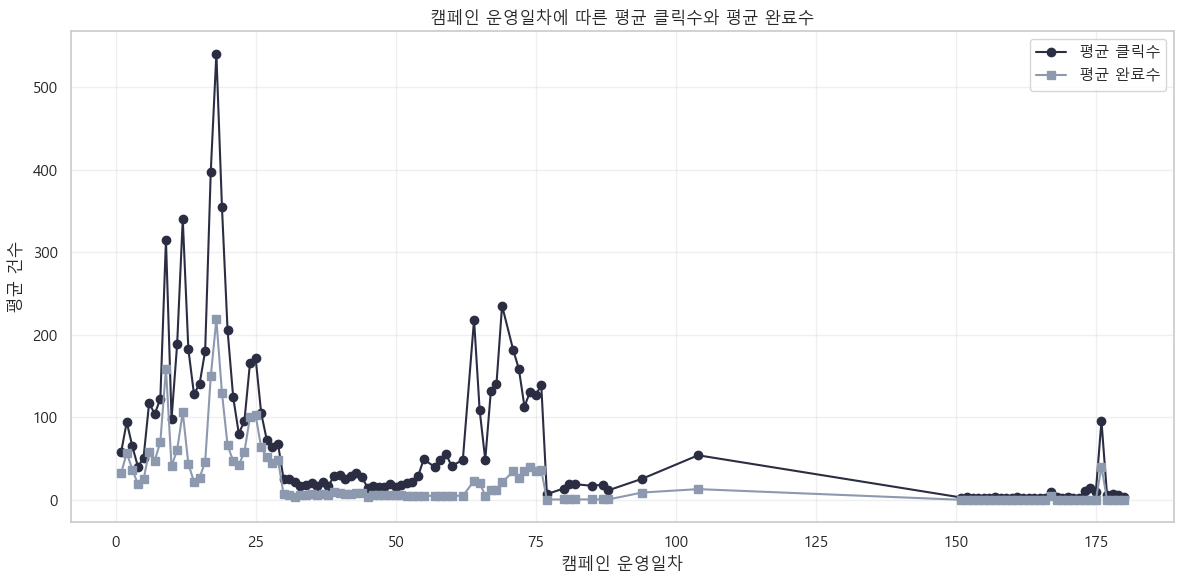

In [20]:
# 안정적으로 보기 위해 표본수 30미만인 운영일차는 제거
day_curve1 = day_curve.filter(pl.col("rows") >= MIN_AD_CLICKS).to_pandas()

plt.figure(figsize=(12,6))

plt.plot(
    day_curve1["campaign_n_day"],
    day_curve1["avg_click_cnt"],
    marker="o",
    label="평균 클릭수"
)

plt.plot(
    day_curve1["campaign_n_day"],
    day_curve1["avg_complete_cnt"],
    marker="s",
    label="평균 완료수"
)

plt.title("캠페인 운영일차에 따른 평균 클릭수와 평균 완료수")
plt.xlabel("캠페인 운영일차")
plt.ylabel("평균 건수")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


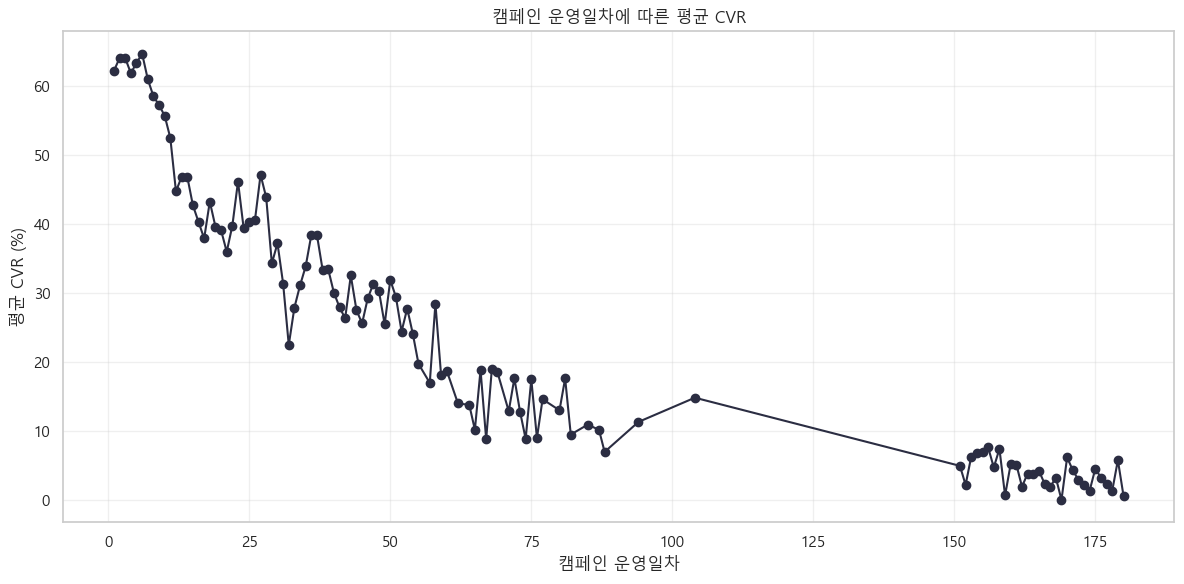

In [21]:
# cvr 시각화
plt.figure(figsize=(12,6))
plt.plot(
    day_curve1["campaign_n_day"],
    day_curve1["avg_cvr"],
    marker="o"
)
plt.title("캠페인 운영일차에 따른 평균 CVR")
plt.xlabel("캠페인 운영일차")
plt.ylabel("평균 CVR (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



앞의 `campaign_n_day` 곡선은 광고의 누적 운영일차에 따른 반응성 흐름을 보기 위한 보조 분석이다.

다만 안정성 평가에서 `campaign_n_day`를 그대로 stage로 사용하면 해석에 주의가 필요하다.
- `campaign_n_day`는 광고가 실제로 시작된 이후의 누적 운영일차를 의미한다.
- 분석 기간에 처음 등장한 광고라도 이미 오래전에 시작된 광고라면 바로 `28일+` 구간으로 들어갈 수 있다.
- 이 경우 분석 데이터 안에서 꾸준히 관측된 광고인지 판단하기 어렵다.

따라서 안정성 분석용으로는 별도 기준인 `observed_stage`를 사용한다.
- observed_n_day 커브는 후에 안정성 파트에서 확인한다.

- `observed_stage` : 광고별 첫 관측일(`first_observed_day`)을 기준으로, 분석 데이터 안에서 며칠째 관측되는지를 계산한 구간
- 안정성 관련 분석에서는 광고의 누적 운영일차보다, 분석 데이터 내 실제 관측일차를 기준으로 한 `observed_stage`를 사용한다.


#### 1-7-1. observed_stage 2구간 정의

- 01_초기(1~4일): 광고 초기 성과 구간
- 02_유지(5일+): 광고 생존 이후 구간

`observed_stage`는 단순 경과 시간이 아니라, 광고 성과 구조가 변화하는 시점을 기준으로 초기 반응과 유지 성과를 구분하기 위한 구간이다.


In [22]:
# observed_stage 생성을 위한 관측일 계산
# click_day 기준으로 광고별 첫 관측일을 잡고,
# 분석 데이터 안에서 며칠째 관측되는지 계산한다.

mart = (
    mart
    .with_columns(
        pl.col("click_day").cast(pl.Date, strict=False).alias("click_day")
    )
    .with_columns(
        pl.col("click_day").min().over("ads_idx").alias("first_observed_day")
    )
    .with_columns(
        ((pl.col("click_day") - pl.col("first_observed_day")).dt.total_days() + 1)
        .alias("observed_n_day")
    )
)


In [23]:
mart = mart.with_columns([
    pl.when(pl.col("observed_n_day") <= 4)
    .then(pl.lit("01_초기(1~4일)"))
    .otherwise(pl.lit("02_유지(5일+)"))
    .alias("observed_stage")
])

In [24]:
# observed_stage 구간별 행 수 / 광고 수 확인
mart.group_by("observed_stage").agg([
    pl.len().alias("rows"),
    pl.col("ads_idx").n_unique().alias("ads_cnt"),
    (pl.len() / pl.col("ads_idx").n_unique()).alias("rows_per_ad")
]).sort("observed_stage")

observed_stage,rows,ads_cnt,rows_per_ad
str,u32,u32,f64
"""01_초기(1~4일)""",20083,9517,2.110224
"""02_유지(5일+)""",452983,439217,1.031342


In [25]:
# 안정성 관련 stage 요약은 observed_stage 기준으로 확인

mart.group_by("observed_stage").agg([
    # observed_stage별 광고-일자 행 수
    pl.len().alias("rows"),
    # observed_stage별 평균/중앙 CVR
    pl.col("daily_cvr").mean().alias("avg_cvr"),
    pl.col("daily_cvr").median().alias("median_cvr"),
    # observed_stage별 평균 클릭수/완료수
    pl.col("click_cnt").mean().alias("avg_click"),
    pl.col("complete_cnt").mean().alias("avg_complete")
]).sort("observed_stage")


observed_stage,rows,avg_cvr,median_cvr,avg_click,avg_complete
str,u32,f64,f64,f64,f64
"""01_초기(1~4일)""",20083,57.594031,66.666667,66.234477,33.754021
"""02_유지(5일+)""",452983,34.928866,16.666667,4.087546,1.558339


#### 1-7-2. observed_stage 2구간 검정

초기(1~7일)와 유지(8일+) 구간을 실제 분석 축으로 사용하기 전에, 두 구간의 일자 CVR 분포가 서로 다른지 확인한다.

In [26]:
# observed_stage 초기/유지 CVR 차이 검정

stage_test_df = (
    mart
    .select(["observed_stage", "daily_cvr"])
    .drop_nulls()
    .to_pandas()
)

stage_order = ["01_초기(1~4일)", "02_유지(5일+)"]

early_cvr = stage_test_df.loc[
    stage_test_df["observed_stage"] == stage_order[0],
    "daily_cvr"
]

maintain_cvr = stage_test_df.loc[
    stage_test_df["observed_stage"] == stage_order[1],
    "daily_cvr"
]

stage_stat, stage_p_value = mannwhitneyu(
    early_cvr,
    maintain_cvr,
    alternative="two-sided",
)

n1 = len(early_cvr)
n2 = len(maintain_cvr)
stage_rbc = (2 * stage_stat) / (n1 * n2) - 1

stage_test_summary = (
    stage_test_df
    .groupby("observed_stage")["daily_cvr"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
    .rename(columns={
        "observed_stage": "관측구간",
        "count": "관측수",
        "mean": "평균CVR",
        "median": "중앙값CVR",
        "std": "표준편차",
    })
)

stage_test_result = pd.DataFrame([{
    "검정": "초기/유지 CVR 차이",
    "검정방법": "Mann-Whitney U",
    "U통계량": stage_stat,
    "p값": stage_p_value,
    "효과크기_RBC": stage_rbc,
}])

show_table("observed_stage CVR 차이 검정 결과", stage_test_result, n=5)
show_table("observed_stage CVR 요약", stage_test_summary, n=5)

**observed_stage CVR 차이 검정 결과**

,검정,검정방법,U통계량,p값,효과크기_RBC
0,초기/유지 CVR 차이,Mann-Whitney U,"211,176,874.50",0.00,0.31


**observed_stage CVR 요약**

,관측구간,관측수,평균CVR,중앙값CVR,표준편차
0,01_초기(1~4일),19132,57.59,66.67,36.37
1,02_유지(5일+),16819,34.93,16.67,39.18


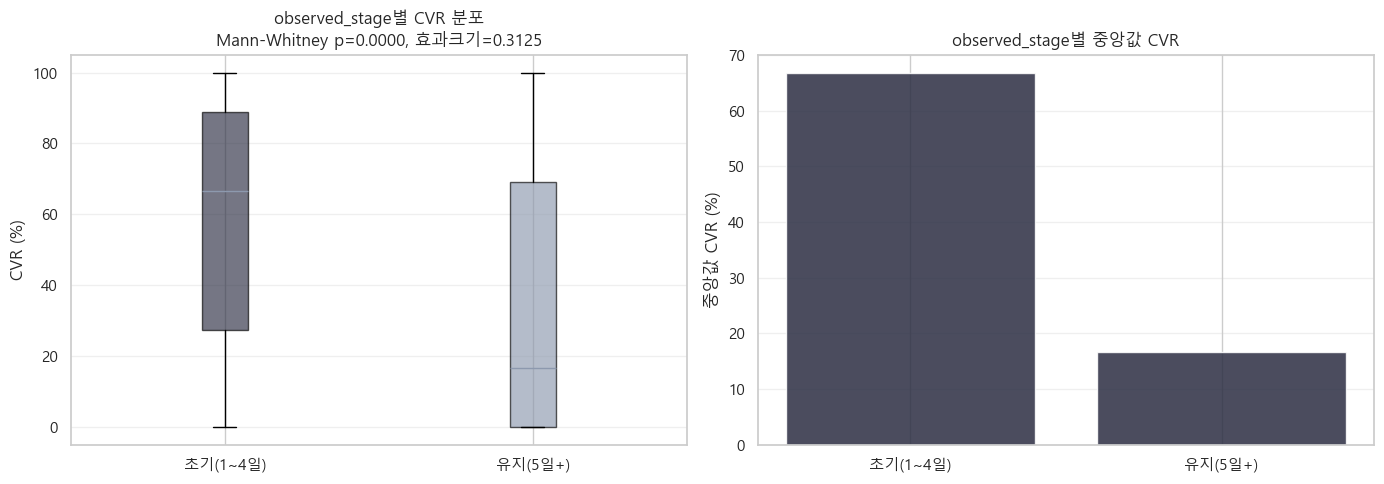

In [27]:
# observed_stage CVR 분포 시각화

stage_box_data = [early_cvr.values, maintain_cvr.values]
stage_labels = ["초기(1~4일)", "유지(5일+)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp = axes[0].boxplot(
    stage_box_data,
    labels=stage_labels,
    patch_artist=True,
    showfliers=False,
)

box_colors = get_plot_colors(len(bp["boxes"]))
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

axes[0].set_title(
    f"observed_stage별 CVR 분포\nMann-Whitney p={stage_p_value:.4f}, 효과크기={stage_rbc:.4f}"
)
axes[0].set_ylabel("CVR (%)")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    stage_labels,
    [early_cvr.median(), maintain_cvr.median()],
    alpha=0.85,
)

axes[1].set_title("observed_stage별 중앙값 CVR")
axes[1].set_ylabel("중앙값 CVR (%)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 1-8. 광고 × `observed_stage` 성과 테이블 생성

광고 1개가 특정 `observed_stage`에서 어떤 성과를 냈는지 확인한다.

> 반응성 지표는 `reaction_daily` 기준  
> 수익성 지표는 `finance_daily` 기준  
> 안정성 지표는 `observed_stage` 기준  
> 규모(운영 영향력) 지표는 클릭수/완료수/관측일수 기준으로 함께 집계


In [28]:
# ads_idx × observed_stage 성과 테이블
## 반응성, 수익성, 안정성, 규모를 함께 보기 위한 중간 테이블

ads_stage_perf = (
    mart
    .group_by([
        "ads_idx",
        "ads_name",
        "observed_stage",
        "analysis_ads_type_label",
        "category_name",
        "reward_band",
    ])
    .agg([
        # 해당 광고가 observed_stage에서 며칠 관측되었는지
        pl.len().alias("stage_days"),
        # 반응성 & 규모: stage 내 총 클릭수/완료수
        pl.col("click_cnt").sum().alias("stage_click_cnt"),
        pl.col("complete_cnt").sum().alias("stage_complete_cnt"),
        # 반응성 & 안정성: 일별 CVR의 평균/중앙값/표준편차
        pl.col("daily_cvr").mean().alias("stage_avg_daily_cvr"),
        pl.col("daily_cvr").median().alias("stage_median_daily_cvr"),
        pl.col("daily_cvr").std().alias("stage_std_daily_cvr"),
        # 수익성: stage 내 관측 마진/정상 마진 합계
        pl.col("daily_observed_margin").sum().alias("stage_observed_margin"),
        pl.col("daily_valid_margin").sum().alias("stage_valid_margin"),
        # 재무 이상 여부: stage 안에 재무 이상이 한 번이라도 있었는지
        pl.col("has_finance_anomaly").max().alias("stage_has_finance_anomaly"),
    ])
    .with_columns([
        # stage 전체 CVR = stage 총 완료수 / stage 총 클릭수 × 100
        pl.when(pl.col("stage_click_cnt") > 0)
        .then(pl.col("stage_complete_cnt") / pl.col("stage_click_cnt") * 100)
        .otherwise(None)
        .alias("stage_cvr"),
        # stage 클릭당 정상 마진
        pl.when(pl.col("stage_click_cnt") > 0)
        .then(pl.col("stage_valid_margin") / pl.col("stage_click_cnt"))
        .otherwise(None)
        .alias("stage_valid_margin_per_click"),
        # stage 완료당 정상 마진
        pl.when(pl.col("stage_complete_cnt") > 0)
        .then(pl.col("stage_valid_margin") / pl.col("stage_complete_cnt"))
        .otherwise(None)
        .alias("stage_valid_margin_per_complete"),
    ])
)

ads_stage_perf.head()


ads_idx,ads_name,observed_stage,analysis_ads_type_label,category_name,reward_band,stage_days,stage_click_cnt,stage_complete_cnt,stage_avg_daily_cvr,stage_median_daily_cvr,stage_std_daily_cvr,stage_observed_margin,stage_valid_margin,stage_has_finance_anomaly,stage_cvr,stage_valid_margin_per_click,stage_valid_margin_per_complete
str,str,str,str,str,str,u32,u32,i64,f64,f64,f64,f64,f64,bool,f64,f64,f64
"""50024""","""세레스쥬얼 물고반가드 맞추기 5.31""","""02_유지(5일+)""","""참여형""","""간편미션-퀴즈""","""50원 미만""",1,0,0,null,null,null,0.0,0.0,false,null,null,null
"""74198""","""법무사이동진사무소""","""02_유지(5일+)""","""참여형""","""간편미션-퀴즈""","""50원 미만""",1,0,0,null,null,null,0.0,0.0,false,null,null,null
"""161641""","""4D 플러스 강화유... (검색 후 퀴즈맞추기) 238…","""02_유지(5일+)""","""참여형""","""간편미션-퀴즈""","""50원 미만""",1,0,0,null,null,null,0.0,0.0,false,null,null,null
"""105920""","""[플레이스 퀴즈] 랑스파 (2777)""","""02_유지(5일+)""","""참여형""","""간편미션-퀴즈""","""50원 미만""",1,0,0,null,null,null,0.0,0.0,false,null,null,null
"""103866""","""탱커블타이어공기압주입기 메이튼 맞추기 10.5""","""02_유지(5일+)""","""참여형""","""간편미션-퀴즈""","""50원 미만""",1,0,0,null,null,null,0.0,0.0,false,null,null,null


### 1-9. 광고 단위 최종 평가 테이블 생성

`ads_stage_perf`를 광고 1개 = 1행으로 요약한 `ads_eval`
- 어떤 광고가 전체적으로 반응성이 좋은가?
- 어떤 광고가 수익성이 좋은가?
- 어떤 광고가 `observed_stage`가 바뀌어도 안정적인가?
- 어떤 광고는 단기 관측이라 안정성 평가가 어려운가?
- 어떤 광고가 전체 성과에서 차지하는 규모(운영 영향력)가 큰가?


In [29]:
# ads_eval 생성
# 광고 1개 = 1행

ads_eval = (
    ads_stage_perf
    .group_by([
        "ads_idx",
        "ads_name",
        "analysis_ads_type_label",
        "category_name",
        "reward_band"
    ])
    .agg([
        # 이 광고가 몇 개 observed_stage에서 관측되었는지
        pl.col("observed_stage").n_unique().alias("stage_cnt"),
        # 전체 관측 일수
        pl.col("stage_days").sum().alias("total_days"),
        # 전체 클릭수/완료수
        pl.col("stage_click_cnt").sum().alias("total_click_cnt"),
        pl.col("stage_complete_cnt").sum().alias("total_complete_cnt"),
        # 전체 관측 마진/정상 마진
        pl.col("stage_observed_margin").sum().alias("total_observed_margin"),
        pl.col("stage_valid_margin").sum().alias("total_valid_margin"),
        # stage별 CVR의 평균
        pl.col("stage_cvr").mean().alias("mean_stage_cvr"),
        # stage별 CVR의 변화량
        (pl.col("stage_cvr").max() - pl.col("stage_cvr").min()).alias("delta_stage_cvr"),
        # stage별 CVR의 최소/최대값
        pl.col("stage_cvr").min().alias("min_stage_cvr"),
        pl.col("stage_cvr").max().alias("max_stage_cvr"),
        # stage별 클릭당 마진 변화량
        (pl.col("stage_valid_margin_per_click").max() - 
         pl.col("stage_valid_margin_per_click").min())
        .alias("delta_stage_margin_pc"),
        # stage별 클릭당 마진 최소/최대값
        pl.col("stage_valid_margin_per_click").min().alias("min_stage_margin_pc"),
        pl.col("stage_valid_margin_per_click").max().alias("max_stage_margin_pc"),
        pl.when(pl.col("observed_stage").n_unique() >= 2)
          .then(
              pl.col("stage_cvr")
              .filter(pl.col("observed_stage") == "02_유지(5일+)")
              .first()
              -
              pl.col("stage_cvr")
              .filter(pl.col("observed_stage") == "01_초기(1~4일)")
              .first()
          )
          .otherwise(None)
          .alias("change_stage_cvr"),
        pl.when(pl.col("observed_stage").n_unique() >= 2)
          .then(
              pl.col("stage_valid_margin_per_click")
              .filter(pl.col("observed_stage") == "02_유지(5일+)")
              .first()
              -
              pl.col("stage_valid_margin_per_click")
              .filter(pl.col("observed_stage") == "01_초기(1~4일)")
              .first()
          )
          .otherwise(None)
          .alias("change_stage_margin_pc"),        
        # 광고 전체에서 재무 이상이 있었는지
        pl.col("stage_has_finance_anomaly").max().alias("has_finance_anomaly"),
    ])
)

In [30]:
ads_eval = (
    ads_eval
    .with_columns([
        # 광고 전체 CVR
        pl.when(pl.col("total_click_cnt") > 0)
          .then(pl.col("total_complete_cnt") / pl.col("total_click_cnt") * 100)
          .otherwise(None)
          .alias("total_cvr"),
        # 광고 전체 클릭당 정상 마진
        pl.when(pl.col("total_click_cnt") > 0)
          .then(pl.col("total_valid_margin") / pl.col("total_click_cnt"))
          .otherwise(None)
          .alias("total_valid_margin_per_click"),
        # 광고 전체 완료당 정상 마진
        pl.when(pl.col("total_complete_cnt") > 0)
          .then(pl.col("total_valid_margin") / pl.col("total_complete_cnt"))
          .otherwise(None)
          .alias("total_valid_margin_per_complete"),
    ])
)

In [31]:
ads_eval = (
    ads_eval
    .with_columns([
        # 전체 클릭 기여율
        pl.when(pl.col("total_click_cnt").sum() > 0)
          .then(pl.col("total_click_cnt") / pl.col("total_click_cnt").sum() * 100)
          .otherwise(None)
          .alias("click_impact_share"),
        # 전체 완료 기여율
        pl.when(pl.col("total_complete_cnt").sum() > 0)
          .then(pl.col("total_complete_cnt") / pl.col("total_complete_cnt").sum() * 100)
          .otherwise(None)
          .alias("complete_impact_share"),
    ])
)

### 1-10. 공통 분석 모집단 생성

In [32]:
# 공통 분석 모집단 생성
## 너무 클릭수가 적은 광고는 CVR이 튈 수 있음
## -> 최소 클릭수 기준을 두고 분석 대상 광고를 제한

ads_analysis_base = (
    ads_eval
    # 클릭수 >= 30만 분석 대상
    .filter(pl.col("total_click_cnt") >= 30)
    .with_columns([
        # stage가 2개 -> observed_stage 간 성과 변화 비교 가능
        (pl.col("stage_cnt") >= 2).alias("can_eval_stability"),
        # stage가 1개뿐 -> 단기 관측 광고
        (pl.col("stage_cnt") == 1).alias("is_short_run_ad"),
        # 재무 이상이 있었던 광고는 수익성 해석 시 주의 필요
        pl.col("has_finance_anomaly").alias("need_profit_caution"),
    ])
)

print("전체 광고 수:", ads_eval.shape[0])
print("공통 분석 대상 광고 수:", ads_analysis_base.shape[0])
print("안정성 비교 가능 광고 수:", ads_analysis_base.filter(pl.col("can_eval_stability")).shape[0])
print("단기 관측 광고 수:", ads_analysis_base.filter(pl.col("is_short_run_ad")).shape[0])

전체 광고 수: 445260
공통 분석 대상 광고 수: 3475
안정성 비교 가능 광고 수: 1534
단기 관측 광고 수: 1941


## 2. 전체 퍼널 및 D3 재참여 진단

전체 클릭이 완료와 재참여까지 이어지는지 확인한다.


### 2-1. 전체 클릭-완료 퍼널 진단

**분석 질문** : 전체 클릭–완료 퍼널은 어떤 구조인가? 전체 집계 CVR은 실제 성과를 잘 반영하는가?

**사용 지표** : 전체 클릭 수, 완료 수, CVR, 일별 추이

**핵심 해석 포인트**

- 전체 집계 CVR은 광고별·시간대별·유저 행동별 차이를 가릴 수 있다. 전체 집계 CVR은 출발점으로만 사용한다.
- 클릭 수가 적은 광고는 CVR이 과대평가될 가능성이 있다. 따라서 광고 단위 성과 분석은 클릭 30건 이상 광고를 기본 대상으로 한다.

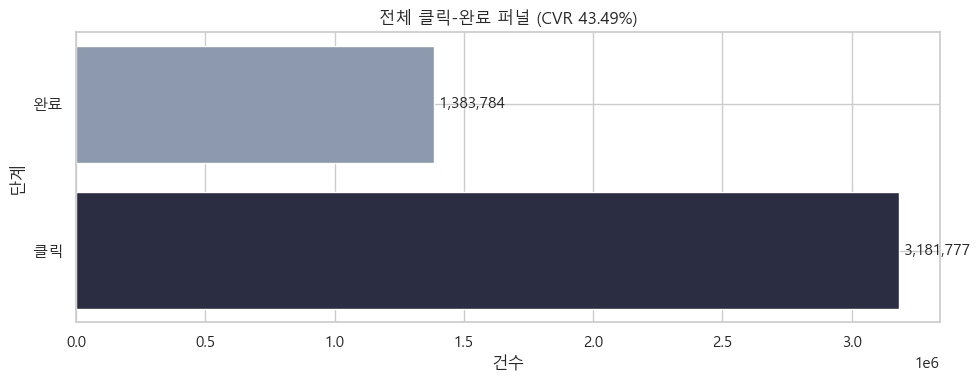

**전체 퍼널 요약**

,지표,값
0,클릭 수,"3,181,777.00"
1,완료 수,"1,383,784.00"
2,완료율(%),43.49


In [33]:
# 전체 클릭-완료 퍼널
click_total = main_funnel_work["click_key"].count()
complete_total = main_funnel_work["is_completed"].sum()
overall_cvr = complete_total / click_total * 100 if click_total > 0 else np.nan

funnel_df = pd.DataFrame({
    "stage": ["클릭", "완료"],
    "count": [click_total, complete_total],
})

plt.figure(figsize=(10, 4))
bars = plt.barh(funnel_df["stage"], funnel_df["count"], color=get_plot_colors(2))
plt.title(f"전체 클릭-완료 퍼널 (CVR {overall_cvr:.2f}%)")
plt.xlabel("건수")
plt.ylabel("단계")

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height() / 2, f" {width:,.0f}", va="center", fontsize=11)

plt.tight_layout()
plt.show()

show_table("전체 퍼널 요약", pd.DataFrame({"지표": ["클릭 수", "완료 수", "완료율(%)"], "값": [click_total, complete_total, overall_cvr]}), n=10)

### 2-2. 클릭-완료 이후 D3 재참여 진단

첫 클릭 → 첫 완료는 전환 퍼널로 해석한다. 첫 완료 → D3 재클릭 / D3 재완료는 같은 퍼널 단계가 아니라 재참여 확장 지표로 해석한다.


In [34]:
# 리워드 광고 퍼널 핵심 지표: 첫 완료, D3 재참여
# - 첫 클릭: click_date_dt 기준
# - 첫 완료: regdate 기준
# - D3 재클릭/재완료: 첫 완료일 다음날부터 3일 이내 날짜 기준

funnel_work = main_funnel_work.copy()

# 유저별 첫 클릭일
first_click = (
    funnel_work
    .groupby("dvc_idx")["click_date_dt"]
    .min()
    .reset_index()
    .rename(columns={"click_date_dt": "first_click_date"})
)

# 완료 이벤트
completed = funnel_work[funnel_work["is_completed"] == 1].copy()

# 유저별 첫 완료일: regdate 기준
first_complete = (
    completed
    .groupby("dvc_idx")["regdate"]
    .min()
    .reset_index()
    .rename(columns={"regdate": "first_complete_date"})
)

# 첫 완료일 붙이기
funnel_work = funnel_work.merge(first_complete, on="dvc_idx", how="left")
completed = completed.merge(first_complete, on="dvc_idx", how="left")

# 날짜 기준 D3 계산
funnel_work["days_after_first_complete_click"] = (
    funnel_work["click_date_dt"].dt.normalize()
    - funnel_work["first_complete_date"].dt.normalize()
).dt.days

completed["days_after_first_complete_complete"] = (
    completed["regdate"].dt.normalize()
    - completed["first_complete_date"].dt.normalize()
).dt.days

In [35]:
# D3 재클릭: 첫 완료 다음날부터 3일 이내 클릭
d3_reclick = (
    funnel_work[
        funnel_work["days_after_first_complete_click"].between(1, 3)
    ]
    .groupby("dvc_idx")["click_key"]
    .count()
    .reset_index()
    .rename(columns={"click_key": "d3_reclick_cnt"})
)

# D3 재완료: 첫 완료 다음날부터 3일 이내 완료
d3_recomplete = (
    completed[
        completed["days_after_first_complete_complete"].between(1, 3)
    ]
    .groupby("dvc_idx")["click_key"]
    .count()
    .reset_index()
    .rename(columns={"click_key": "d3_recomplete_cnt"})
)

# 반복 완료: 전체 기간 완료 2회 이상
repeat_complete = (
    completed
    .groupby("dvc_idx")["click_key"]
    .count()
    .reset_index()
    .rename(columns={"click_key": "total_complete_cnt"})
)

# 퍼널 집계
n_first_click = len(first_click)
n_first_complete = len(first_complete)
n_d3_reclick = len(d3_reclick)
n_d3_recomplete = len(d3_recomplete)
n_repeat = (repeat_complete["total_complete_cnt"] >= 2).sum()

click_to_complete_rate = safe_divide(n_first_complete, n_first_click, 100)
d3_reclick_rate = safe_divide(n_d3_reclick, n_first_complete, 100)
d3_recomplete_rate = safe_divide(n_d3_recomplete, n_first_complete, 100)
repeat_rate = safe_divide(n_repeat, n_first_complete, 100)

funnel_kpi = pd.DataFrame({
    "퍼널 단계": [
        "① 첫 클릭 유저",
        "② 첫 완료 유저",
        "③ D3 재클릭 유저",
        "④ D3 재완료 유저",
        "⑤ 반복 완료 유저(≥2회)",
    ],
    "유저 수": [
        n_first_click,
        n_first_complete,
        n_d3_reclick,
        n_d3_recomplete,
        n_repeat,
    ],
    "전환율(%)": [
        100,
        click_to_complete_rate,
        d3_reclick_rate,
        d3_recomplete_rate,
        repeat_rate,
    ],
    "기준": [
        "전체 기준",
        "첫 클릭 기준",
        "첫 완료 기준",
        "첫 완료 기준",
        "첫 완료 기준",
    ],
})

funnel_kpi["전환율(%)"] = funnel_kpi["전환율(%)"].astype(float).round(2)

show_table("클릭-완료 이후 D3 재참여 핵심 지표", funnel_kpi, n=10)


**클릭-완료 이후 D3 재참여 핵심 지표**

,퍼널 단계,유저 수,전환율(%),기준
0,① 첫 클릭 유저,871616,100.00,전체 기준
1,② 첫 완료 유저,619556,71.08,첫 클릭 기준
2,③ D3 재클릭 유저,66174,10.68,첫 완료 기준
3,④ D3 재완료 유저,44058,7.11,첫 완료 기준
4,⑤ 반복 완료 유저(≥2회),270291,43.63,첫 완료 기준


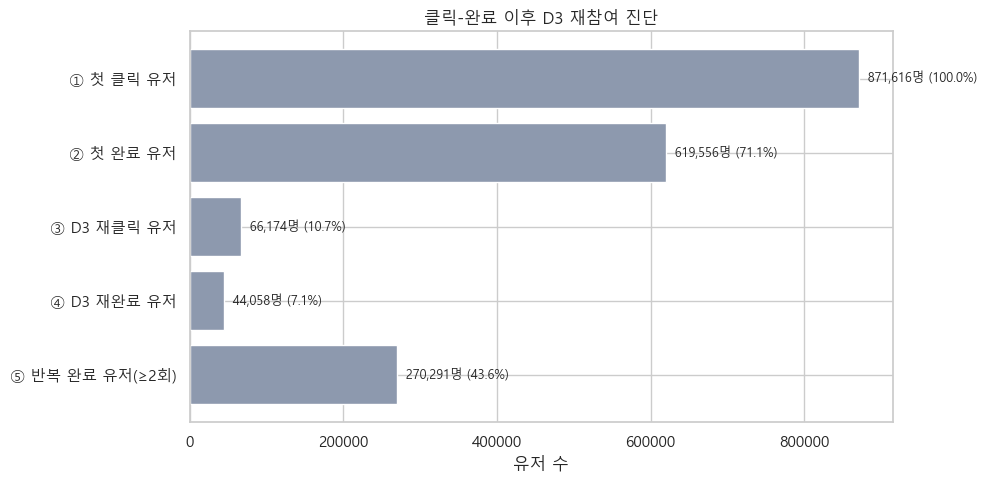

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    funnel_kpi["퍼널 단계"][::-1],
    funnel_kpi["유저 수"][::-1],
    color=get_plot_colors(5),
)

ax.set_xlabel("유저 수")
ax.set_title("클릭-완료 이후 D3 재참여 진단")

for i, (n, r) in enumerate(zip(funnel_kpi["유저 수"][::-1], funnel_kpi["전환율(%)"][::-1])):
    ax.text(n, i, f"  {n:,.0f}명 ({r:.1f}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [37]:
# D3 재참여 유저의 첫 완료 소요시간(CTIT) 요약
first_complete_event = (
    completed
    .sort_values(["dvc_idx", "regdate", "click_date_dt"])
    .drop_duplicates("dvc_idx")
    [["dvc_idx", "ads_idx", "ctit"]]
    .copy()
)

first_complete_event = first_complete_event.merge(
    d3_reclick.assign(d3_reclick_flag=1)[["dvc_idx", "d3_reclick_flag"]],
    on="dvc_idx",
    how="left",
).merge(
    d3_recomplete.assign(d3_recomplete_flag=1)[["dvc_idx", "d3_recomplete_flag"]],
    on="dvc_idx",
    how="left",
)

first_complete_event[["d3_reclick_flag", "d3_recomplete_flag"]] = (
    first_complete_event[["d3_reclick_flag", "d3_recomplete_flag"]]
    .fillna(0)
    .astype(int)
)
first_complete_event["has_d3_rejoin"] = (
    (first_complete_event["d3_reclick_flag"] == 1)
    | (first_complete_event["d3_recomplete_flag"] == 1)
)

rejoinable_ctit_summary = pd.DataFrame([
    {
        "구분": "전체 첫 완료 유저",
        "유저수": first_complete_event["dvc_idx"].nunique(),
        "평균 CTIT": first_complete_event["ctit"].mean(),
        "중앙값 CTIT": first_complete_event["ctit"].median(),
    },
    {
        "구분": "D3 재참여 관측 유저",
        "유저수": first_complete_event.loc[first_complete_event["has_d3_rejoin"], "dvc_idx"].nunique(),
        "평균 CTIT": first_complete_event.loc[first_complete_event["has_d3_rejoin"], "ctit"].mean(),
        "중앙값 CTIT": first_complete_event.loc[first_complete_event["has_d3_rejoin"], "ctit"].median(),
    },
])
show_table("D3 재참여 유저의 첫 완료 소요시간(CTIT) 요약", rejoinable_ctit_summary, n=10)


**D3 재참여 유저의 첫 완료 소요시간(CTIT) 요약**

,구분,유저수,평균 CTIT,중앙값 CTIT
0,전체 첫 완료 유저,619556,886.51,93.00
1,D3 재참여 관측 유저,66563,"1,650.51",98.00


### 2-3. D3 재참여 해석

D3 재완료율 : 해당 광고로 첫 완료한 유저가 3일 이내에 다시 완료한 비율

반복 참여 가능 광고는 첫 전환 자체는 발생하지만 D3 재완료율이 낮다. 광고 난이도 자체보다 재참여 트리거 부족이나 동일 광고 피로도 가능성을 점검해야 한다.

재참여 유도 후보: 첫 완료는 발생하지만 D3 재완료율이 낮은 광고. 단순 재노출보다 데일리 참여 문구, 다음날 추가 포인트, 재방문 리마인드 실험이 필요하다.

예시: 내일 다시 방문하면 추가 포인트를 받을 수 있어요.
※ ⑤ 반복 완료 유저는 D3 기간이 아니라 전체 관측 기간 기준 완료 2회 이상 유저이므로, D3 재완료와 같은 단계로 해석하지 않는다.

---
## 3. 반응성 분석

유저가 광고에 얼마나 잘 반응하고, 클릭이 완료까지 이어지는지 확인한다.

단순 클릭 수가 아니라 클릭 후 완료까지 이어지는 정도, CTIT, 광고유형·카테고리·보상구간·시간대·요일 차이를 함께 본다.


### 3-1. 광고유형·카테고리별 성과 분석

**분석 질문** : 광고유형과 카테고리에 따라 클릭 규모와 완료율(CVR)이 다르게 나타나는가?

**사용 지표** : 광고유형별 클릭 수, 완료 수, 집계 CVR, 광고 단위 CVR 분포, Kruskal-Wallis 검정, Dunn 사후검정

**핵심 해석** : 광고유형별로 CVR 차이가 크다면, 모든 광고를 같은 기준으로 운영하기 어렵다. 클릭이 많은 유형이 반드시 완료 효율까지 높은 것은 아니므로 유형별 운영 기준이 필요하다.

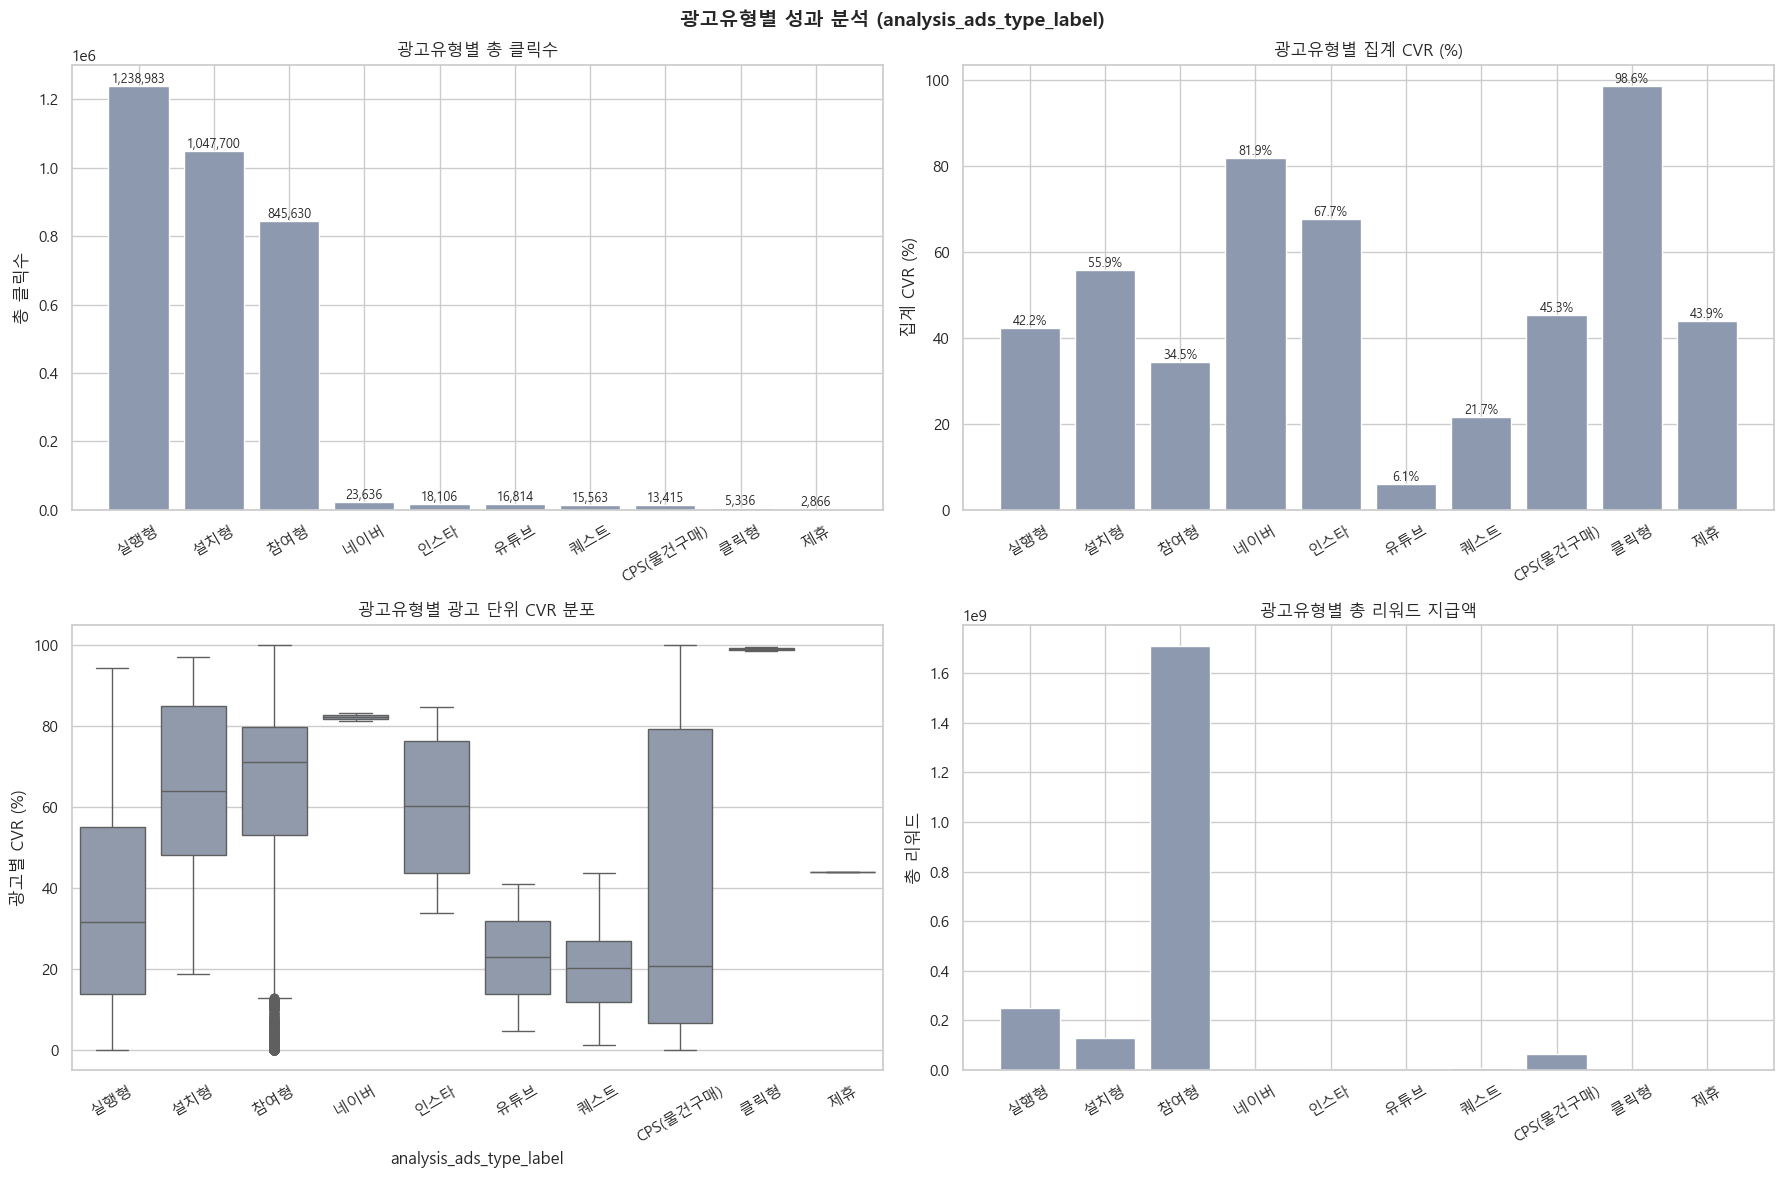

**광고유형별 성과 요약**

,analysis_ads_type_label,광고수,총클릭수,총완료수,집계CVR,중앙값CVR,총리워드,평균ctit
3,실행형,35,1238983,522863,42.20,31.46,"247,869,836.00",471.03
2,설치형,52,1047700,585444,55.88,64.00,"128,223,490.00",295.74
7,참여형,3419,845630,291445,34.46,70.97,"1,710,274,337.00","9,339.83"
1,네이버,2,23636,19353,81.88,82.20,"1,922,592.00",102.35
5,인스타,4,18106,12262,67.72,60.25,"2,238,507.00","10,088.27"
4,유튜브,2,16814,1027,6.11,22.78,"2,683,240.00","4,056.18"
8,퀘스트,78,15563,3380,21.72,20.22,"5,950,949.00","157,396.57"
0,CPS(물건구매),32,13415,6077,45.30,20.69,"64,330,767.00","2,345.13"
9,클릭형,3,5336,5260,98.58,99.05,"19,396.00",2.09
6,제휴,1,2866,1259,43.93,43.93,"514,278.00",110.56


In [38]:
# 광고유형별 성과 분석
# - 광고유형별 대표 CVR은 광고별 CVR 단순 평균이 아니라 집계CVR을 사용한다.
# - 집계CVR = 해당 광고유형의 총완료수 / 총클릭수 * 100
# - 박스플롯은 광고 단위 CVR 분포를 보기 위해 기존 cvr_pct를 그대로 사용한다.

type_agg = (
    ad_df
    .groupby(type_col)
    .agg(
        광고수=("ads_idx", "nunique"),
        총클릭수=("click_cnt", "sum"),
        총완료수=("complete_cnt", "sum"),
        중앙값CVR=("cvr_pct", "median"),
        총리워드=("total_reward_cost", "sum"),
        평균ctit=("avg_ctit", "mean"),
    )
    .reset_index()
)

type_agg["집계CVR"] = safe_divide(
    type_agg["총완료수"],
    type_agg["총클릭수"],
    100,
)

type_agg = (
    type_agg[
        [
            type_col,
            "광고수",
            "총클릭수",
            "총완료수",
            "집계CVR",
            "중앙값CVR",
            "총리워드",
            "평균ctit",
        ]
    ]
    .sort_values("총클릭수", ascending=False)
)

type_order = type_agg[type_col].tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f"광고유형별 성과 분석 ({type_col})", fontsize=14, fontweight="bold")
#광고유형별 총 클릭 수, 집계CVR, 광고 단위 CVR 분포(박스플롯), 총 리워드 지급액을 각각의 그래프로 시각화한다. 광고유형은 총 클릭 수 기준으로 정렬해서 보여준다.
axes[0, 0].bar(
    type_agg[type_col].astype(str),
    type_agg["총클릭수"],
    color=get_plot_colors(len(type_agg)),
)
axes[0, 0].set_title("광고유형별 총 클릭수")
axes[0, 0].set_ylabel("총 클릭수")
axes[0, 0].tick_params(axis="x", rotation=30)

for i, v in enumerate(type_agg["총클릭수"]):
    axes[0, 0].text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

axes[0, 1].bar(
    type_agg[type_col].astype(str),
    type_agg["집계CVR"],
    color=get_plot_colors(len(type_agg)),
)
axes[0, 1].set_title("광고유형별 집계 CVR (%)")
axes[0, 1].set_ylabel("집계 CVR (%)")
axes[0, 1].tick_params(axis="x", rotation=30)

for i, v in enumerate(type_agg["집계CVR"]):
    axes[0, 1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

sns.boxplot(
    data=ad_df[[type_col, "cvr_pct"]].dropna(),
    x=type_col,
    y="cvr_pct",
    order=type_order,
    ax=axes[1, 0],
    palette=get_plot_colors(len(type_agg)),
)
axes[1, 0].set_title("광고유형별 광고 단위 CVR 분포")
axes[1, 0].set_ylabel("광고별 CVR (%)")
axes[1, 0].tick_params(axis="x", rotation=30)

axes[1, 1].bar(
    type_agg[type_col].astype(str),
    type_agg["총리워드"],
    color=get_plot_colors(len(type_agg)),
)
axes[1, 1].set_title("광고유형별 총 리워드 지급액")
axes[1, 1].set_ylabel("총 리워드")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

show_table("광고유형별 성과 요약", type_agg, n=20)

In [39]:
# 광고유형별 CVR 차이 검정
# - 광고 단위 CVR 분포가 광고유형별로 다른지 확인한다.
# - 광고 수가 충분한 유형(n>=5)만 사용한다.

type_cvr_test = ad_df[[type_col, "ads_idx", "cvr_pct"]].dropna().copy()

type_counts_cvr = (
    type_cvr_test
    .groupby(type_col)
    .size()
    .reset_index(name="n")
)

valid_types_cvr = type_counts_cvr.loc[
    type_counts_cvr["n"] >= MIN_GROUP_N,
    type_col,
].tolist()

type_cvr_main = type_cvr_test[
    type_cvr_test[type_col].isin(valid_types_cvr)
].copy()

type_cvr_groups = {
    label: group["cvr_pct"].dropna().values
    for label, group in type_cvr_main.groupby(type_col)
}

kw_type_cvr_stat, kw_type_cvr_p = kruskal(*type_cvr_groups.values())

type_cvr_group_n = len(type_cvr_groups)
type_cvr_obs_n = len(type_cvr_main)

kw_type_cvr_effect = max(
    0,
    (kw_type_cvr_stat - type_cvr_group_n + 1) / (type_cvr_obs_n - type_cvr_group_n),
)

type_cvr_result = pd.DataFrame([{
    "검정": "광고유형별 CVR 차이",
    "검정방법": "Kruskal-Wallis",
    "그룹수": type_cvr_group_n,
    "관측수": type_cvr_obs_n,
    "H통계량": kw_type_cvr_stat,
    "p값": kw_type_cvr_p,
    "효과크기": kw_type_cvr_effect,
}])

type_cvr_summary = (
    type_cvr_main
    .groupby(type_col)
    .agg(
        광고수=("ads_idx", "nunique"),
        평균CVR=("cvr_pct", "mean"),
        중앙값CVR=("cvr_pct", "median"),
    )
    .reset_index()
    .sort_values("중앙값CVR", ascending=False)
)

show_table("광고유형별 CVR Kruskal-Wallis 검정 결과", type_cvr_result, n=5)
show_table("광고유형별 CVR 요약", type_cvr_summary, n=20)

**광고유형별 CVR Kruskal-Wallis 검정 결과**

,검정,검정방법,그룹수,관측수,H통계량,p값,효과크기
0,광고유형별 CVR 차이,Kruskal-Wallis,5,3616,165.45,0.00,0.04


**광고유형별 CVR 요약**

,analysis_ads_type_label,광고수,평균CVR,중앙값CVR
3,참여형,3419,61.86,70.97
1,설치형,52,64.87,64.00
2,실행형,35,36.17,31.46
0,CPS(물건구매),32,40.32,20.69
4,퀘스트,78,20.28,20.22


광고유형별 CVR 차이는 통계적으로 유의하지만, 효과크기는 크지 않다.
따라서 유형 차이는 존재하되, 유형만으로 운영 판단을 확정하기보다 보상, 시간대, 수익성 지표와 함께 봐야 한다.

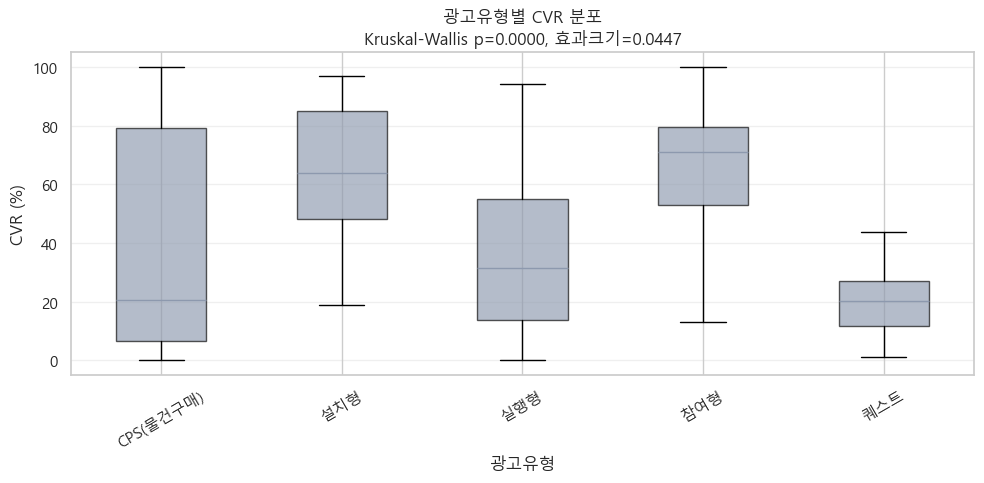

In [40]:
# 광고유형별 CVR 분포 시각화

labels = list(type_cvr_groups.keys())
box_data = [type_cvr_groups[label] for label in labels]

plt.figure(figsize=(10, 5))

bp = plt.boxplot(
    box_data,
    labels=labels,
    patch_artist=True,
    showfliers=False,
)

colors = get_plot_colors(len(labels))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

plt.title(
    f"광고유형별 CVR 분포\n"
    f"Kruskal-Wallis p={kw_type_cvr_p:.4f}, 효과크기={kw_type_cvr_effect:.4f}"
)
plt.xlabel("광고유형")
plt.ylabel("CVR (%)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

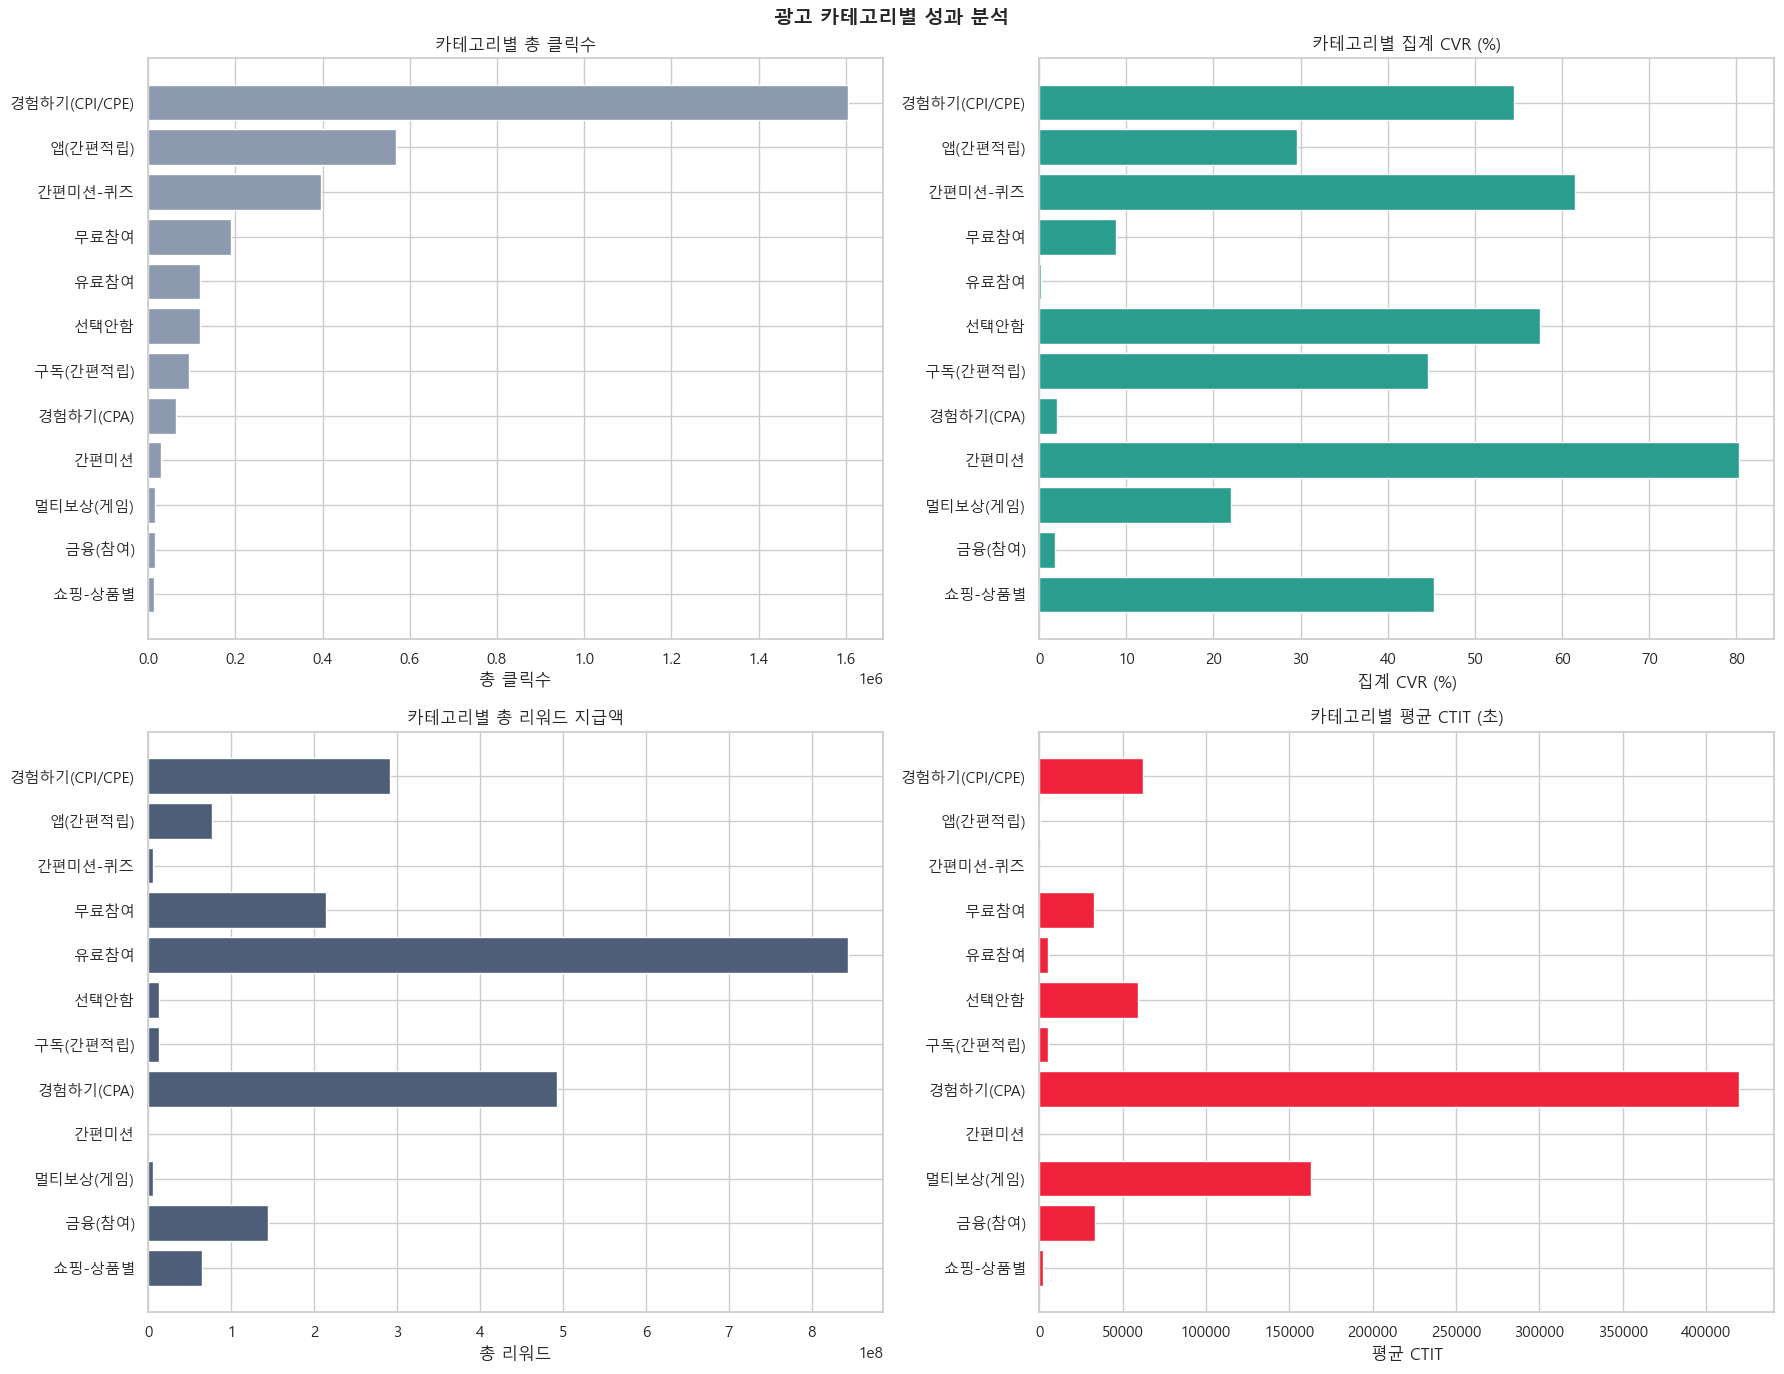

**카테고리별 성과 요약**

,category_name,광고수,총클릭수,총완료수,집계CVR,총리워드,평균ctit
3,경험하기(CPI/CPE),42,1605103,875093,54.52,"291,553,096.00","62,084.57"
10,앱(간편적립),37,569478,168430,29.58,"76,959,284.00",226.79
1,간편미션-퀴즈,3154,396061,243660,61.52,"5,722,557.00",64.15
7,무료참여,86,190475,16804,8.82,"213,841,515.00","32,942.28"
11,유료참여,55,118281,252,0.21,"843,624,927.00","5,004.72"
8,선택안함,31,118250,67994,57.50,"12,575,239.00","59,248.25"
4,구독(간편적립),18,94519,42175,44.62,"12,510,099.00","5,329.38"
2,경험하기(CPA),83,64273,1342,2.09,"492,503,459.00","419,781.54"
0,간편미션,9,28635,22996,80.31,"76,420.00",44.44
6,멀티보상(게임),64,14957,3284,21.96,"5,784,668.00","163,245.86"


In [41]:
# 광고 카테고리별 성과 분석
# - 카테고리별 대표 CVR은 광고별 CVR 단순 평균이 아니라 집계CVR을 사용한다.
# - 집계CVR = 해당 카테고리의 총완료수 / 총클릭수 * 100

cat_agg = (
    ad_df
    .groupby("category_name")
    .agg(
        광고수=("ads_idx", "nunique"),
        총클릭수=("click_cnt", "sum"),
        총완료수=("complete_cnt", "sum"),
        총리워드=("total_reward_cost", "sum"),
        평균ctit=("avg_ctit", "mean"),
    )
    .reset_index()
)

cat_agg["집계CVR"] = safe_divide(
    cat_agg["총완료수"],
    cat_agg["총클릭수"],
    100,
)

cat_agg = (
    cat_agg[
        [
            "category_name",
            "광고수",
            "총클릭수",
            "총완료수",
            "집계CVR",
            "총리워드",
            "평균ctit",
        ]
    ]
    .sort_values("총클릭수", ascending=True)
)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("광고 카테고리별 성과 분석", fontsize=14, fontweight="bold")
#광고 카테고리별 총 클릭 수, 집계CVR, 총 리워드 지급액, 평균 CTIT을 각각의 그래프로 시각화한다. 카테고리는 총 클릭 수 기준으로 정렬해서 보여준다.
axes[0, 0].barh(cat_agg["category_name"], cat_agg["총클릭수"], color=BASE_COLOR)
axes[0, 0].set_title("카테고리별 총 클릭수")
axes[0, 0].set_xlabel("총 클릭수")

axes[0, 1].barh(cat_agg["category_name"], cat_agg["집계CVR"], color="#2A9D8F")
axes[0, 1].set_title("카테고리별 집계 CVR (%)")
axes[0, 1].set_xlabel("집계 CVR (%)")

axes[1, 0].barh(cat_agg["category_name"], cat_agg["총리워드"], color="#4E5D78")
axes[1, 0].set_title("카테고리별 총 리워드 지급액")
axes[1, 0].set_xlabel("총 리워드")

axes[1, 1].barh(cat_agg["category_name"], cat_agg["평균ctit"], color=RISK_COLOR)
axes[1, 1].set_title("카테고리별 평균 CTIT (초)")
axes[1, 1].set_xlabel("평균 CTIT")

plt.tight_layout()
plt.show()

show_table(
    "카테고리별 성과 요약",
    cat_agg.sort_values("총클릭수", ascending=False),
    n=20,
)

In [42]:
# 광고유형 × 카테고리 교차 집계
# - 조합별 대표 CVR은 광고별 CVR 평균이 아니라 집계CVR을 사용한다.
# - 집계CVR = 조합별 총완료수 / 총클릭수 * 100
# - 광고 수, 클릭 수, 완료 수 기준을 함께 적용해 표본이 작은 조합의 과대해석을 줄인다.

cross = (
    ad_df
    .groupby([type_col, "category_name"])
    .agg(
        click_cnt=("click_cnt", "sum"),
        complete_cnt=("complete_cnt", "sum"),
        count=("ads_idx", "nunique"),
    )
    .reset_index()
)

cross["집계CVR"] = safe_divide(
    cross["complete_cnt"],
    cross["click_cnt"],
    100,
)

cross = cross[
    (cross["count"] >= 5)
    & (cross["click_cnt"] >= 1000)
    & (cross["complete_cnt"] >= 100)
].copy()

cross_pivot = cross.pivot(index=type_col, columns="category_name", values="집계CVR")
cross_count = cross.pivot(index=type_col, columns="category_name", values="count")

show_table(
    "집계 CVR 최고 조합 상위 10개(광고 5개 이상, 클릭 1,000건 이상, 완료 100건 이상)",
    cross.sort_values("집계CVR", ascending=False),
    n=10,
)


**집계 CVR 최고 조합 상위 10개(광고 5개 이상, 클릭 1,000건 이상, 완료 100건 이상)**

,analysis_ads_type_label,category_name,click_cnt,complete_cnt,count,집계CVR
3,설치형,선택안함,63905,55708,9,87.17
11,참여형,간편미션,23533,17969,7,76.36
12,참여형,간편미션-퀴즈,396061,243660,3154,61.52
2,설치형,경험하기(CPI/CPE),755727,427114,30,56.52
5,실행형,경험하기(CPI/CPE),848120,447895,8,52.81
0,CPS(물건구매),쇼핑-상품별,13415,6077,32,45.30
4,설치형,앱(간편적립),228068,102622,13,45.00
15,참여형,구독(간편적립),33097,8274,9,25.00
6,실행형,선택안함,53739,12190,8,22.68
20,퀘스트,멀티보상(게임),14957,3284,64,21.96


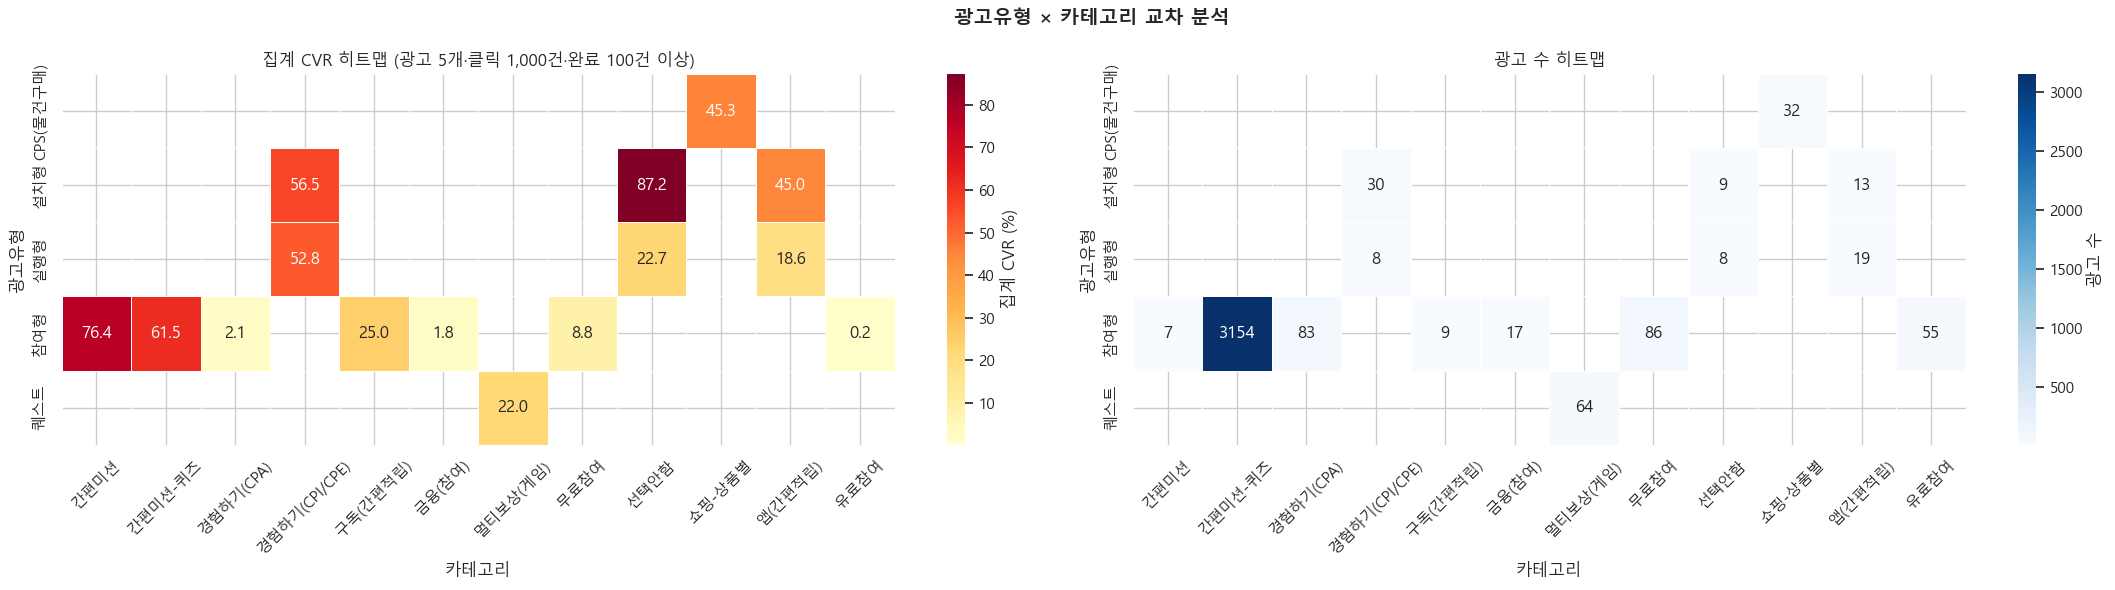

In [43]:
# 광고유형 × 카테고리 교차 히트맵
# - 왼쪽: 조합별 집계 CVR
# - 오른쪽: 해당 조합의 광고 수
# - Cell 24에서 광고 수·클릭 수·완료 수 기준을 통과한 조합만 시각화한다.

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
fig.suptitle("광고유형 × 카테고리 교차 분석", fontsize=14, fontweight="bold")

sns.heatmap(
    cross_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={"label": "집계 CVR (%)"},
)
axes[0].set_title("집계 CVR 히트맵 (광고 5개·클릭 1,000건·완료 100건 이상)")
axes[0].set_xlabel("카테고리")
axes[0].set_ylabel("광고유형")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(
    cross_count,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={"label": "광고 수"},
)
axes[1].set_title("광고 수 히트맵")
axes[1].set_xlabel("카테고리")
axes[1].set_ylabel("광고유형")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 3-2. 보상금액과 성과 분석

**분석 질문** : 보상금액이 높을수록 완료율(CVR)이 함께 높아지는가?

**사용 지표** : 보상금액 구간별 CVR, Spearman 상관계수

**핵심 해석** : 보상금액은 유저 참여를 높일 수 있지만, 보상금액이 높다고 해서 완료율이 반드시 높아지는 것은 아니다.  
이 셀은 보상금액과 CVR의 관계를 우선 확인하고, 수익성 판단은 이후 마진 분석과 운영 후보 분류에서 함께 해석한다.


반응성의 보상구간 = 유저가 어떤 보상 수준에 반응하는가
수익성의 보상구간 = 그 보상이 실제 마진으로 이어지는가


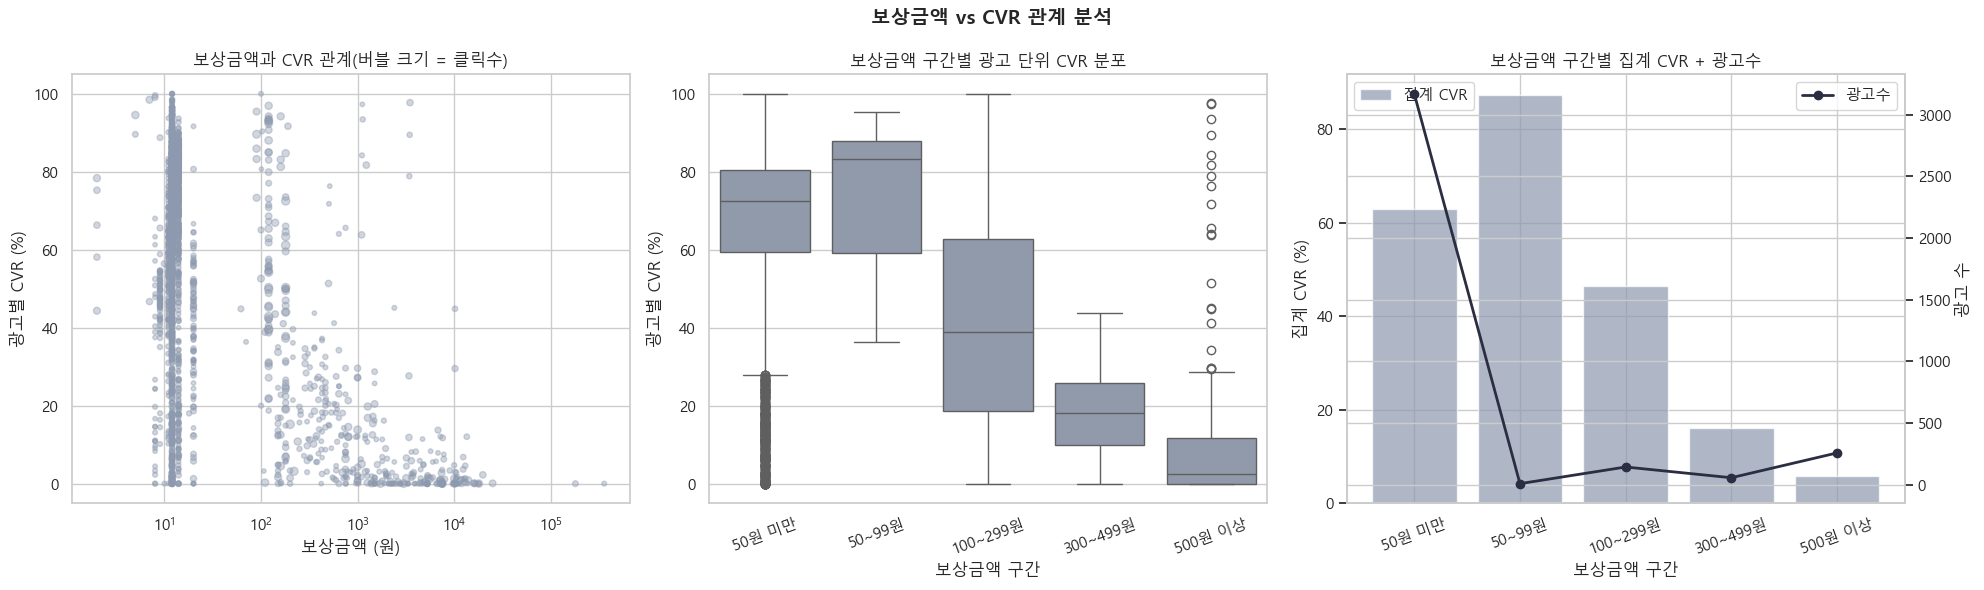

In [44]:
# 보상금액 vs CVR 관계
# - 산점도와 박스플롯은 광고 단위 cvr_pct 분포를 그대로 본다.
# - 구간별 대표 CVR은 광고별 평균이 아니라 집계CVR을 사용한다.

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("보상금액 vs CVR 관계 분석", fontsize=14, fontweight="bold")

scatter_pd = ad_df[["ads_reward_price", "cvr_pct", "click_cnt"]].copy()
scatter_pd["ads_reward_price"] = pd.to_numeric(scatter_pd["ads_reward_price"], errors="coerce")
scatter_pd["cvr_pct"] = pd.to_numeric(scatter_pd["cvr_pct"], errors="coerce")
scatter_pd["click_cnt"] = pd.to_numeric(scatter_pd["click_cnt"], errors="coerce")
scatter_pd = scatter_pd.dropna()
scatter_pd = scatter_pd[scatter_pd["ads_reward_price"] > 0]

axes[0].scatter(
    scatter_pd["ads_reward_price"],
    scatter_pd["cvr_pct"],
    s=np.log1p(scatter_pd["click_cnt"]) * 3,
    alpha=0.4,
    color=BASE_COLOR,
)
axes[0].set_title("보상금액과 CVR 관계(버블 크기 = 클릭수)")
axes[0].set_xlabel("보상금액 (원)")
axes[0].set_ylabel("광고별 CVR (%)")
axes[0].set_xscale("log")

band_order = ["미상", "50원 미만", "50~99원", "100~299원", "300~499원", "500원 이상"]
band_pd = ad_df[["reward_band", "cvr_pct"]].dropna().copy()

sns.boxplot(
    data=band_pd,
    x="reward_band",
    y="cvr_pct",
    order=[b for b in band_order if b in band_pd["reward_band"].unique()],
    ax=axes[1],
    palette=get_plot_colors(len([b for b in band_order if b in band_pd["reward_band"].unique()])),
)
axes[1].set_title("보상금액 구간별 광고 단위 CVR 분포")
axes[1].set_xlabel("보상금액 구간")
axes[1].set_ylabel("광고별 CVR (%)")
axes[1].tick_params(axis="x", rotation=20)

band_agg = (
    ad_df
    .groupby("reward_band")
    .agg(
        click_cnt=("click_cnt", "sum"),
        complete_cnt=("complete_cnt", "sum"),
        count=("ads_idx", "nunique"),
    )
    .reset_index()
)

band_agg["집계CVR"] = safe_divide(
    band_agg["complete_cnt"],
    band_agg["click_cnt"],
    100,
)

band_agg = (
    band_agg
    .set_index("reward_band")
    .reindex([b for b in band_order if b in band_agg["reward_band"].values])
    .reset_index()
)

ax2 = axes[2].twinx()
axes[2].bar(
    band_agg["reward_band"],
    band_agg["집계CVR"],
    color=get_plot_colors(len(band_agg)),
    alpha=0.7,
    label="집계 CVR",
)
ax2.plot(
    band_agg["reward_band"],
    band_agg["count"],
    color=LINE_COLOR,
    marker="o",
    linewidth=2,
    label="광고수",
)
axes[2].set_title("보상금액 구간별 집계 CVR + 광고수")
axes[2].set_xlabel("보상금액 구간")
axes[2].set_ylabel("집계 CVR (%)")
ax2.set_ylabel("광고 수")
axes[2].tick_params(axis="x", rotation=20)
axes[2].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [45]:
# 보상금액 × CVR Spearman 상관분석

reward_cvr_test = ad_df[
    ["ads_idx", "ads_reward_price", "cvr_pct"]
].dropna().copy()

reward_cvr_test["ads_reward_price"] = pd.to_numeric(
    reward_cvr_test["ads_reward_price"],
    errors="coerce",
)

reward_cvr_test["cvr_pct"] = pd.to_numeric(
    reward_cvr_test["cvr_pct"],
    errors="coerce",
)

reward_cvr_test = reward_cvr_test[
    reward_cvr_test["ads_reward_price"] > 0
].copy()

reward_corr, reward_p_value = spearmanr(
    reward_cvr_test["ads_reward_price"],
    reward_cvr_test["cvr_pct"],
)

reward_cvr_result = pd.DataFrame([{
    "검정": "보상금액과 CVR의 순위 상관",
    "검정방법": "Spearman",
    "rho": reward_corr,
    "p값": reward_p_value,
}])

show_table("보상금액 × CVR Spearman 상관분석 결과", reward_cvr_result, n=5)

**보상금액 × CVR Spearman 상관분석 결과**

,검정,검정방법,rho,p값
0,보상금액과 CVR의 순위 상관,Spearman,-0.25,0.00


In [46]:
# reward_band 별 반응성 평가 전 집계 테이블 생성

reward_summary = (
    ads_analysis_base
    .group_by("reward_band")
    .agg([
        # 평균 클릭수
        pl.col("total_click_cnt").mean().alias("avg_click"),
        # 평균 완료수
        pl.col("total_complete_cnt").mean().alias("avg_complete"),
        # 평균 CVR
        pl.col("total_cvr").mean().alias("avg_cvr"),
        # 중앙값
        pl.col("total_click_cnt").median().alias("median_click"),
        pl.col("total_complete_cnt").median().alias("median_complete"),
        pl.col("total_cvr").median().alias("median_cvr"),
        # 광고 수
        pl.len().alias("ads_cnt")
    ])
    .with_columns(
        pl.col("reward_band")
        .replace({band: i for i, band in enumerate(band_order)})
        .cast(pl.Int64)
        .alias("band_order")
    )
    .sort("band_order")
    .drop("band_order")
    .to_pandas()
)

reward_summary

,reward_band,avg_click,avg_complete,avg_cvr,median_click,median_complete,median_cvr,ads_cnt
0,50원 미만,130.80,78.39,63.56,82.00,51.00,70.00,3019
1,50~99원,"6,982.00","5,718.86",69.53,"4,103.00","3,550.00",73.46,7
2,100~299원,"16,533.74","7,576.48",39.33,"1,538.00",732.00,35.34,140
3,300~499원,235.89,36.85,17.63,80.00,15.00,17.50,55
4,500원 이상,"1,435.71",70.86,8.46,125.50,3.00,1.95,254


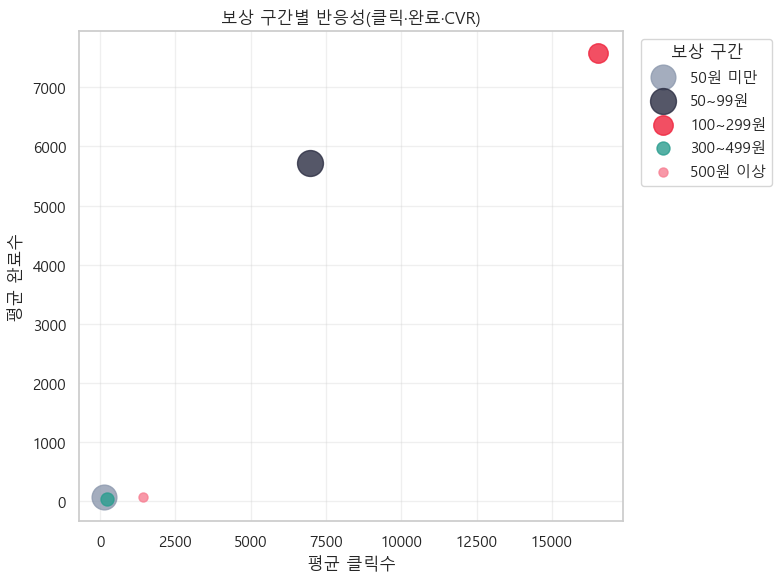

In [47]:
# 사용할 컬러 지정
reward_colors = [
    "#8D99AE",
    "#2B2D42",
    "#EF233C",
    "#2A9D8F",
    "#F77F92"
]

# x축=클릭, y축=완료, 점 크기=CVR
plt.figure(figsize=(8, 6))

for i in range(len(reward_summary)):
    plt.scatter(
        reward_summary["avg_click"].iloc[i],
        reward_summary["avg_complete"].iloc[i],
        s=reward_summary["avg_cvr"].iloc[i] * 5,
        label=reward_summary["reward_band"].iloc[i],
        color=reward_colors[i],   # 색상 지정
        alpha=0.8
    )

plt.title("보상 구간별 반응성(클릭·완료·CVR)")
plt.xlabel("평균 클릭수")
plt.ylabel("평균 완료수")
plt.grid(alpha=0.3)

# 범례
plt.legend(
    title="보상 구간",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### 3-2-1. 보상구간별 반응성 해석

- 100~299원 구간은 클릭수와 완료수가 모두 높아, 반응성 측면에서 가장 두드러지는 구간으로 확인된다.
- 50~99원 구간은 완료 성과는 양호하지만 클릭이 상대적으로 낮아, 노출 기회가 부족했을 가능성이 있다.
- 300원 이상 구간은 클릭수와 완료수가 낮아 고보상 광고가 항상 높은 반응성을 보장하지는 않는다.
- 50원 미만 구간은 운영상 영향력이 작다.


### #부록 반응성 분석: 클릭수와 CVR 관계 보조 분석


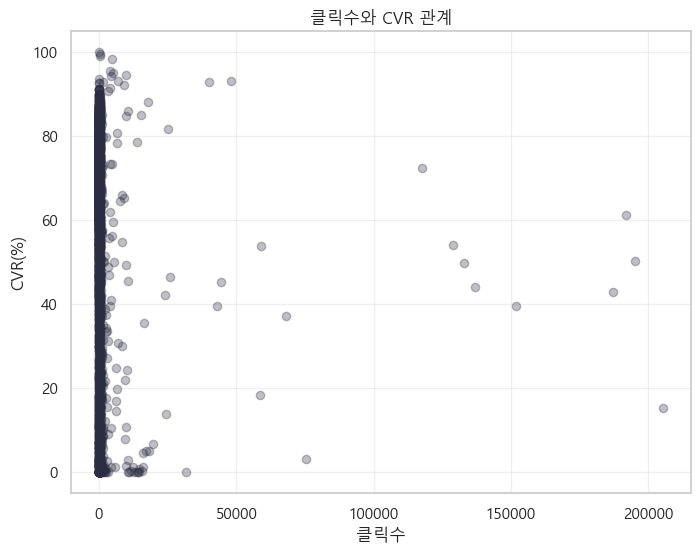

In [48]:
# 클릭수와 CVR 관계

plt.figure(figsize=(8,6))

plt.scatter(
    ads_analysis_base["total_click_cnt"].to_numpy(),
    ads_analysis_base["total_cvr"].to_numpy(),
    alpha=0.3
)

plt.xlabel("클릭수")
plt.ylabel("CVR(%)")
plt.title("클릭수와 CVR 관계")

plt.grid(alpha=0.3)
plt.show()

#### 클릭수-CVR 산점도 해석
- 왼쪽에 몰린 점들은 클릭수가 거의 없는 광고다.
- 클릭수가 매우 높은 광고는 CVR이 중간 또는 낮은 구간에 위치하는 경우가 있다.
- CVR이 높은 광고라도 클릭수가 적은 경우에는 표본 착시 가능성이 있으므로 해석에 주의가 필요하다.

#### 클릭수와 CVR의 관계에 대한 통계적 확인

In [49]:
# 클릭수 × CVR Spearman 상관분석

click_cvr_test = (
    ads_eval
    .select(["ads_idx", "total_click_cnt", "total_cvr"])
    .drop_nulls()
    .to_pandas()
)

click_cvr_test = click_cvr_test[
    (click_cvr_test["total_click_cnt"] > 0) &
    (click_cvr_test["total_cvr"] >= 0)
].copy()

corr, p_value = spearmanr(
    click_cvr_test["total_click_cnt"],
    click_cvr_test["total_cvr"]
)

click_cvr_corr_result = pd.DataFrame([{
    "검정": "클릭수와 CVR의 순위 상관",
    "검정방법": "Spearman",
    "rho": corr,
    "p값": p_value,
}])

show_table("클릭수 × CVR Spearman 상관분석 결과", click_cvr_corr_result, n=5)

**클릭수 × CVR Spearman 상관분석 결과**

,검정,검정방법,rho,p값
0,클릭수와 CVR의 순위 상관,Spearman,-0.07,0.00


CVR Spearman -0.07 = 클릭 규모가 크다고 CVR이 높아지는 구조는 아니다.

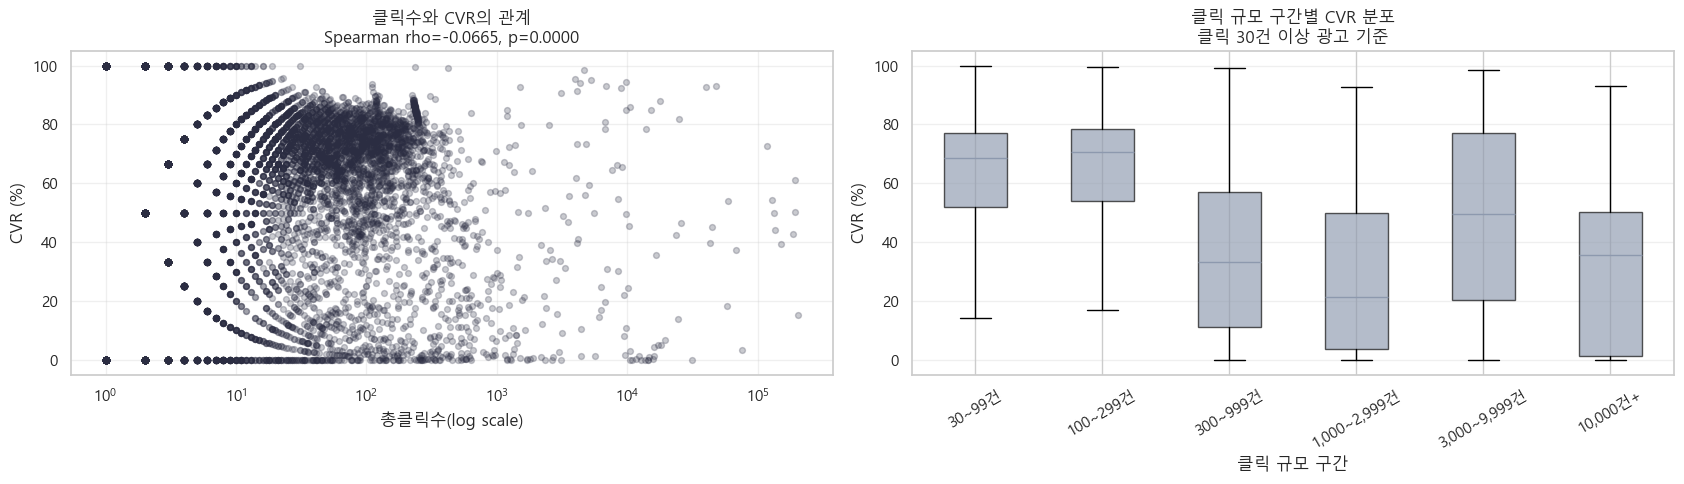

In [50]:
# 클릭수 × CVR 관계 시각화
# - 산점도: 전체 광고 분포 확인
# - boxplot: 클릭 규모 구간별 CVR 분포 확인

click_cvr_bin_test = click_cvr_test[
    click_cvr_test["total_click_cnt"] >= 30
].copy()

click_bins = [30, 100, 300, 1000, 3000, 10000, np.inf]
click_labels = [
    "30~99건",
    "100~299건",
    "300~999건",
    "1,000~2,999건",
    "3,000~9,999건",
    "10,000건+",
]

click_cvr_bin_test["클릭규모구간"] = pd.cut(
    click_cvr_bin_test["total_click_cnt"],
    bins=click_bins,
    labels=click_labels,
    right=False,
)

box_data = [
    click_cvr_bin_test.loc[
        click_cvr_bin_test["클릭규모구간"] == label,
        "total_cvr"
    ].dropna().values
    for label in click_labels
]

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

axes[0].scatter(
    click_cvr_test["total_click_cnt"],
    click_cvr_test["total_cvr"],
    alpha=0.25,
    s=18,
)

axes[0].set_xscale("log")
axes[0].set_title(f"클릭수와 CVR의 관계\nSpearman rho={corr:.4f}, p={p_value:.4f}")
axes[0].set_xlabel("총클릭수(log scale)")
axes[0].set_ylabel("CVR (%)")
axes[0].grid(alpha=0.3)

bp = axes[1].boxplot(
    box_data,
    labels=click_labels,
    patch_artist=True,
    showfliers=False,
)

box_colors = get_plot_colors(len(bp["boxes"]))
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

axes[1].set_title("클릭 규모 구간별 CVR 분포\n클릭 30건 이상 광고 기준")
axes[1].set_xlabel("클릭 규모 구간")
axes[1].set_ylabel("CVR (%)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

클릭수와 CVR의 Spearman 상관계수는 -0.0665로 거의 관계가 없었다.
클릭 규모 구간별로 보아도 CVR이 일관되게 증가하지 않았다.
따라서 클릭 규모가 큰 광고와 반응성이 좋은 광고는 분리해서 평가해야 한다.

---
### 3-3. 시간대별 클릭/완료/CVR/CTIT 분석

**분석 질문** : 시간대별로 클릭 수와 완료율이 어떻게 다른가? 양자가 불일치하는 시간대는 언제인가?

**사용 지표** : 시간대별 클릭 수, 완료율, 평균 CTIT, Kruskal-Wallis test

**역할 구분** : 이 절의 시간대 분석은 유저가 언제 광고에 잘 반응하고, 클릭이 완료까지 얼마나 빠르게 이어지는지 확인하는 반응성 진단이다.

**핵심 해석** : 클릭 수만 보면 유입이 많은 시간을 알 수 있지만, 트래픽 품질은 CVR과 CTIT를 함께 봐야 판단할 수 있다.  
마진은 집계 단위가 다른 수익성 축에서 별도로 해석하고, 이 절에서는 시간대별 유입·완료 패턴에 집중한다.


In [51]:
palette="#EF233C", "#2B2D42"


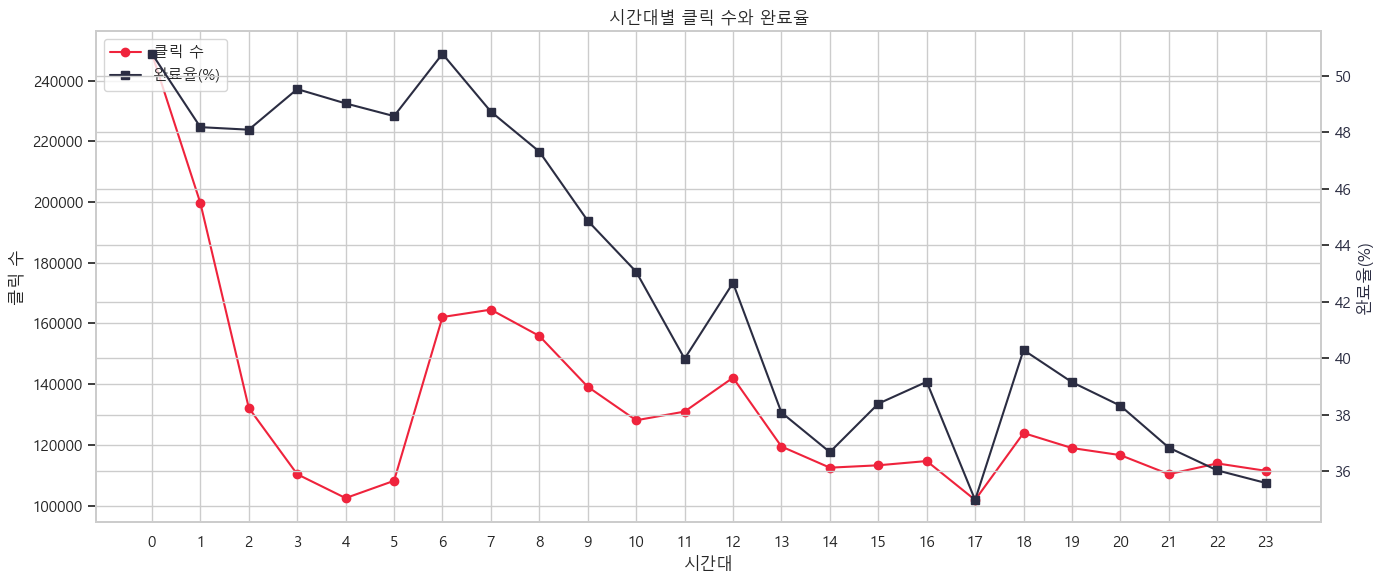

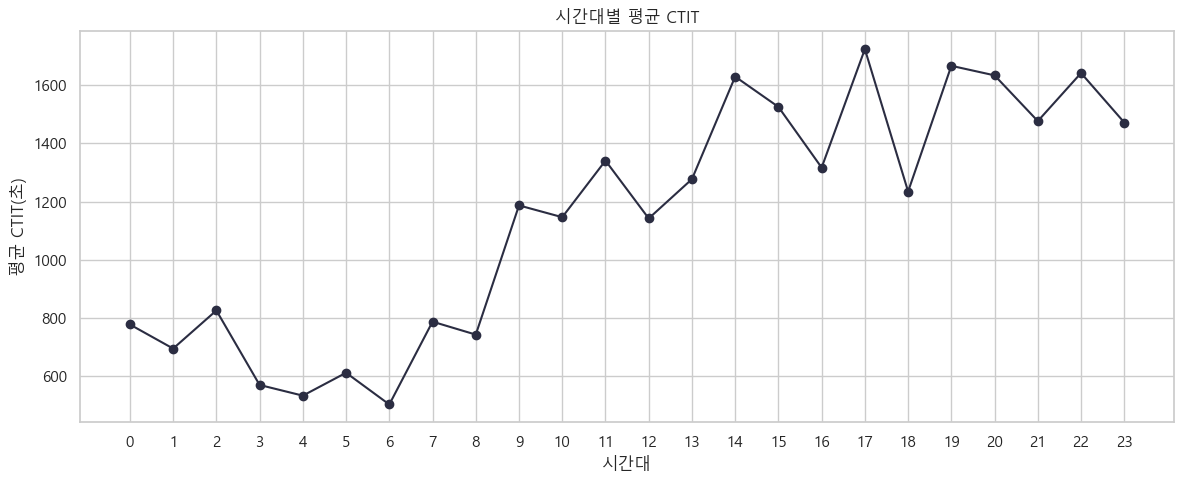

**시간대별 퍼널 요약**

,click_hour,click_cnt,complete_cnt,avg_ctit,cvr
0,0,248871,126359,778.05,50.77
1,1,199683,96195,695.39,48.17
2,2,132198,63566,826.20,48.08
3,3,110347,54643,570.47,49.52
4,4,102487,50232,533.74,49.01
5,5,108181,52537,612.37,48.56
6,6,162124,82304,503.45,50.77
7,7,164557,80174,787.76,48.72
8,8,155890,73750,743.32,47.31
9,9,139153,62429,"1,186.92",44.86


In [52]:
# 시간대별 클릭 수, 완료율, 평균 CTIT

# 컬러 지정
palette = ["#EF233C", "#2B2D42"]

hourly_funnel = (
    main_funnel_work
    .groupby("click_hour")
    .agg(
        click_cnt=("click_key", "count"),
        complete_cnt=("is_completed", "sum"),
        avg_ctit=("ctit", "mean"),
    )
    .reset_index()
    .sort_values("click_hour")
)

hourly_funnel["cvr"] = safe_divide(
    hourly_funnel["complete_cnt"],
    hourly_funnel["click_cnt"],
    100
)

fig, ax1 = plt.subplots(figsize=(14, 6))

# 클릭 수
line1 = ax1.plot(
    hourly_funnel["click_hour"],
    hourly_funnel["click_cnt"],
    color=palette[0],
    marker="o",
    label="클릭 수"
)

ax1.set_xlabel("시간대")
ax1.set_ylabel("클릭 수")
ax1.set_xticks(range(0, 24))


# 완료율
ax2 = ax1.twinx()

line2 = ax2.plot(
    hourly_funnel["click_hour"],
    hourly_funnel["cvr"],
    color=palette[1],
    marker="s",
    label="완료율(%)"
)

ax2.set_ylabel("완료율(%)")

ax2.set_ylabel("완료율(%)", color=palette[1])
ax2.tick_params(axis="y", labelcolor=palette[1])

# 범례 통합
lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc="upper left")

plt.title("시간대별 클릭 수와 완료율")

plt.tight_layout()
plt.show()


# 평균 CTIT
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_funnel["click_hour"],
    hourly_funnel["avg_ctit"],
    marker="o",
    color=palette[1]
)

plt.title("시간대별 평균 CTIT")
plt.xlabel("시간대")
plt.ylabel("평균 CTIT(초)")
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

show_table("시간대별 퍼널 요약", hourly_funnel, n=24)

### 반응성 분석: 요일 × 시간대 분석
**분석 질문** : 요일과 시간대 조합에 따라 클릭 수와 완료율이 어떻게 달라지는가?

**사용 지표** : 요일 × 시간대 클릭 수 히트맵, CVR 히트맵, Kruskal-Wallis test

**역할 구분** : 이 절은 시간대와 요일의 조합에 따라 유저 반응성이 달라지는지 확인한다.

**핵심 해석** : 클릭이 몰리는 시간대와 실제 효율이 좋은 시간대가 다르다면, 단순 트래픽 확대보다 효율 기반 시간대 운영이 적합하다.


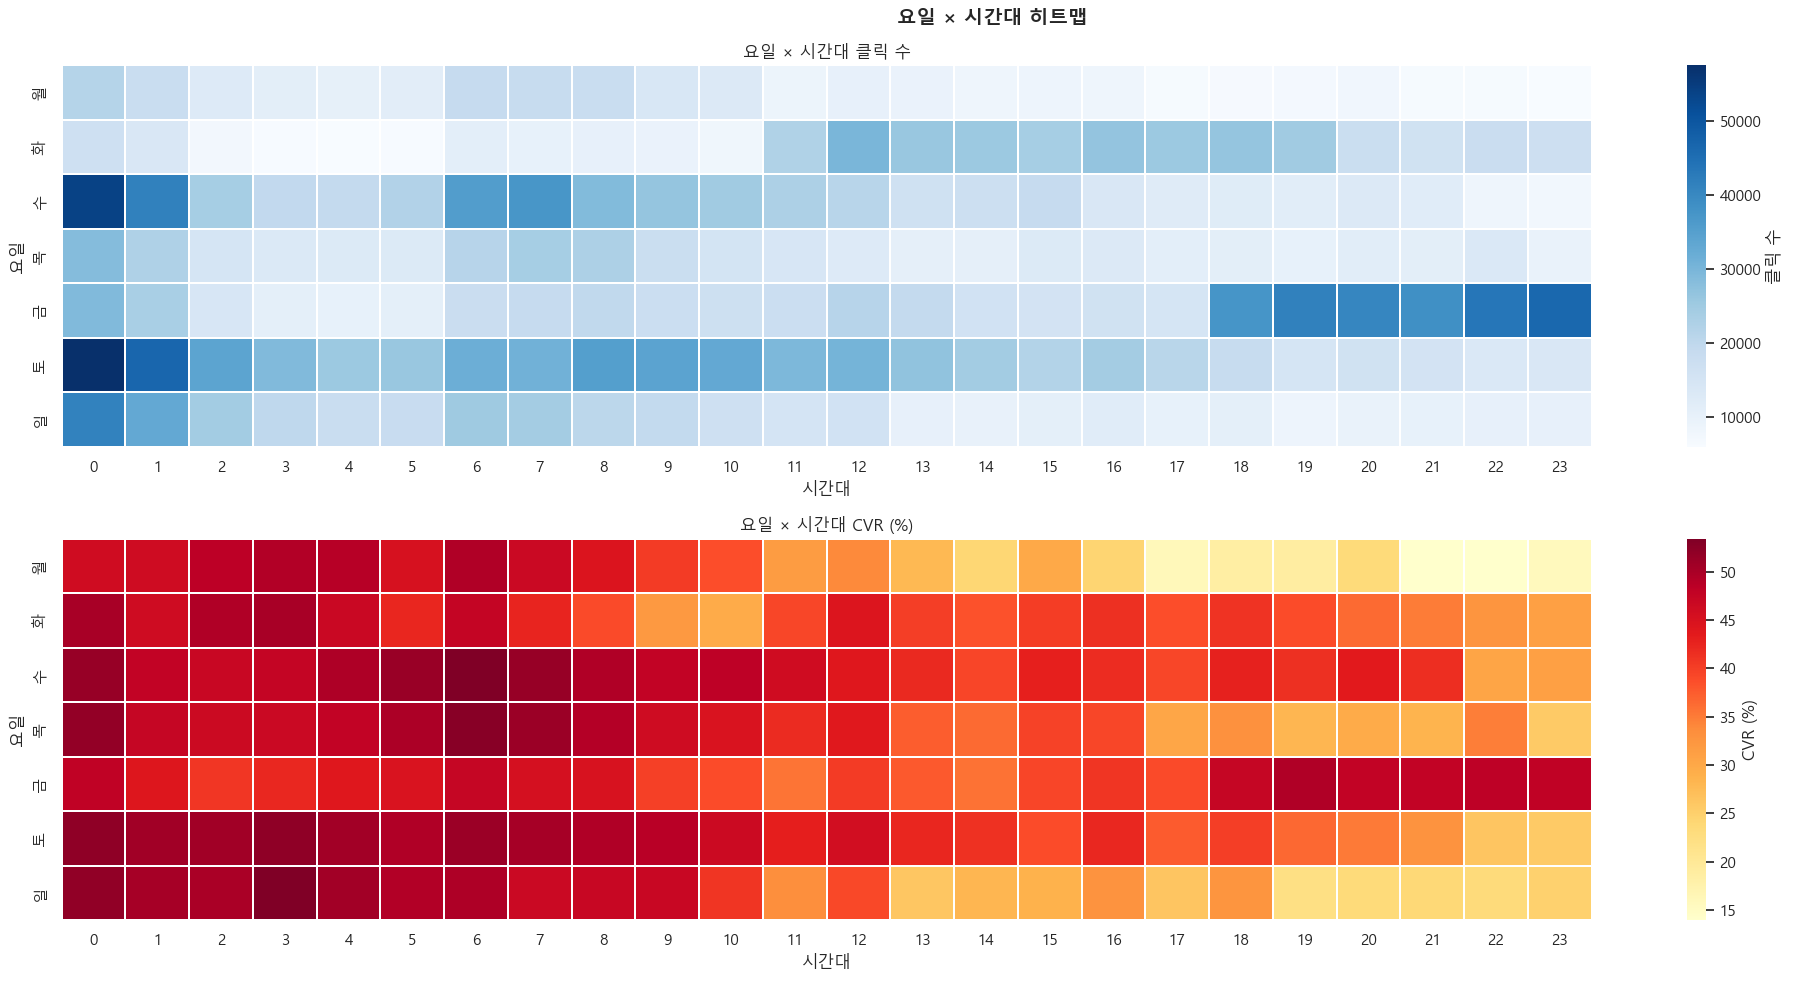

In [53]:
# 요일 × 시간대 히트맵 (클릭 수, CVR)
weekday_order = ["월", "화", "수", "목", "금", "토", "일"]

wh_base = (
    main_funnel_work
    .dropna(subset=["click_weekday", "click_hour"])
    .groupby(["click_weekday", "click_hour"])
    .agg(
        click_cnt=("click_key", "count"),
        complete_cnt=("is_completed", "sum"),
    )
    .reset_index()
)

wh_base["cvr"] = safe_divide(
    wh_base["complete_cnt"],
    wh_base["click_cnt"],
    100,
)

wh_pivot_click = (
    wh_base
    .pivot(index="click_weekday", columns="click_hour", values="click_cnt")
    .reindex(weekday_order)
)

wh_pivot_cvr = (
    wh_base
    .pivot(index="click_weekday", columns="click_hour", values="cvr")
    .reindex(weekday_order)
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
fig.suptitle("요일 × 시간대 히트맵", fontsize=14, fontweight="bold")

sns.heatmap(
    wh_pivot_click,
    cmap="Blues",
    annot=False,
    fmt=".0f",
    linewidths=0.3,
    ax=ax1,
    cbar_kws={"label": "클릭 수"},
)
ax1.set_title("요일 × 시간대 클릭 수")
ax1.set_xlabel("시간대")
ax1.set_ylabel("요일")

sns.heatmap(
    wh_pivot_cvr,
    cmap="YlOrRd",
    annot=False,
    fmt=".1f",
    linewidths=0.3,
    ax=ax2,
    cbar_kws={"label": "CVR (%)"},
)
ax2.set_title("요일 × 시간대 CVR (%)")
ax2.set_xlabel("시간대")
ax2.set_ylabel("요일")

plt.tight_layout()
plt.show()


In [54]:
# 시간대·요일별 CVR 차이 검정용 데이터 생성
# - 클릭 1건 단위가 아니라 광고 × 시간대 / 광고 × 요일 단위 CVR을 사용한다.
# - 클릭 30건 이상 조합만 사용한다.

MIN_TIME_WEEKDAY_TEST_CLICKS = 30

hour_cvr_test = (
    main_funnel_work
    .dropna(subset=["click_hour"])
    .groupby(["ads_idx", "click_hour"])
    .agg(
        click_cnt=("click_key", "count"),
        complete_cnt=("is_completed", "sum"),
    )
    .reset_index()
)

hour_cvr_test["cvr"] = safe_divide(
    hour_cvr_test["complete_cnt"],
    hour_cvr_test["click_cnt"],
    100,
)

hour_cvr_test = hour_cvr_test[
    hour_cvr_test["click_cnt"] >= MIN_TIME_WEEKDAY_TEST_CLICKS
].copy()

hour_cvr_test["click_hour"] = hour_cvr_test["click_hour"].astype(int)


weekday_cvr_test = (
    main_funnel_work
    .dropna(subset=["click_weekday"])
    .groupby(["ads_idx", "click_weekday"])
    .agg(
        click_cnt=("click_key", "count"),
        complete_cnt=("is_completed", "sum"),
    )
    .reset_index()
)

weekday_cvr_test["cvr"] = safe_divide(
    weekday_cvr_test["complete_cnt"],
    weekday_cvr_test["click_cnt"],
    100,
)

weekday_cvr_test = weekday_cvr_test[
    weekday_cvr_test["click_cnt"] >= MIN_TIME_WEEKDAY_TEST_CLICKS
].copy()

weekday_cvr_test["click_weekday"] = pd.Categorical(
    weekday_cvr_test["click_weekday"],
    categories=weekday_order,
    ordered=True,
)

In [55]:
# 시간대·요일별 CVR 차이 Kruskal-Wallis 검정

hour_order = list(range(24))

hour_groups = [
    hour_cvr_test.loc[hour_cvr_test["click_hour"] == h, "cvr"].dropna().values
    for h in hour_order
]

hour_kw_stat, hour_kw_p = kruskal(*hour_groups)
hour_group_n = len(hour_groups)
hour_obs_n = len(hour_cvr_test)

hour_epsilon_sq = max(
    0,
    (hour_kw_stat - hour_group_n + 1) / (hour_obs_n - hour_group_n),
)


weekday_groups = [
    weekday_cvr_test.loc[weekday_cvr_test["click_weekday"] == day, "cvr"].dropna().values
    for day in weekday_order
]

weekday_kw_stat, weekday_kw_p = kruskal(*weekday_groups)
weekday_group_n = len(weekday_groups)
weekday_obs_n = len(weekday_cvr_test)

weekday_epsilon_sq = max(
    0,
    (weekday_kw_stat - weekday_group_n + 1) / (weekday_obs_n - weekday_group_n),
)


time_weekday_kw_result = pd.DataFrame([
    {
        "검정": "시간대별 CVR 차이",
        "검정단위": "광고 × 시간대",
        "그룹수": hour_group_n,
        "관측조합수": hour_obs_n,
        "H통계량": hour_kw_stat,
        "p값": hour_kw_p,
        "효과크기": hour_epsilon_sq,
    },
    {
        "검정": "요일별 CVR 차이",
        "검정단위": "광고 × 요일",
        "그룹수": weekday_group_n,
        "관측조합수": weekday_obs_n,
        "H통계량": weekday_kw_stat,
        "p값": weekday_kw_p,
        "효과크기": weekday_epsilon_sq,
    },
])

show_table("시간대·요일별 CVR 차이 Kruskal-Wallis 검정 결과", time_weekday_kw_result, n=10)

**시간대·요일별 CVR 차이 Kruskal-Wallis 검정 결과**

,검정,검정단위,그룹수,관측조합수,H통계량,p값,효과크기
0,시간대별 CVR 차이,광고 × 시간대,24,6783,617.87,0.00,0.09
1,요일별 CVR 차이,광고 × 요일,7,5046,37.91,0.00,0.01


**시간대별 광고 × 시간대 CVR 요약**

,시간대,광고수,관측조합수,총클릭수,총완료수,평균CVR,중앙값CVR
0,0,377,377,237891,120777,55.37,66.10
1,1,312,312,187961,89467,51.65,54.97
2,2,164,164,124768,59863,38.41,38.26
3,3,146,146,104144,51703,38.54,39.92
4,4,125,125,94307,46047,36.01,33.92
5,5,157,157,100957,49059,37.12,36.31
6,6,422,422,142606,70662,54.60,64.71
7,7,475,475,148102,70785,55.47,66.67
8,8,504,504,135819,62361,54.05,62.77
9,9,430,430,124348,54111,52.70,64.58


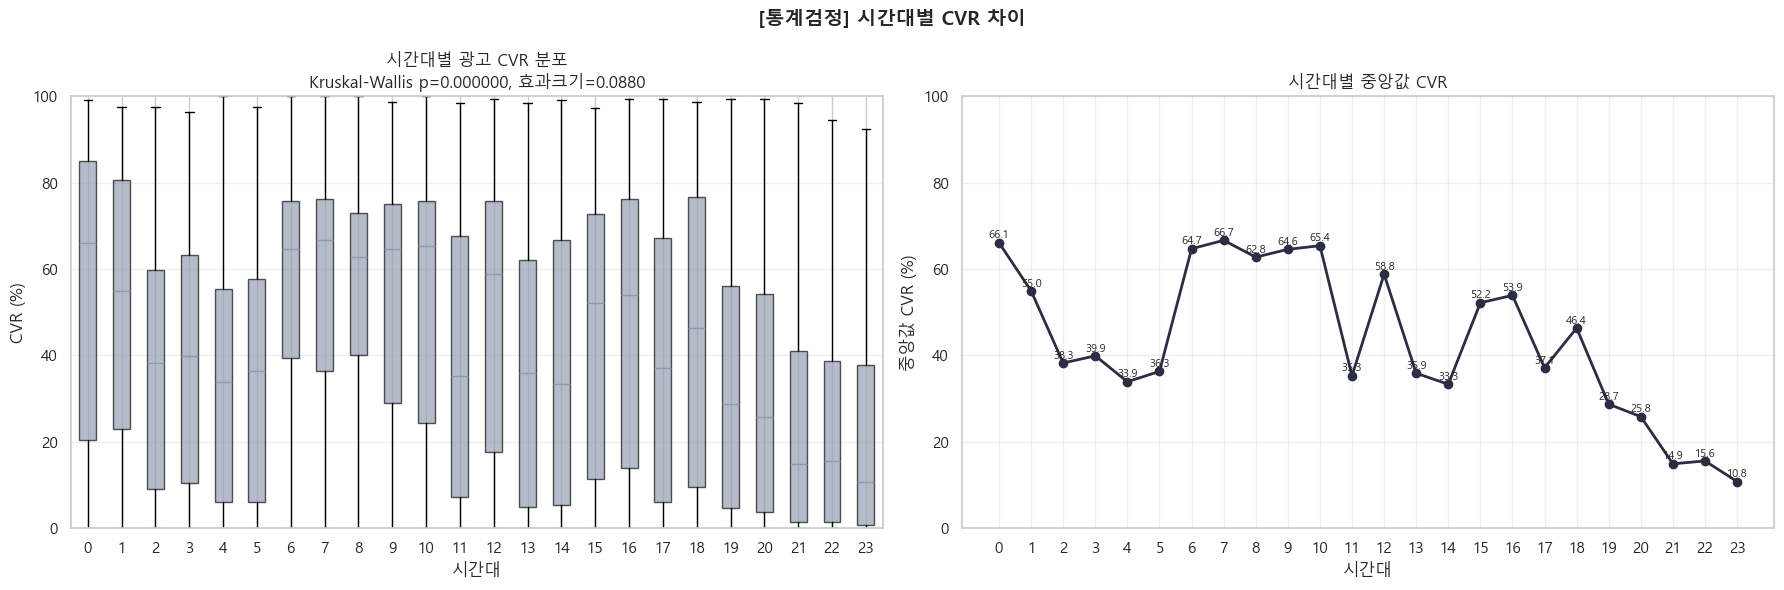

In [56]:
# 시간대별 CVR 요약 및 시각화

hour_cvr_summary = (
    hour_cvr_test
    .groupby("click_hour")
    .agg(
        ads_cnt=("ads_idx", "nunique"),
        obs_cnt=("ads_idx", "count"),
        total_click=("click_cnt", "sum"),
        total_complete=("complete_cnt", "sum"),
        mean_cvr=("cvr", "mean"),
        median_cvr=("cvr", "median"),
    )
    .reset_index()
    .sort_values("click_hour")
)

hour_cvr_summary_display = hour_cvr_summary.rename(columns={
    "click_hour": "시간대",
    "ads_cnt": "광고수",
    "obs_cnt": "관측조합수",
    "total_click": "총클릭수",
    "total_complete": "총완료수",
    "mean_cvr": "평균CVR",
    "median_cvr": "중앙값CVR",
})

show_table("시간대별 광고 × 시간대 CVR 요약", hour_cvr_summary_display, n=24)

hour_box_data = [
    hour_cvr_test.loc[hour_cvr_test["click_hour"] == h, "cvr"].dropna().values
    for h in hour_order
]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

bp = axes[0].boxplot(
    hour_box_data,
    labels=hour_order,
    patch_artist=True,
    showfliers=False,
)

box_colors = get_plot_colors(len(bp["boxes"]))
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

axes[0].set_title(
    f"시간대별 광고 CVR 분포\nKruskal-Wallis p={hour_kw_p:.6f}, 효과크기={hour_epsilon_sq:.4f}"
)
axes[0].set_xlabel("시간대")
axes[0].set_ylabel("CVR (%)")
axes[0].set_ylim(0, 100)
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(
    hour_cvr_summary["click_hour"],
    hour_cvr_summary["median_cvr"],
    marker="o",
    linewidth=2,
)

for _, row in hour_cvr_summary.iterrows():
    axes[1].text(
        row["click_hour"],
        row["median_cvr"] + 1,
        f'{row["median_cvr"]:.1f}',
        ha="center",
        fontsize=8,
    )

axes[1].set_title("시간대별 중앙값 CVR")
axes[1].set_xlabel("시간대")
axes[1].set_ylabel("중앙값 CVR (%)")
axes[1].set_xticks(hour_order)
axes[1].set_ylim(0, 100)
axes[1].grid(alpha=0.3)

plt.suptitle("[통계검정] 시간대별 CVR 차이", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**요일별 광고 × 요일 CVR 요약**

,요일,광고수,관측조합수,총클릭수,총완료수,평균CVR,중앙값CVR
0,월,811,811,249220,89184,52.33,63.64
1,화,605,605,391040,154776,47.27,52.94
2,수,699,699,502912,234184,48.30,57.89
3,목,641,641,341503,144637,47.53,56.25
4,금,625,625,542062,240422,48.11,58.09
5,토,824,824,635672,287974,53.04,64.72
6,일,841,841,384952,158157,53.29,64.15


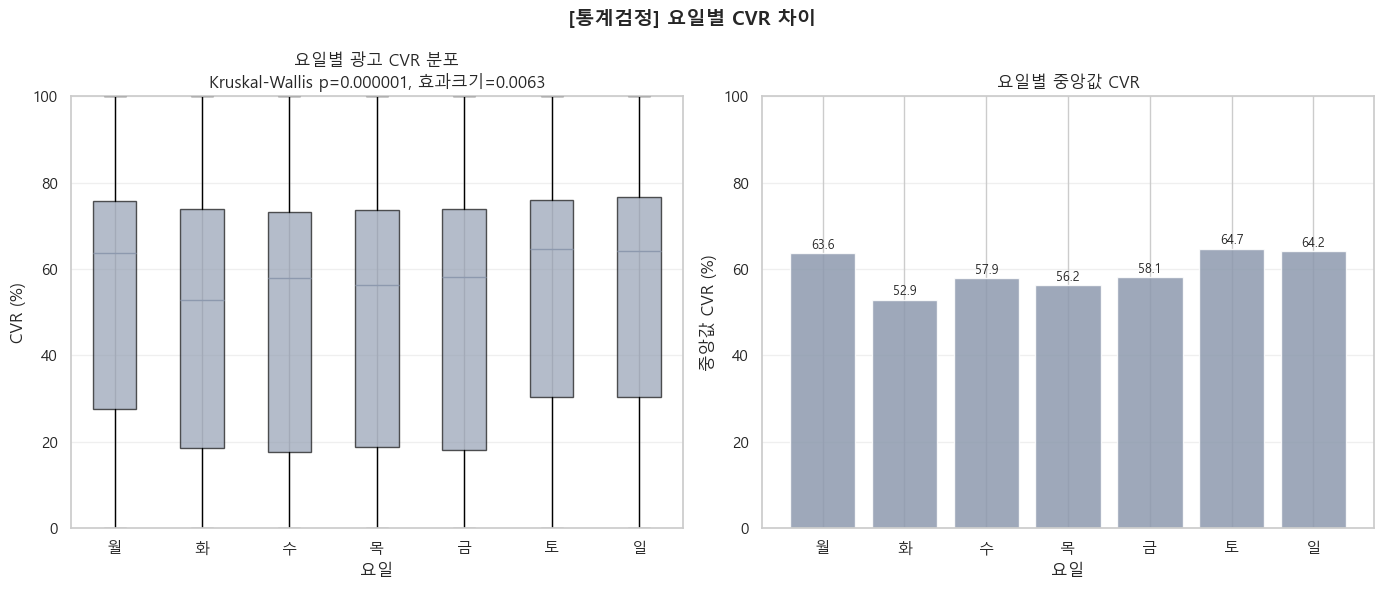

In [57]:
# 요일별 CVR 요약 및 시각화

weekday_cvr_summary = (
    weekday_cvr_test
    .groupby("click_weekday", observed=False)
    .agg(
        ads_cnt=("ads_idx", "nunique"),
        obs_cnt=("ads_idx", "count"),
        total_click=("click_cnt", "sum"),
        total_complete=("complete_cnt", "sum"),
        mean_cvr=("cvr", "mean"),
        median_cvr=("cvr", "median"),
    )
    .reset_index()
    .sort_values("click_weekday")
)

weekday_cvr_summary_display = weekday_cvr_summary.rename(columns={
    "click_weekday": "요일",
    "ads_cnt": "광고수",
    "obs_cnt": "관측조합수",
    "total_click": "총클릭수",
    "total_complete": "총완료수",
    "mean_cvr": "평균CVR",
    "median_cvr": "중앙값CVR",
})

show_table("요일별 광고 × 요일 CVR 요약", weekday_cvr_summary_display, n=7)

weekday_box_data = [
    weekday_cvr_test.loc[weekday_cvr_test["click_weekday"] == day, "cvr"].dropna().values
    for day in weekday_order
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bp = axes[0].boxplot(
    weekday_box_data,
    labels=weekday_order,
    patch_artist=True,
    showfliers=False,
)

weekday_colors = get_plot_colors(len(weekday_order))

for patch, color in zip(bp["boxes"], weekday_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

axes[0].set_title(
    f"요일별 광고 CVR 분포\nKruskal-Wallis p={weekday_kw_p:.6f}, 효과크기={weekday_epsilon_sq:.4f}"
)
axes[0].set_xlabel("요일")
axes[0].set_ylabel("CVR (%)")
axes[0].set_ylim(0, 100)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    weekday_cvr_summary["click_weekday"].astype(str),
    weekday_cvr_summary["median_cvr"],
    color=weekday_colors,
    alpha=0.85,
)

for i, value in enumerate(weekday_cvr_summary["median_cvr"]):
    axes[1].text(
        i,
        value + 1,
        f"{value:.1f}",
        ha="center",
        fontsize=9,
    )

axes[1].set_title("요일별 중앙값 CVR")
axes[1].set_xlabel("요일")
axes[1].set_ylabel("중앙값 CVR (%)")
axes[1].set_ylim(0, 100)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("[통계검정] 요일별 CVR 차이", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

시간대별 CVR 차이
→ p-value 유의, 효과크기=0.0880
→ 시간대에 따른 CVR 차이가 어느 정도 존재한다고 볼 수 있음

요일별 CVR 차이
→ p-value 유의, 효과크기=0.0063
→ 통계적으로는 유의하지만 효과크기는 매우 작음
→ 요일 차이는 시간대 차이보다 운영상 영향이 약할 수 있음

---
### 3-4. 광고유형 × 시간대 분석

**분석 질문** : 광고유형별로 성과가 좋은 시간대가 다른가?

**사용 지표** : 광고유형 × 시간대 CVR 히트맵, 광고유형별 최적 시간대 TOP5

**역할 구분** : 이 절은 광고유형별로 반응성이 높은 시간대가 다른지 확인해, 유형별 운영 시간대 차이를 해석한다.

**핵심 해석** : 모든 광고를 같은 시간대에 노출하는 방식은 비효율적일 수 있다. 광고유형별 최적 시간대가 다르다면 시간대 운영도 유형별로 설계한다.


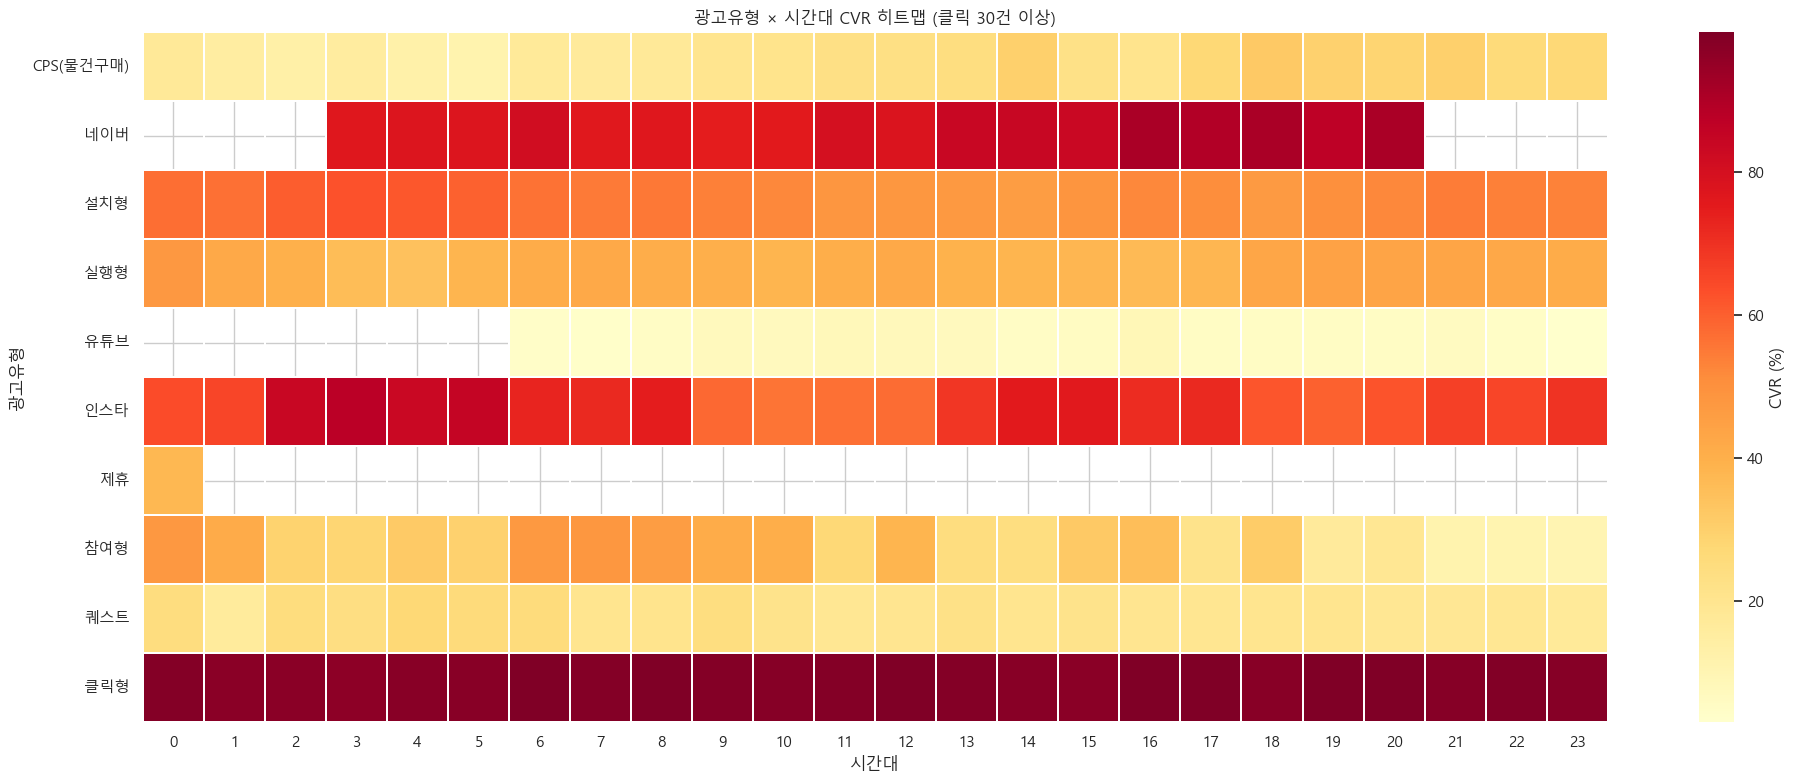

**광고유형별 CVR 상위 시간대 TOP5**

,광고유형,시간대,클릭수,완료수,CVR(%)
18,CPS(물건구매),18,405,130,32.10
14,CPS(물건구매),14,679,203,29.90
21,CPS(물건구매),21,613,183,29.85
19,CPS(물건구매),19,425,126,29.65
20,CPS(물건구매),20,527,150,28.46
37,네이버,16,217,198,91.24
41,네이버,20,101,92,91.09
39,네이버,18,179,163,91.06
38,네이버,17,98,88,89.80
40,네이버,19,145,126,86.90


In [58]:
# 광고유형 × 시간대 CVR 히트맵
# main_funnel_work에 이미 표준 광고유형 라벨을 붙여두었으므로 여기서는 다시 merge하지 않는다.
type_hour_base = main_funnel_work[["click_key", "ads_idx", "click_hour", "is_completed", type_col]].copy()

type_hour = (
    type_hour_base
    .dropna(subset=[type_col, "click_hour"])
    .groupby([type_col, "click_hour"])
    .agg(
        click_cnt=("click_key", "count"),
        complete_cnt=("is_completed", "sum"),
    )
    .reset_index()
)
# type_hour_base 데이터프레임에서 type_col과 click_hour가 있는 데이터만 남긴 후에, type_col과 click_hour를 기준으로 click_key의 개수를 click_cnt로, is_completed의 합계를 complete_cnt로 집계해서 type_hour 데이터프레임을 만든다. 
# 이렇게 해서 광고유형과 시간대별 클릭 수와 완료 수를 계산한다. 
# 이후에 광고유형과 시간대별 CVR 히트맵을 만들기 위한 데이터를 준비한다.

type_hour["cvr"] = safe_divide(type_hour["complete_cnt"], type_hour["click_cnt"], 100)

# 표본 수가 너무 작은 유형×시간대는 CVR이 과대평가될 수 있으므로 히트맵에서는 제외한다.
MIN_TYPE_HOUR_CLICKS = 30
type_hour_plot = type_hour[type_hour["click_cnt"] >= MIN_TYPE_HOUR_CLICKS].copy()

type_hour_pivot = type_hour_plot.pivot(index=type_col, columns="click_hour", values="cvr")

plt.figure(figsize=(20, max(4, len(type_hour_pivot) * 0.8)))
sns.heatmap(
    type_hour_pivot,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "CVR (%)"},
)
plt.title(f"광고유형 × 시간대 CVR 히트맵 (클릭 {MIN_TYPE_HOUR_CLICKS}건 이상)")
plt.xlabel("시간대")
plt.ylabel("광고유형")
plt.tight_layout()
plt.show()

# 광고유형별 최적 시간대 TOP5를 하나의 표로 정리
type_hour_top5 = (
    type_hour_plot
    .sort_values([type_col, "cvr", "click_cnt"], ascending=[True, False, False])
    .groupby(type_col)
    .head(5)
    .rename(
        columns={
            type_col: "광고유형",
            "click_hour": "시간대",
            "cvr": "CVR(%)",
            "click_cnt": "클릭수",
            "complete_cnt": "완료수",
        }
    )
)
show_table("광고유형별 CVR 상위 시간대 TOP5", type_hour_top5, n=60)

### 반응성 분석: BERTopic 행동유형 × 시간대 보조 분석
**분석 질문** : 기존 광고유형이 아니라, 유저가 실제로 수행해야 하는 행동유형 기준으로 보면 성과와 시간대별 반응성이 다르게 나타나는가?

**사용 지표** : BERTopic 행동유형별 성과 요약, BERTopic 행동유형 × 시간대 CVR 히트맵, 행동유형별 CVR 상위 시간대 TOP5

**역할 구분** : 이 절은 기존 광고유형 분석을 대체하지 않고, 광고 문구 기반 행동유형 기준으로 시간대 운영 가능성을 보조 확인하는 분석이다.

In [59]:
# BERTopic 행동유형 기준 성과 요약
# - 기존 광고유형 분석을 대체하지 않고, 시간대 보조 분석의 기준만 확인한다.

BERT_ACTION_COL = "bert_action_label"

ACTION_LABEL_MAP = {
    "action_participation": "참여형",
    "action_run": "실행형",
    "action_click": "클릭형",
    "action_purchase": "구매형",
    "action_view": "시청형",
    "action_install": "설치형",
    "action_signup": "가입형",
    "action_exposure": "노출형",
}

bert_action_map = (
    pd.read_parquet(DATA_DIR / "ive_ad_classification.parquet")
    [["ads_idx", "final_action"]]
    .drop_duplicates("ads_idx")
    .rename(columns={"final_action": "bert_action"})
)

bert_action_map[BERT_ACTION_COL] = (
    bert_action_map["bert_action"]
    .map(ACTION_LABEL_MAP)
    .fillna(bert_action_map["bert_action"])
)

bert_type_cross_base = (
    ad_df[["ads_idx", type_col]]
    .merge(bert_action_map[["ads_idx", BERT_ACTION_COL]], on="ads_idx", how="left", validate="many_to_one")
    .dropna(subset=[type_col, BERT_ACTION_COL])
)
bert_type_cross = pd.crosstab(
    bert_type_cross_base[type_col],
    bert_type_cross_base[BERT_ACTION_COL],
    margins=True,
    margins_name="합계",
)
bert_type_cross_display = bert_type_cross.reset_index().rename(
    columns={type_col: "기존 광고유형"}
)
show_table("기존 광고유형 × BERTopic 행동유형 교차표", bert_type_cross_display, n=30)

bert_ad_df = (
    ad_df
    .merge(bert_action_map[["ads_idx", BERT_ACTION_COL]], on="ads_idx", how="left")
    .dropna(subset=[BERT_ACTION_COL])
    .copy()
)

bert_action_summary = (
    bert_ad_df
    .groupby(BERT_ACTION_COL)
    .agg(
        광고수=("ads_idx", "nunique"),
        총클릭수=("click_cnt", "sum"),
        총완료수=("complete_cnt", "sum"),
        중앙값CVR=("cvr_pct", "median"),
        총리워드=("total_reward_cost", "sum"),
        평균ctit=("avg_ctit", "mean"),
    )
    .reset_index()
)

bert_action_summary["집계CVR"] = safe_divide(
    bert_action_summary["총완료수"],
    bert_action_summary["총클릭수"],
    100,
)

bert_action_summary = (
    bert_action_summary[
        [
            BERT_ACTION_COL,
            "광고수",
            "총클릭수",
            "총완료수",
            "집계CVR",
            "중앙값CVR",
            "총리워드",
            "평균ctit",
        ]
    ]
    .sort_values("총클릭수", ascending=False)
)

bert_action_order = bert_action_summary[BERT_ACTION_COL].tolist()

bert_action_summary_display = bert_action_summary.rename(
    columns={BERT_ACTION_COL: "BERTopic 행동유형"}
)

show_table(
    "BERTopic 행동유형별 성과 요약(광고 클릭 30건 이상)",
    bert_action_summary_display,
    n=20,
)

**기존 광고유형 × BERTopic 행동유형 교차표**

bert_action_label,기존 광고유형,가입형,구매형,노출형,설치형,시청형,실행형,참여형,클릭형,합계
0,CPS(물건구매),0,32,0,0,0,0,0,0,32
1,네이버,0,0,0,0,0,0,2,0,2
2,설치형,0,2,0,49,0,0,0,1,52
3,실행형,0,0,0,0,0,35,0,0,35
4,유튜브,0,1,0,0,0,0,1,0,2
5,인스타,1,0,0,0,0,0,2,1,4
6,제휴,0,0,0,0,0,0,1,0,1
7,참여형,212,66,0,45,41,1626,389,1040,3419
8,퀘스트,4,3,1,7,0,31,32,0,78
9,클릭형,0,0,0,0,1,0,0,2,3


**BERTopic 행동유형별 성과 요약(광고 클릭 30건 이상)**

,BERTopic 행동유형,광고수,총클릭수,총완료수,집계CVR,중앙값CVR,총리워드,평균ctit
5,실행형,1692,1512316,663190,43.85,71.85,"689,173,847.00","12,150.86"
3,설치형,101,1004859,539480,53.69,31.16,"140,616,694.00","116,175.76"
6,참여형,427,194178,76538,39.42,70.83,"397,145,628.00","15,044.18"
7,클릭형,1044,189696,127367,67.14,71.79,"4,699,507.00",71.81
0,가입형,217,149612,22646,15.14,53.76,"165,433,709.00","15,184.91"
1,구매형,104,146640,11536,7.87,6.33,"740,138,402.00","37,084.37"
4,시청형,42,29780,7315,24.56,9.23,"26,626,005.00",89.95
2,노출형,1,968,298,30.79,30.79,"193,600.00","148,350.87"


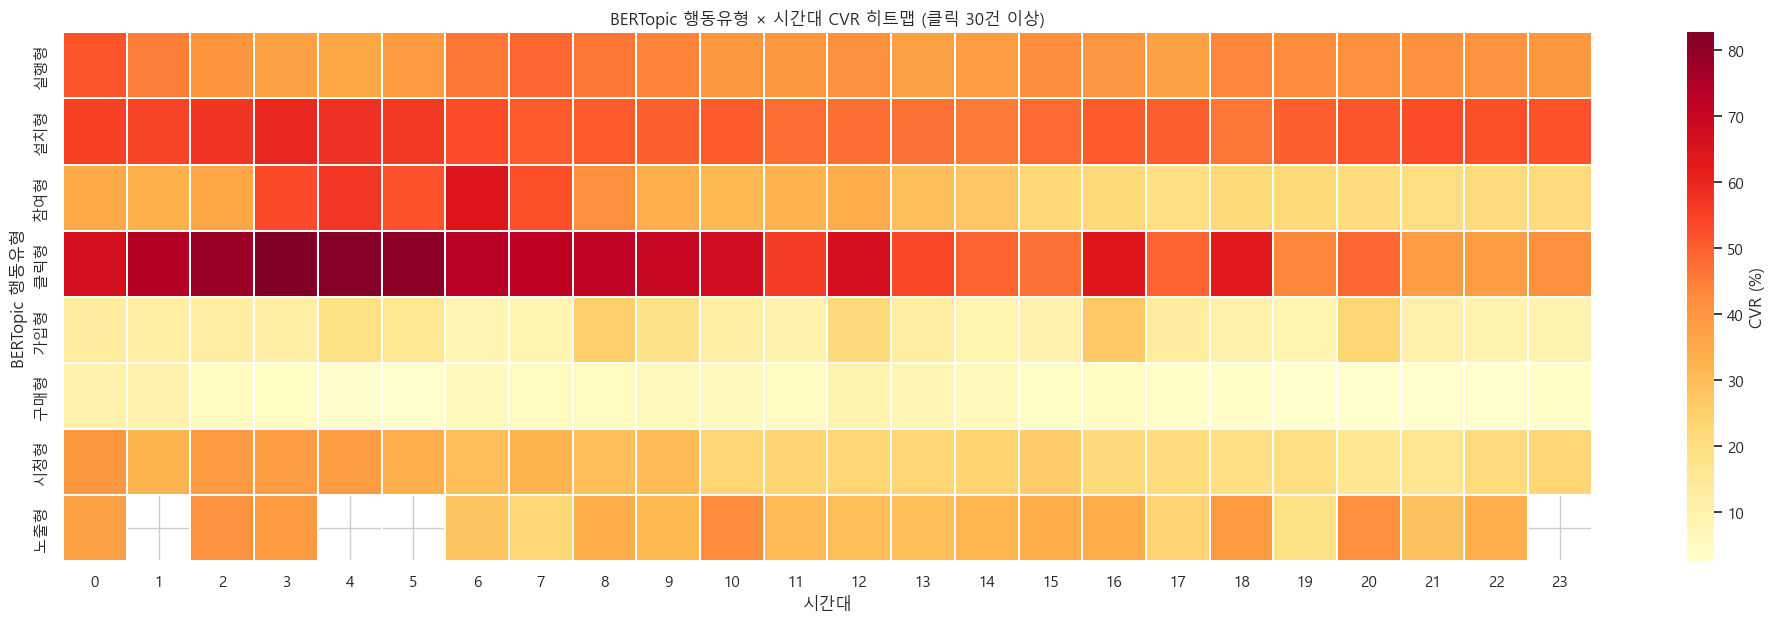

**BERTopic 행동유형별 CVR 상위 시간대 TOP5**

,BERTopic 행동유형,시간대,클릭수,완료수,CVR(%)
16,가입형,16,8709,2324,26.69
8,가입형,8,7002,1781,25.44
20,가입형,20,9151,2121,23.18
12,가입형,12,7456,1616,21.67
4,가입형,4,3861,734,19.01
25,구매형,1,4400,450,10.23
24,구매형,0,7235,711,9.83
36,구매형,12,5846,539,9.22
37,구매형,13,5951,482,8.10
38,구매형,14,6578,448,6.81


In [60]:
# BERTopic 행동유형 × 시간대 CVR 히트맵
# - 행동유형별 기본 성과 차이를 확인한 뒤, 시간대별 반응성 차이를 본다.

MIN_BERT_TYPE_HOUR_CLICKS = 30

bert_funnel = (
    main_funnel_work[["click_key", "ads_idx", "click_hour", "is_completed"]]
    .merge(bert_action_map[["ads_idx", BERT_ACTION_COL]], on="ads_idx", how="left")
    .dropna(subset=[BERT_ACTION_COL, "click_hour"])
    .copy()
)

bert_type_hour = (
    bert_funnel
    .groupby([BERT_ACTION_COL, "click_hour"])
    .agg(
        click_cnt=("click_key", "count"),
        complete_cnt=("is_completed", "sum"),
    )
    .reset_index()
)

bert_type_hour["cvr"] = safe_divide(
    bert_type_hour["complete_cnt"],
    bert_type_hour["click_cnt"],
    100,
)

bert_type_hour_plot = bert_type_hour[
    bert_type_hour["click_cnt"] >= MIN_BERT_TYPE_HOUR_CLICKS
].copy()

bert_type_hour_pivot = (
    bert_type_hour_plot
    .pivot(index=BERT_ACTION_COL, columns="click_hour", values="cvr")
    .reindex(bert_action_order)
)

plt.figure(figsize=(20, max(4, len(bert_type_hour_pivot) * 0.8)))
sns.heatmap(
    bert_type_hour_pivot,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "CVR (%)"},
)
plt.title(f"BERTopic 행동유형 × 시간대 CVR 히트맵 (클릭 {MIN_BERT_TYPE_HOUR_CLICKS}건 이상)")
plt.xlabel("시간대")
plt.ylabel("BERTopic 행동유형")
plt.tight_layout()
plt.show()

bert_type_hour_top5 = (
    bert_type_hour_plot
    .sort_values([BERT_ACTION_COL, "cvr", "click_cnt"], ascending=[True, False, False])
    .groupby(BERT_ACTION_COL)
    .head(5)
    .rename(
        columns={
            BERT_ACTION_COL: "BERTopic 행동유형",
            "click_hour": "시간대",
            "cvr": "CVR(%)",
            "click_cnt": "클릭수",
            "complete_cnt": "완료수",
        }
    )
)

show_table(
    "BERTopic 행동유형별 CVR 상위 시간대 TOP5",
    bert_type_hour_top5,
    n=60,
)

#### BERTopic 행동유형 × 시간대 해석
BERTopic 행동유형 기준 성과 요약을 보면 행동유형별 규모와 집계 CVR 차이가 뚜렷하다. 클릭형은 집계 CVR이 높고, 구매형·가입형은 집계 CVR이 낮아 같은 시간대 운영이라도 행동 난이도별로 분리해서 볼 필요가 있다.

시간대 히트맵에서는 클릭형은 새벽 시간대, 설치형은 0~5시, 실행형은 0시·7~8시, 참여형은 6시 전후에서 상대적으로 높은 CVR이 나타난다. 이는 기존 광고유형 기준 분석을 대체하기보다, 실제 행동유형별 시간대 조정 가능성을 보조하는 근거로 해석한다.

다만 노출형은 광고수와 클릭 규모가 작아 일부 시간대 CVR이 높게 보여도 일반화하기 어렵다. 또한 가입형은 광고별 중앙값 CVR과 집계 CVR이 다르게 보이므로, 전체 트래픽 규모와 광고별 분포를 구분해서 해석해야 한다.

---
## 4. 수익성 분석

광고 반응이 실제 마진으로 이어지는지 확인한다.

반응성이 높아도 수익성이 낮으면 운영 우선순위가 높다고 보기 어렵다.  
따라서 광고별 총마진, 클릭당 마진, 완료당 마진을 함께 보고, 수익이 특정 매체나 예외적인 비용 구조에 과도하게 의존하지 않는지도 확인한다.

현재 EDA에서는 마진 중심으로 수익성을 해석한다.

### 4-1. 광고별 마진 요약

In [61]:
# 광고별 마진 요약 테이블
# - finance_clean1의 ive_margin을 광고 단위로 집계해 이후 마진 분석에서 공통 사용한다.

finance_margin_work = finance_clean1.copy()
finance_margin_work["is_negative_margin"] = finance_margin_work["ive_margin"] < 0

ad_margin_summary = (
    finance_margin_work
    .groupby("ads_idx")
    .agg(
        reward_cnt=("ive_margin", "count"),
        total_margin=("ive_margin", "sum"),
        avg_margin=("ive_margin", "mean"),
        median_margin=("ive_margin", "median"),
        negative_margin_cnt=("is_negative_margin", "sum"),
    )
    .reset_index()
)

ad_margin_summary["margin_per_complete"] = safe_divide(
    ad_margin_summary["total_margin"],
    ad_margin_summary["reward_cnt"],
    1,
)

ad_margin_summary["negative_margin_pct"] = safe_divide(
    ad_margin_summary["negative_margin_cnt"],
    ad_margin_summary["reward_cnt"],
    100,
)


### #부록 수익성 분석: 광고유형별 완료당 마진 차이 보조 분석


In [62]:
# 광고유형별 완료당 마진 차이 — 전체 유형 기준 + 주요 유형 기준

ad_stat_df = ad_df.merge(
    ad_margin_summary[["ads_idx", "margin_per_complete"]],
    on="ads_idx",
    how="left",
)

margin_test_all = ad_stat_df.dropna(subset=[type_col, "margin_per_complete"]).copy()

type_counts_margin = (
    margin_test_all
    .groupby(type_col)
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

print("광고유형별 완료당 마진 검정 대상 수:")
display(type_counts_margin)


광고유형별 완료당 마진 검정 대상 수:


,analysis_ads_type_label,n
7,참여형,3334
8,퀘스트,78
2,설치형,52
3,실행형,34
0,CPS(물건구매),29
5,인스타,4
9,클릭형,3
1,네이버,2
4,유튜브,2
6,제휴,1


In [63]:
# 전체 유형 기준: 탐색용
groups_margin_all = [
    group["margin_per_complete"].values
    for _, group in margin_test_all.groupby(type_col)
]
groups_margin_all = [group for group in groups_margin_all if len(group) > 0]

if len(groups_margin_all) >= 2:
    kw_margin_all_stat, kw_margin_all_p = kruskal(*groups_margin_all)

    print(
        f"[전체 유형 기준: 광고유형 × 완료당 마진] "
        f"Kruskal-Wallis H={kw_margin_all_stat:.4f}, p={kw_margin_all_p:.6f}"
    )

    dunn_margin_all = posthoc_dunn(
        margin_test_all[[type_col, "margin_per_complete"]],
        val_col="margin_per_complete",
        group_col=type_col,
        p_adjust="bonferroni",
    )

    print("\nDunn's test 사후 비교 — 완료당 마진 전체 유형 기준(탐색용):")
    display(
        dunn_margin_all.style.background_gradient(
            cmap="RdYlGn_r",
            vmin=0,
            vmax=0.1,
        )
    )
else:
    print("검정 가능한 그룹 수 부족")

print(
    "주의: 전체 유형 기준 결과는 탐색용이다. "
    "광고 수가 5개 미만인 유형은 최종 해석에서 참고 수준으로만 본다."
)

[전체 유형 기준: 광고유형 × 완료당 마진] Kruskal-Wallis H=574.4745, p=0.000000

Dunn's test 사후 비교 — 완료당 마진 전체 유형 기준(탐색용):


,CPS(물건구매),네이버,설치형,실행형,유튜브,인스타,제휴,참여형,퀘스트,클릭형
CPS(물건구매),1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.793398
네이버,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000107,1.000000
설치형,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
실행형,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
유튜브,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000140,1.000000
인스타,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.074169,0.000000,1.000000
제휴,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.034372,1.000000
참여형,0.000000,1.000000,0.000000,0.000000,1.000000,0.074169,1.000000,1.000000,0.000000,1.000000
퀘스트,0.000000,0.000107,0.000000,0.000000,0.000140,0.000000,0.034372,0.000000,1.000000,0.012091
클릭형,0.793398,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.012091,1.000000


주의: 전체 유형 기준 결과는 탐색용이다. 광고 수가 5개 미만인 유형은 최종 해석에서 참고 수준으로만 본다.


In [64]:
# 주요 유형 기준: 최종 해석용
valid_types_margin = type_counts_margin.loc[
    type_counts_margin["n"] >= MIN_GROUP_N,
    type_col,
].tolist()

margin_test_main = margin_test_all[
    margin_test_all[type_col].isin(valid_types_margin)
].copy()

print("\n완료당 마진 검정 포함 광고유형(n>=5):")
display(type_counts_margin[type_counts_margin[type_col].isin(valid_types_margin)])

print("\n완료당 마진 검정 제외 광고유형(n<5):")
display(type_counts_margin[~type_counts_margin[type_col].isin(valid_types_margin)])

groups_margin_main = [
    group["margin_per_complete"].values
    for _, group in margin_test_main.groupby(type_col)
]
groups_margin_main = [group for group in groups_margin_main if len(group) > 0]

if len(groups_margin_main) >= 2:
    kw_margin_main_stat, kw_margin_main_p = kruskal(*groups_margin_main)

    print(
        f"\n[주요 유형 기준: 광고유형 × 완료당 마진] "
        f"Kruskal-Wallis H={kw_margin_main_stat:.4f}, p={kw_margin_main_p:.6f}"
    )

    if kw_margin_main_p < 0.05:
        print("→ 주요 유형 기준에서도 광고유형 간 완료당 마진 분포 차이가 통계적으로 유의하다.")
    else:
        print("→ 주요 유형 기준에서는 광고유형 간 완료당 마진 분포 차이가 통계적으로 유의하지 않다.")

    dunn_margin_main = posthoc_dunn(
        margin_test_main[[type_col, "margin_per_complete"]],
        val_col="margin_per_complete",
        group_col=type_col,
        p_adjust="bonferroni",
    )

    print("\nDunn's test 사후 비교 — 완료당 마진 주요 유형 기준(n>=5, 최종 해석용):")
    display(
        dunn_margin_main.style.background_gradient(
            cmap="RdYlGn_r",
            vmin=0,
            vmax=0.1,
        )
    )
else:
    print("검정 가능한 그룹 수 부족")



완료당 마진 검정 포함 광고유형(n>=5):


,analysis_ads_type_label,n
7,참여형,3334
8,퀘스트,78
2,설치형,52
3,실행형,34
0,CPS(물건구매),29



완료당 마진 검정 제외 광고유형(n<5):


,analysis_ads_type_label,n
5,인스타,4
9,클릭형,3
1,네이버,2
4,유튜브,2
6,제휴,1



[주요 유형 기준: 광고유형 × 완료당 마진] Kruskal-Wallis H=553.2486, p=0.000000
→ 주요 유형 기준에서도 광고유형 간 완료당 마진 분포 차이가 통계적으로 유의하다.

Dunn's test 사후 비교 — 완료당 마진 주요 유형 기준(n>=5, 최종 해석용):


,CPS(물건구매),설치형,실행형,참여형,퀘스트
CPS(물건구매),1.000000,1.000000,1.000000,0.000000,0.000000
설치형,1.000000,1.000000,1.000000,0.000000,0.000000
실행형,1.000000,1.000000,1.000000,0.000000,0.000000
참여형,0.000000,0.000000,0.000000,1.000000,0.000000
퀘스트,0.000000,0.000000,0.000000,0.000000,1.000000


In [65]:
# 주요 광고유형별 완료당 마진 차이 검정
# - 셀 80은 전체 유형 탐색용
# - 셀 81은 광고 수가 충분한 주요 유형(n>=5)만 사용

valid_types_margin = type_counts_margin.loc[
    type_counts_margin["n"] >= MIN_GROUP_N,
    type_col,
].tolist()

margin_test_main = margin_test_all[
    margin_test_all[type_col].isin(valid_types_margin)
].copy()

margin_groups = {
    label: group["margin_per_complete"].dropna().values
    for label, group in margin_test_main.groupby(type_col)
}

kw_margin_main_stat, kw_margin_main_p = kruskal(*margin_groups.values())

margin_group_n = len(margin_groups)
margin_obs_n = len(margin_test_main)

kw_margin_main_effect = max(
    0,
    (kw_margin_main_stat - margin_group_n + 1) / (margin_obs_n - margin_group_n),
)

margin_kw_result = pd.DataFrame([{
    "검정": "광고유형별 완료당 마진 차이",
    "검정방법": "Kruskal-Wallis",
    "그룹수": margin_group_n,
    "관측수": margin_obs_n,
    "H통계량": kw_margin_main_stat,
    "p값": kw_margin_main_p,
    "효과크기": kw_margin_main_effect,
}])

margin_group_summary = (
    margin_test_main
    .groupby(type_col)
    .agg(
        광고수=("ads_idx", "nunique"),
        관측수=("margin_per_complete", "count"),
        평균완료당마진=("margin_per_complete", "mean"),
        중앙값완료당마진=("margin_per_complete", "median"),
    )
    .reset_index()
    .sort_values("중앙값완료당마진", ascending=False)
)

show_table("광고유형별 완료당 마진 Kruskal-Wallis 검정 결과", margin_kw_result, n=5)
show_table("광고유형별 완료당 마진 요약", margin_group_summary, n=20)

**광고유형별 완료당 마진 Kruskal-Wallis 검정 결과**

,검정,검정방법,그룹수,관측수,H통계량,p값,효과크기
0,광고유형별 완료당 마진 차이,Kruskal-Wallis,5,3527,553.25,0.00,0.16


**광고유형별 완료당 마진 요약**

,analysis_ads_type_label,광고수,관측수,평균완료당마진,중앙값완료당마진
0,CPS(물건구매),29,29,"35,726.37","7,494.00"
1,설치형,52,52,66.20,51.12
2,실행형,34,34,50.07,50.03
3,참여형,3334,3334,76.68,4.00
4,퀘스트,78,78,-287.62,-277.50


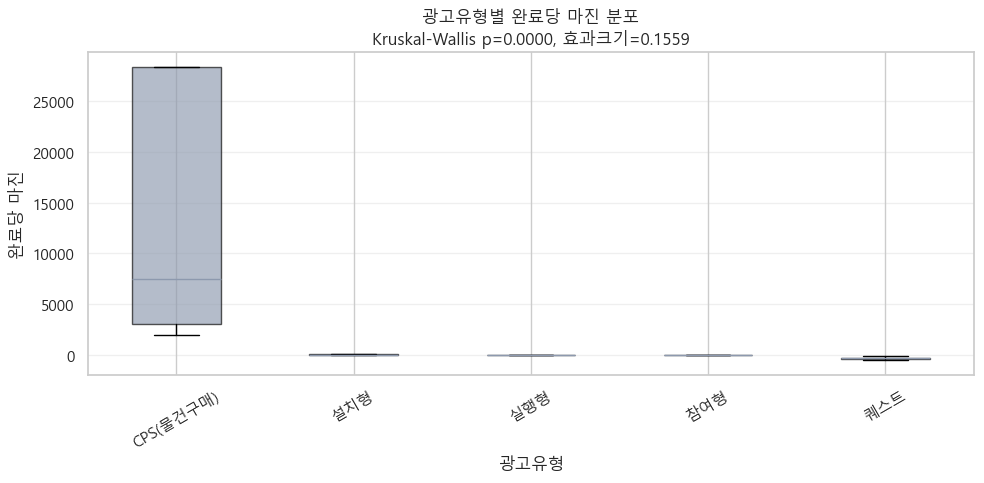

In [66]:
# 광고유형별 완료당 마진 분포 시각화

labels = list(margin_groups.keys())
box_data = [margin_groups[label] for label in labels]

plt.figure(figsize=(10, 5))

bp = plt.boxplot(
    box_data,
    labels=labels,
    patch_artist=True,
    showfliers=False,
)

colors = get_plot_colors(len(labels))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

plt.title(
    f"광고유형별 완료당 마진 분포\n"
    f"Kruskal-Wallis p={kw_margin_main_p:.4f}, 효과크기={kw_margin_main_effect:.4f}"
)
plt.xlabel("광고유형")
plt.ylabel("완료당 마진")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 4-2. 마진 규모와 매체 의존도

**분석 질문**: 어떤 광고가 실제 마진을 만들고 있으며, 그 마진이 특정 매체에 과도하게 의존하고 있는가?

**사용 지표**: 총마진, 클릭당 마진, 완료당 마진, 음수 마진 비율, 상위 매체 의존도

**핵심 해석**: 총마진이 높은 광고라도 특정 매체 하나에서 대부분의 마진이 발생한다면 운영 리스크가 있다. 따라서 수익성은 마진 규모뿐 아니라 매체 의존도까지 함께 해석해야 한다.

주의점 : 총마진 상위 광고는 전체 수익 기여도가 크지만, 특정 매체 의존도나 완료당 마진 구조를 함께 확인하기 전까지는 확대 후보로 확정할 수 없다.

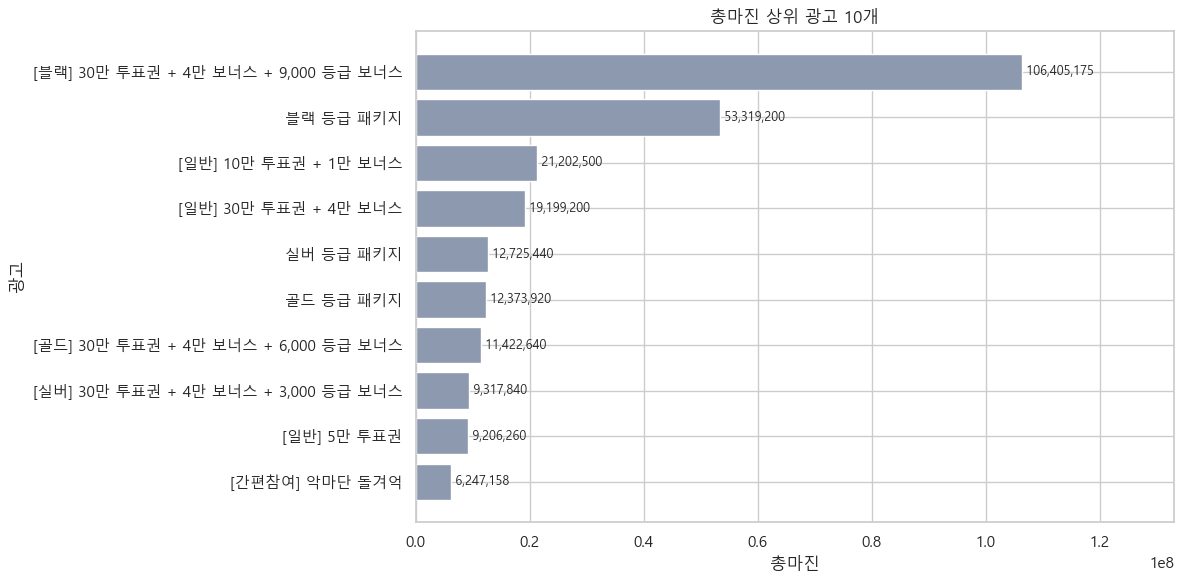

**광고별 마진 요약**

,ads_idx,reward_cnt,total_margin,avg_margin,median_margin,negative_margin_cnt,margin_per_complete,negative_margin_pct,ads_name,click_cnt,complete_cnt,cvr_pct
178,130275,1255,106405175,"84,785.00","84,785.00",0,"84,785.00",0.00,"[블랙] 30만 투표권 + 4만 보너스 + 9,000 등급 보너스","1,284.00","1,255.00",97.74
480,429487,220,53319200,"242,360.00","242,360.00",0,"242,360.00",0.00,블랙 등급 패키지,745.00,220.00,29.53
163,127906,771,21202500,"27,500.00","27,500.00",0,"27,500.00",0.00,[일반] 10만 투표권 + 1만 보너스,"1,208.00",771.00,63.82
165,127908,233,19199200,"82,400.00","82,400.00",0,"82,400.00",0.00,[일반] 30만 투표권 + 4만 보너스,843.00,233.00,27.64
478,429485,152,12725440,"83,720.00","83,720.00",0,"83,720.00",0.00,실버 등급 패키지,"1,282.00",152.00,11.86
479,429486,78,12373920,"158,640.00","158,640.00",0,"158,640.00",0.00,골드 등급 패키지,568.00,78.00,13.73
174,130270,136,11422640,"83,990.00","83,990.00",0,"83,990.00",0.00,"[골드] 30만 투표권 + 4만 보너스 + 6,000 등급 보너스",152.00,136.00,89.47
170,130266,112,9317840,"83,195.00","83,195.00",0,"83,195.00",0.00,"[실버] 30만 투표권 + 4만 보너스 + 3,000 등급 보너스",142.00,112.00,78.87
162,127899,665,9206260,"13,844.00","13,844.00",0,"13,844.00",0.00,[일반] 5만 투표권,"1,295.00",665.00,51.35
448,426570,44949,6247158,138.98,140.00,0,138.98,0.00,[간편참여] 악마단 돌겨억,"48,204.00","44,949.00",93.25


In [67]:
# 광고별 마진 시각화
# - 위에서 생성한 ad_margin_summary를 사용한다.

ad_margin_display = ad_margin_summary.merge(
    ad_df[["ads_idx", "ads_name", "click_cnt", "complete_cnt", "cvr_pct"]],
    on="ads_idx",
    how="left",
)

top_margin = (
    ad_margin_display
    .sort_values("total_margin", ascending=False)
    .head(10)
    .sort_values("total_margin", ascending=True)
)

bar_colors = get_plot_colors(len(top_margin))

plt.figure(figsize=(12, 6))
plt.barh(
    top_margin["ads_name"].fillna(top_margin["ads_idx"].astype(str)),
    top_margin["total_margin"],
    color=bar_colors,
)
plt.title("총마진 상위 광고 10개")
plt.xlabel("총마진")
plt.ylabel("광고")
label_barh(plt.gca(), top_margin["total_margin"])
plt.tight_layout()
plt.show()

show_table(
    "광고별 마진 요약",
    ad_margin_display.sort_values("total_margin", ascending=False),
    n=20,
)

In [68]:
# 광고별 클릭당 마진 요약
# - 클릭 수가 많은 광고가 실제 수익성도 좋은지 확인하기 위한 보조 지표다.

ad_profit_view = ad_margin_display.copy()

ad_profit_view["margin_per_click"] = safe_divide(
    ad_profit_view["total_margin"],
    ad_profit_view["click_cnt"],
    1,
)

ad_profit_view = ad_profit_view[ad_profit_view["click_cnt"] >= 1000].copy()

margin_per_click_summary = pd.DataFrame({
    "지표": [
        "광고 수",
        "평균",
        "중앙값",
        "25%",
        "75%",
        "90%",
        "95%",
        "99%",
        "최댓값",
    ],
    "값": [
        len(ad_profit_view),
        ad_profit_view["margin_per_click"].mean(),
        ad_profit_view["margin_per_click"].median(),
        ad_profit_view["margin_per_click"].quantile(0.25),
        ad_profit_view["margin_per_click"].quantile(0.75),
        ad_profit_view["margin_per_click"].quantile(0.90),
        ad_profit_view["margin_per_click"].quantile(0.95),
        ad_profit_view["margin_per_click"].quantile(0.99),
        ad_profit_view["margin_per_click"].max(),
    ],
})

show_table(
    "광고별 클릭당 마진 요약",
    margin_per_click_summary,
    n=20,
)

**광고별 클릭당 마진 요약**

,지표,값
0,광고 수,152.00
1,평균,814.60
2,중앙값,24.78
3,25%,7.09
4,75%,41.87
5,90%,121.98
6,95%,143.88
7,99%,"13,662.73"
8,최댓값,"82,870.07"


### 4-3. 보상구간별 마진

수익성 파트의 reward_band는 그 보상이 실제 마진으로 이어지는가를 확인하는 기준이다. 따라서 보상구간별 CVR과 보상구간별 마진을 함께 해석한다.


In [69]:
# reward_band margin summary
reward_margin_base = ad_margin_display.merge(
    ad_df[["ads_idx", "reward_band"]],
    on="ads_idx",
    how="left",
    validate="one_to_one",
)
reward_margin_summary = (
    reward_margin_base
    .groupby("reward_band")
    .agg(
        ads_cnt=("ads_idx", "nunique"),
        total_click_cnt=("click_cnt", "sum"),
        total_complete_cnt=("complete_cnt", "sum"),
        total_margin=("total_margin", "sum"),
        avg_margin=("avg_margin", "mean"),
        median_margin=("median_margin", "median"),
    )
    .reset_index()
)
reward_margin_summary["margin_per_click"] = safe_divide(reward_margin_summary["total_margin"], reward_margin_summary["total_click_cnt"], 1)
reward_margin_summary["margin_per_complete"] = safe_divide(reward_margin_summary["total_margin"], reward_margin_summary["total_complete_cnt"], 1)
reward_margin_summary["reward_band"] = pd.Categorical(reward_margin_summary["reward_band"], categories=band_order, ordered=True)
reward_margin_summary = reward_margin_summary.sort_values("reward_band")
reward_margin_summary_display = reward_margin_summary.rename(
    columns={
        "reward_band": "보상구간",
        "ads_cnt": "광고수",
        "total_click_cnt": "총클릭수",
        "total_complete_cnt": "총완료수",
        "total_margin": "총마진",
        "avg_margin": "평균마진",
        "median_margin": "중앙값마진",
        "margin_per_click": "클릭당마진",
        "margin_per_complete": "완료당마진",
    }
)
show_table("보상구간별 마진 요약", reward_margin_summary_display, n=10)


**보상구간별 마진 요약**

,보상구간,광고수,총클릭수,총완료수,총마진,평균마진,중앙값마진,클릭당마진,완료당마진
4,50원 미만,3145,"426,078.00","269,810.00",1059388,4.20,4.00,2.49,3.93
3,50~99원,7,"70,277.00","61,435.00",6037101,79.57,100.00,85.90,98.27
0,100~299원,139,"2,346,979.00","1,093,417.00",61720130,113.09,50.00,26.30,56.45
1,300~499원,54,"13,011.00","2,096.00",-337709,-221.26,-275.00,-25.96,-161.12
2,500원 이상,194,"343,754.00","21,612.00",272246855,"6,481.55",800.00,791.98,"12,597.02"


고보상 구간은 반응성은 낮지만, 완료가 발생했을 때 수익 기여도가 큰 광고군일 수 있다.
따라서 고보상 광고는 노출 확대보다 타겟·조건·매체 최적화 관점에서 봐야 한다.

### 4-4. CVR-수익성 사분면 요약

In [70]:
# CVR-수익성 사분면 요약
# - 최종 운영 후보 분류가 아니라, CVR과 수익성이 함께 움직이는지 확인하는 보조표다.
# - 기준: 클릭 1,000건 이상 광고의 CVR 중앙값, 완료당 마진 중앙값

cvr_profit_df = ad_margin_display[
    ["ads_idx", "click_cnt", "complete_cnt", "cvr_pct", "total_margin", "margin_per_complete"]
].dropna().copy()

cvr_profit_df = cvr_profit_df[cvr_profit_df["click_cnt"] >= 1000].copy()

cvr_profit_df["margin_per_click"] = safe_divide(
    cvr_profit_df["total_margin"],
    cvr_profit_df["click_cnt"],
    1,
)

cvr_cut = cvr_profit_df["cvr_pct"].median()
margin_cut = cvr_profit_df["margin_per_complete"].median()

cvr_profit_df["cvr_margin_group"] = np.where(
    cvr_profit_df["cvr_pct"] >= cvr_cut,
    "CVR↑",
    "CVR↓",
)

cvr_profit_df["cvr_margin_group"] = (
    cvr_profit_df["cvr_margin_group"]
    + "·"
    + np.where(
        cvr_profit_df["margin_per_complete"] >= margin_cut,
        "수익성↑",
        "수익성↓",
    )
)



In [71]:
cvr_margin_summary = (
    cvr_profit_df
    .groupby("cvr_margin_group")
    .agg(
        광고수=("ads_idx", "nunique"),
        총클릭수=("click_cnt", "sum"),
        총완료수=("complete_cnt", "sum"),
        중앙값완료당마진=("margin_per_complete", "median"),
        중앙값클릭당마진=("margin_per_click", "median"),
    )
    .reset_index()
)

cvr_margin_summary["집계CVR"] = safe_divide(
    cvr_margin_summary["총완료수"],
    cvr_margin_summary["총클릭수"],
    100,
)

cvr_margin_summary["클릭비중"] = safe_divide(
    cvr_margin_summary["총클릭수"],
    cvr_margin_summary["총클릭수"].sum(),
    100,
)

cvr_margin_summary["완료비중"] = safe_divide(
    cvr_margin_summary["총완료수"],
    cvr_margin_summary["총완료수"].sum(),
    100,
)

group_order = [
    "CVR↑·수익성↑",
    "CVR↑·수익성↓",
    "CVR↓·수익성↑",
    "CVR↓·수익성↓",
]

group_meaning = {
    "CVR↑·수익성↑": "전환도 좋고 완료당 마진도 높음",
    "CVR↑·수익성↓": "완료는 많이 만들지만 완료당 마진은 낮음",
    "CVR↓·수익성↑": "완료당 마진은 높지만 전환이 약함",
    "CVR↓·수익성↓": "전환과 완료당 마진 모두 낮음",
}

cvr_margin_summary["해석"] = cvr_margin_summary["cvr_margin_group"].map(group_meaning)

cvr_margin_summary["cvr_margin_group"] = pd.Categorical(
    cvr_margin_summary["cvr_margin_group"],
    categories=group_order,
    ordered=True,
)

cvr_margin_report = cvr_margin_summary.sort_values("cvr_margin_group")[
    [
        "cvr_margin_group",
        "해석",
        "광고수",
        "클릭비중",
        "완료비중",
        "집계CVR",
        "중앙값완료당마진",
        "중앙값클릭당마진",
    ]
]


In [72]:
show_table("CVR-수익성 사분면 요약", cvr_margin_report, n=10)

print(f"분석 대상: 클릭 1,000건 이상 광고 {len(cvr_profit_df):,}개")
print(f"CVR 기준값: {cvr_cut:.2f}%")
print(f"완료당 마진 기준값: {margin_cut:.2f}")


**CVR-수익성 사분면 요약**

,cvr_margin_group,해석,광고수,클릭비중,완료비중,집계CVR,중앙값완료당마진,중앙값클릭당마진
0,CVR↑·수익성↑,전환도 좋고 완료당 마진도 높음,22,9.12,18.52,87.86,135.06,109.58
1,CVR↑·수익성↓,완료는 많이 만들지만 완료당 마진은 낮음,54,62.15,74.77,52.07,44.52,25.47
2,CVR↓·수익성↑,완료당 마진은 높지만 전환이 약함,54,13.19,1.98,6.49,554.10,19.86
3,CVR↓·수익성↓,전환과 완료당 마진 모두 낮음,22,15.54,4.74,13.20,50.00,3.07


분석 대상: 클릭 1,000건 이상 광고 152개
CVR 기준값: 35.52%
완료당 마진 기준값: 70.01


- CVR과 수익성을 함께 보기 위해 클릭 1,000건 이상 광고를 대상으로 보조 사분면 요약을 구성했다.
- CVR의 높고 낮음은 분석 대상 광고의 CVR 중앙값을 기준으로 구분했다.
- 수익성의 높고 낮음은 분석 대상 광고의 완료당 마진 중앙값을 기준으로 구분했다.
- 이 표는 최종 운영 후보 분류가 아니라, CVR과 수익성이 서로 다르게 움직이는 광고군을 이해하기 위한 보조 해석표다.
- 실제 최종 운영 액션은 7장에서 클릭 규모, CVR 분위수, 완료당 마진 분위수, 총마진, 매체 의존 리스크를 함께 반영해 별도로 분류한다.

### 4-5. 광고별 상위 매체 의존도

In [73]:
# 광고별 상위 매체 의존도
# - finance_clean1의 ive_margin을 ads_idx × mda_idx 기준으로 집계한다.

media_margin = (
    finance_clean1
    .groupby(["ads_idx", "mda_idx"])
    .agg(media_margin=("ive_margin", "sum"))
    .reset_index()
)

media_total = (
    media_margin
    .groupby("ads_idx")
    .agg(total_media_margin=("media_margin", "sum"))
    .reset_index()
)

ad_top1_media = (
    media_margin
    .sort_values(["ads_idx", "media_margin"], ascending=[True, False])
    .drop_duplicates("ads_idx")
    .merge(media_total, on="ads_idx", how="left")
)

ad_top1_media["top1_media_share_pct"] = safe_divide(
    ad_top1_media["media_margin"],
    ad_top1_media["total_media_margin"],
    100,
)

ad_top1_media = ad_top1_media.rename(
    columns={
        "mda_idx": "top1_mda_idx",
        "media_margin": "top1_media_margin",
    }
)

media_risk_display = (
    ad_top1_media
    .merge(
        ad_df[["ads_idx", "ads_name", "click_cnt", "complete_cnt", "cvr_pct"]],
        on="ads_idx",
        how="inner",
    )
)
#이후에 광고별 상위 매체 의존도를 시각화할 때 이 media_risk_display를 사용한다.

media_risk_display = media_risk_display[
    (media_risk_display["click_cnt"] >= 1000) &
    (media_risk_display["total_media_margin"] >= 100000)
].copy()
#클릭 수가 충분히 많고, 매체 마진이 충분히 높은 광고를 대상으로 상위 매체 의존도를 분석해서, 주요 광고에서 상위 매체 의존도가 높은 경우를 확인한다.

media_risk_display = media_risk_display.sort_values(
    ["top1_media_share_pct", "total_media_margin"],
    ascending=[False, False],
)

media_risk_display_kr = (
    media_risk_display
    .rename(
        columns={
            "ads_idx": "광고ID",
            "ads_name": "광고명",
            "top1_mda_idx": "최대기여매체ID",
            "top1_media_margin": "최대기여매체마진",
            "total_media_margin": "광고총마진",
            "top1_media_share_pct": "최대기여매체비중(%)",
            "click_cnt": "클릭수",
            "complete_cnt": "완료수",
            "cvr_pct": "CVR(%)",
        }
    )
    [
        [
            "광고ID",
            "광고명",
            "최대기여매체ID",
            "최대기여매체마진",
            "광고총마진",
            "최대기여매체비중(%)",
            "클릭수",
            "완료수",
            "CVR(%)",
        ]
    ]
)

show_table(
    "광고별 최대 기여 매체 의존도(클릭 1000건 이상, 총마진 10만원 이상)",
    media_risk_display_kr,
    n=20,
)

**광고별 최대 기여 매체 의존도(클릭 1000건 이상, 총마진 10만원 이상)**

,광고ID,광고명,최대기여매체ID,최대기여매체마진,광고총마진,최대기여매체비중(%),클릭수,완료수,CVR(%)
125,130275,"[블랙] 30만 투표권 + 4만 보너스 + 9,000 등급 보너스",980,106405175,106405175,100.00,1284,1255,97.74
112,127906,[일반] 10만 투표권 + 1만 보너스,980,21202500,21202500,100.00,1208,771,63.82
302,429485,실버 등급 패키지,980,12725440,12725440,100.00,1282,152,11.86
111,127899,[일반] 5만 투표권,980,9206260,9206260,100.00,1295,665,51.35
113,127907,[일반] 1만 투표권,980,5425740,5425740,100.00,3679,1935,52.60
283,426215,우리동네GS,12,220350,241054,91.41,9745,4820,49.46
250,405610,LUDUS - Merge Arena PvP,14,206600,238600,86.59,1326,30,2.26
402,434988,GS25,12,238750,282550,84.50,17466,1114,6.38
1375,439216,돈버는 날씨서비스,496,270500,326312,82.90,17172,6496,37.83
265,413490,[원스토어] 용신 심판자,22,249130,326322,76.34,10404,4746,45.62


---
### #부록 수익성 리스크: 비용 구조 점검 대상이 성과 해석에 미치는 영향
- `has_finance_anomaly`: 해당 광고-일자에 일반 비용 구조와 다른 행이 포함되었는지 표시하는 플래그이다.
- 일부 광고-일자는 광고주 비용, 매체 지급 비용, 유저 리워드 비용의 관계가 일반적인 구조와 다르게 나타날 수 있다.
- 목적은 비용 구조 점검 대상이 포함될 때 CVR과 마진 해석이 흔들리는지 확인하는 것이다.
- 따라서 이 분석은 단순 반응성 비교가 아니라, 수익성 지표의 해석 신뢰도를 점검하는 단계다.

In [74]:
# 재무 이상 플래그별 CVR·수익성 지표 왜곡 확인
mart.group_by("has_finance_anomaly").agg([
    pl.col("click_cnt").mean().alias("avg_click"),
    pl.col("complete_cnt").mean().alias("avg_complete"),
    pl.col("daily_cvr").mean().alias("avg_cvr"),
    pl.len().alias("rows")
])


has_finance_anomaly,avg_click,avg_complete,avg_cvr,rows
bool,f64,f64,f64,u32
false,6.71107,2.930151,48.622801,470847
true,9.864353,1.861199,21.329439,2219


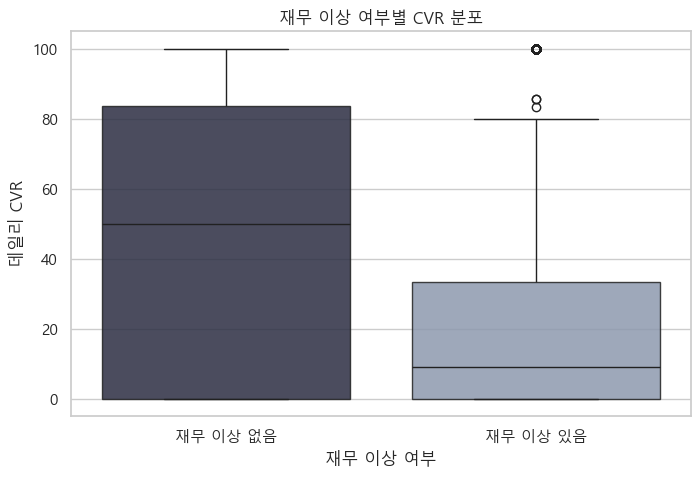

In [75]:
df = mart.select(["has_finance_anomaly", "daily_cvr"]).drop_nulls().to_pandas()

plt.figure(figsize=(8,5))
ax = sns.boxplot(data=df, x="has_finance_anomaly", y="daily_cvr")

apply_box_colors(ax)

ax.set_xlabel("재무 이상 여부")
ax.set_ylabel("데일리 CVR")

ax.set_xticklabels(["재무 이상 없음", "재무 이상 있음"])
plt.title("재무 이상 여부별 CVR 분포")
plt.show()


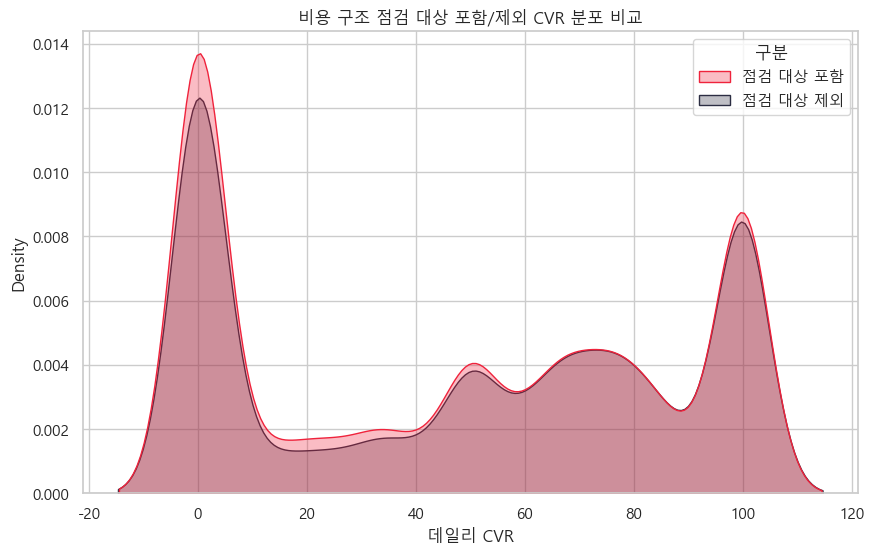

In [76]:
# 재무 이상 포함/제외 전후의 CVR 분포 비교

# 원본
df_raw = mart.select("daily_cvr").drop_nulls().to_pandas()
df_raw["구분"] = "점검 대상 포함"

# 제거 후
df_clean = mart.filter(pl.col("has_finance_anomaly") == False) \
               .select("daily_cvr").drop_nulls().to_pandas()
df_clean["구분"] = "점검 대상 제외"

df_all = pd.concat([df_raw, df_clean])

palette="#EF233C", "#2B2D42"

plt.figure(figsize=(10,6))
sns.kdeplot(data=df_all, x="daily_cvr", hue="구분", fill=True, alpha=0.3, palette=palette)

plt.title("비용 구조 점검 대상 포함/제외 CVR 분포 비교")
plt.xlabel("데일리 CVR")
plt.show()


In [77]:
# 재무 이상 포함/제외 전후의 평균과 중앙값 비교

# before
before = mart.select([
    pl.col("daily_cvr").mean().alias("mean"),
    pl.col("daily_cvr").median().alias("median")
])

# after
after = mart.filter(pl.col("has_finance_anomaly") == False).select([
    pl.col("daily_cvr").mean().alias("mean"),
    pl.col("daily_cvr").median().alias("median")
])

print("Before")
print(before)

print("After")
print(after)

Before
shape: (1, 2)
┌───────────┬────────┐
│ mean      ┆ median │
│ ---       ┆ ---    │
│ f64       ┆ f64    │
╞═══════════╪════════╡
│ 46.990559 ┆ 50.0   │
└───────────┴────────┘
After
shape: (1, 2)
┌───────────┬────────┐
│ mean      ┆ median │
│ ---       ┆ ---    │
│ f64       ┆ f64    │
╞═══════════╪════════╡
│ 48.622801 ┆ 50.0   │
└───────────┴────────┘


### #부록 재무 이상 포함/제외 영향 세분화
전체 CVR 분포만 비교하면 왜곡이 어느 축에서 발생하는지 보기 어렵다. 그래서 `reward_band`와 `observed_stage`별로 비용 구조 점검 대상 포함/제외 결과를 비교한다.

In [78]:
# reward_band 기준 재무 이상 포함/제외 CVR 비교

reward_order = [
    "미상",
    "50원 미만",
    "50~99원",
    "100~299원",
    "300~499원",
    "500원 이상",
]

reward_cvr_raw = (
    mart
    .group_by("reward_band")
    .agg([
        pl.col("daily_cvr").mean().alias("avg_cvr"),
        pl.col("daily_cvr").median().alias("median_cvr"),
        pl.len().alias("rows"),
        pl.col("ads_idx").n_unique().alias("ads_cnt"),
    ])
    .with_columns(pl.lit("raw_이상포함").alias("data_scope"))
)

reward_cvr_clean = (
    mart
    .filter(pl.col("has_finance_anomaly") == False)
    .group_by("reward_band")
    .agg([
        pl.col("daily_cvr").mean().alias("avg_cvr"),
        pl.col("daily_cvr").median().alias("median_cvr"),
        pl.len().alias("rows"),
        pl.col("ads_idx").n_unique().alias("ads_cnt"),
    ])
    .with_columns(pl.lit("clean_이상제외").alias("data_scope"))
)

reward_cvr_compare = pl.concat([reward_cvr_raw, reward_cvr_clean]).to_pandas()
reward_cvr_compare["reward_band"] = pd.Categorical(
    reward_cvr_compare["reward_band"],
    categories=reward_order,
    ordered=True,
)

reward_cvr_compare = reward_cvr_compare.sort_values(["reward_band", "data_scope"])
reward_cvr_compare

,reward_band,avg_cvr,median_cvr,rows,ads_cnt,data_scope
6,50원 미만,63.70,70.37,438846,422066,clean_이상제외
3,50원 미만,63.69,70.37,438853,422067,raw_이상포함
8,50~99원,51.40,50.00,6565,6495,clean_이상제외
0,50~99원,48.84,50.00,6573,6496,raw_이상포함
5,100~299원,42.57,39.37,9795,8492,clean_이상제외
1,100~299원,37.81,33.33,10343,8524,raw_이상포함
9,300~499원,7.46,0.00,874,636,clean_이상제외
4,300~499원,18.83,6.56,2121,691,raw_이상포함
7,500원 이상,5.78,0.00,14767,7462,clean_이상제외
2,500원 이상,6.26,0.00,15176,7482,raw_이상포함


In [79]:
# observed_stage 기준 재무 이상 포함/제외 CVR 비교

stage_order = [
    "01_초기(1~4일)",
    "02_유지(5일+)",
]

stage_cvr_raw = (
    mart
    .group_by("observed_stage")
    .agg([
        pl.col("daily_cvr").mean().alias("avg_cvr"),
        pl.col("daily_cvr").median().alias("median_cvr"),
        pl.len().alias("rows"),
        pl.col("ads_idx").n_unique().alias("ads_cnt"),
    ])
    .with_columns(pl.lit("raw_이상포함").alias("data_scope"))
)

stage_cvr_clean = (
    mart
    .filter(pl.col("has_finance_anomaly") == False)
    .group_by("observed_stage")
    .agg([
        pl.col("daily_cvr").mean().alias("avg_cvr"),
        pl.col("daily_cvr").median().alias("median_cvr"),
        pl.len().alias("rows"),
        pl.col("ads_idx").n_unique().alias("ads_cnt"),
    ])
    .with_columns(pl.lit("clean_이상제외").alias("data_scope"))
)

stage_cvr_compare = pl.concat([stage_cvr_raw, stage_cvr_clean]).to_pandas()
stage_cvr_compare["observed_stage"] = pd.Categorical(
    stage_cvr_compare["observed_stage"],
    categories=stage_order,
    ordered=True,
)

stage_cvr_compare = stage_cvr_compare.sort_values(["observed_stage", "data_scope"])
stage_cvr_compare

,observed_stage,avg_cvr,median_cvr,rows,ads_cnt,data_scope
3,01_초기(1~4일),58.02,66.67,19754,9408,clean_이상제외
1,01_초기(1~4일),57.59,66.67,20083,9517,raw_이상포함
2,02_유지(5일+),36.82,19.51,451093,439109,clean_이상제외
0,02_유지(5일+),34.93,16.67,452983,439217,raw_이상포함


비용 구조 점검 대상을 제외해도 전체 CVR 분포가 크게 달라지지는 않았다.  
다만 점검 대상 행은 평균 CVR이 낮고, 낮은 CVR 구간의 분포에 영향을 줄 수 있다.

따라서 수익성 분석에서는 전체 관측 마진과 점검 대상 제외 마진을 구분해서 해석하고, 해당 플래그가 있는 광고는 운영 판단 시 주의해서 본다.

---

## 5. 안정성 분석

광고 성과가 일시적 반응인지, 충분한 관측 기간 동안 유지되는지 확인한다.

관측일 수가 짧거나 클릭 수가 부족한 광고에는 안정성 점수를 강제로 부여하지 않고, 충분히 관측된 광고에 대해서만 신뢰도 조건을 붙여 해석한다.


### 5-1. observed_n_day와 초기 반응 감소

`observed_n_day` 분석은 광고의 지속가능성을 보는 안정성 분석으로 해석한다.


In [80]:
# observed_n_day별 평균 반응성 곡선 생성
# click_cnt > 0인 행과 유효한 observed_n_day만 남김

observed_mart = (
    mart
    .filter(
        (pl.col("click_cnt") > 0) &
        (pl.col("observed_n_day").is_not_null()) &
        (pl.col("observed_n_day") > 0)
    )
)

observed_curve = (
    observed_mart
    .group_by("observed_n_day")
    .agg([
        pl.col("click_cnt").mean().alias("avg_click_cnt"),
        pl.col("click_cnt").median().alias("median_click_cnt"),
        pl.col("complete_cnt").mean().alias("avg_complete_cnt"),
        pl.col("complete_cnt").median().alias("median_complete_cnt"),
        pl.col("daily_cvr").mean().alias("avg_cvr"),
        pl.col("daily_cvr").median().alias("median_cvr"),
        pl.len().alias("rows")
    ])
    .sort("observed_n_day")
)

# 안정적으로 보기 위해 표본수 기준 적용
observed_curve1 = (
    observed_curve
    .filter(pl.col("rows") >= MIN_AD_CLICKS)
    .to_pandas()
)

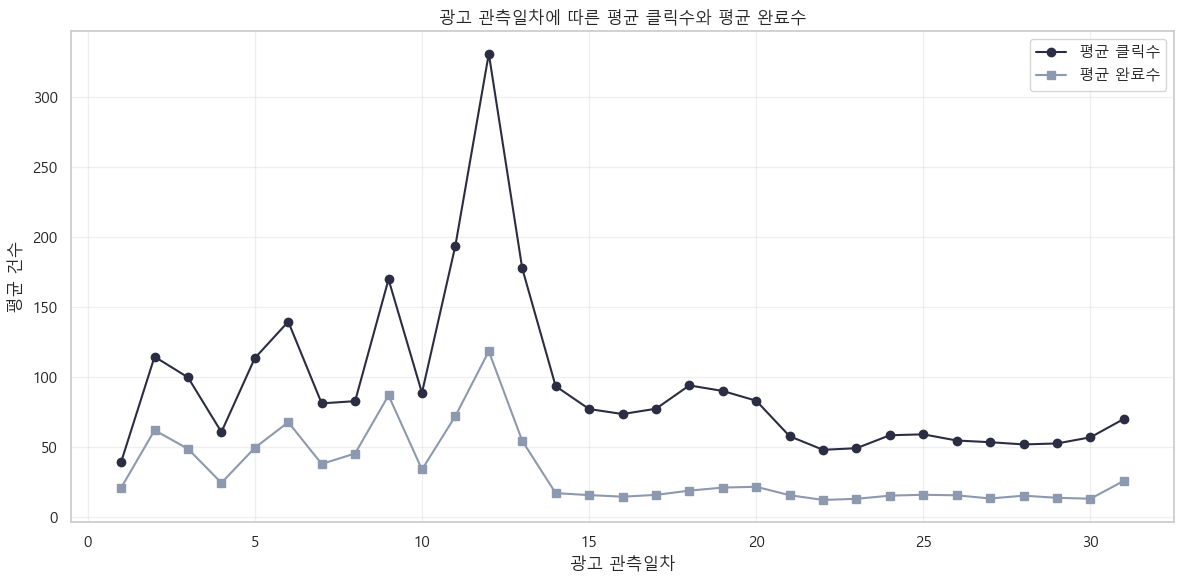

In [81]:
# 평균으로 확인
plt.figure(figsize=(12, 6))

plt.plot(
    observed_curve1["observed_n_day"],
    observed_curve1["avg_click_cnt"],
    marker="o",
    label="평균 클릭수"
)

plt.plot(
    observed_curve1["observed_n_day"],
    observed_curve1["avg_complete_cnt"],
    marker="s",
    label="평균 완료수"
)

plt.title("광고 관측일차에 따른 평균 클릭수와 평균 완료수")
plt.xlabel("광고 관측일차")
plt.ylabel("평균 건수")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

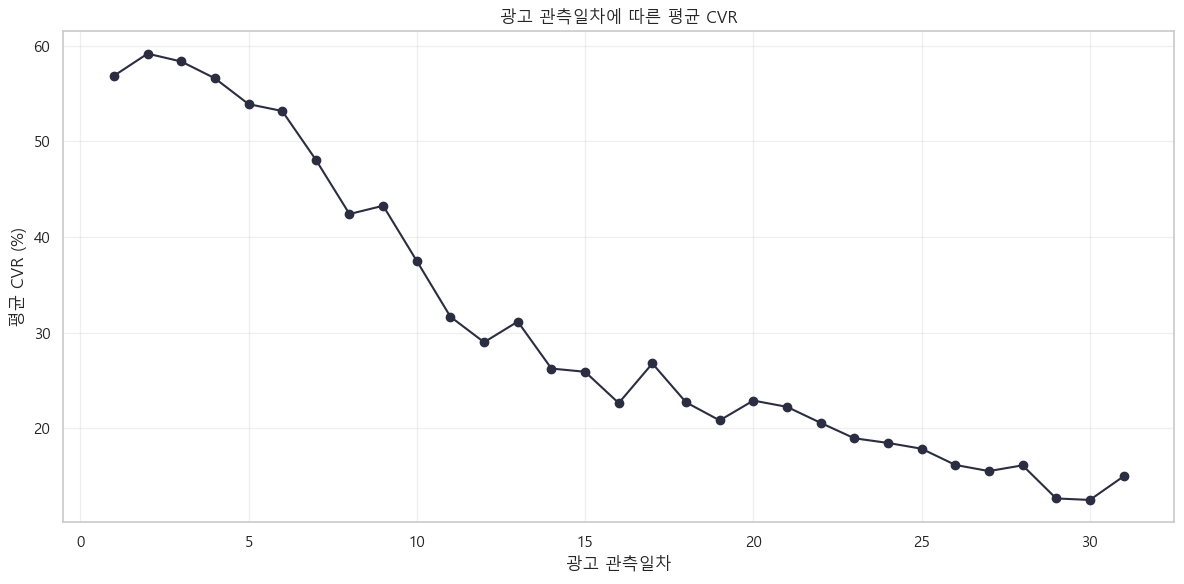

In [82]:
# 평균으로 확인
plt.figure(figsize=(12, 6))

plt.plot(
    observed_curve1["observed_n_day"],
    observed_curve1["avg_cvr"],
    marker="o"
)

plt.title("광고 관측일차에 따른 평균 CVR")
plt.xlabel("광고 관측일차")
plt.ylabel("평균 CVR (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

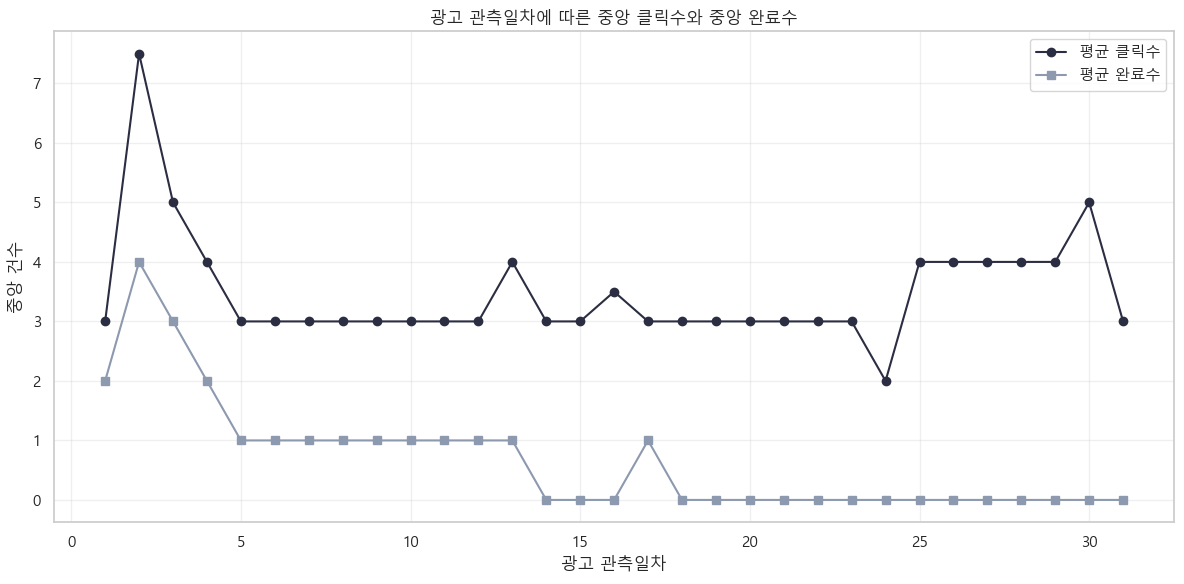

In [83]:
# 중앙값으로 확인
plt.figure(figsize=(12, 6))

plt.plot(
    observed_curve1["observed_n_day"],
    observed_curve1["median_click_cnt"],
    marker="o",
    label="평균 클릭수"
)

plt.plot(
    observed_curve1["observed_n_day"],
    observed_curve1["median_complete_cnt"],
    marker="s",
    label="평균 완료수"
)

plt.title("광고 관측일차에 따른 중앙 클릭수와 중앙 완료수")
plt.xlabel("광고 관측일차")
plt.ylabel("중앙 건수")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

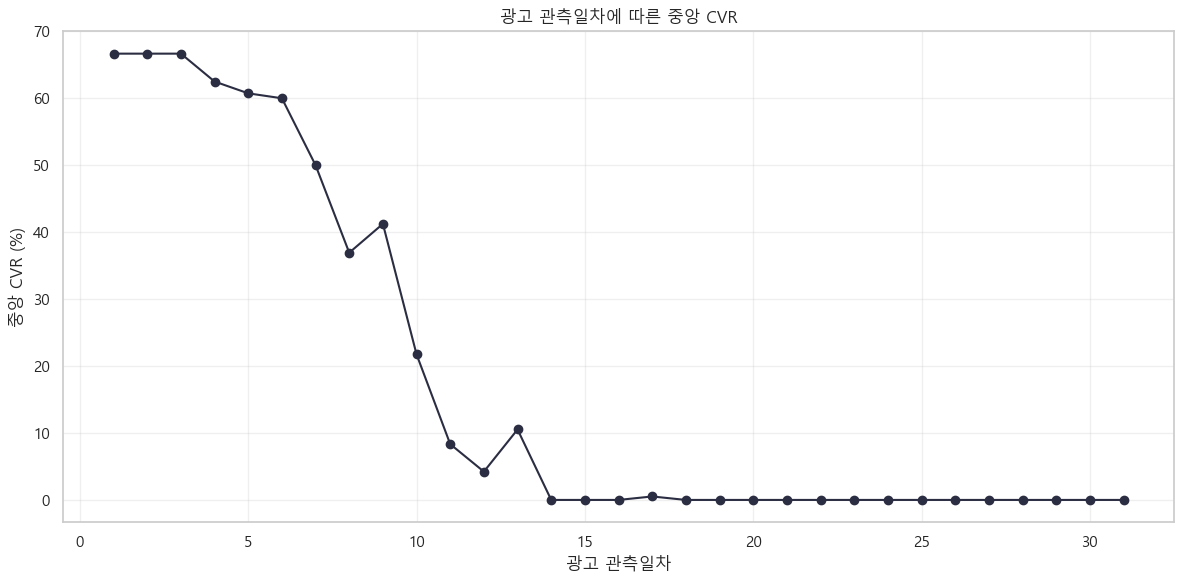

In [84]:
# 중앙값으로 확인
plt.figure(figsize=(12, 6))

plt.plot(
    observed_curve1["observed_n_day"],
    observed_curve1["median_cvr"],
    marker="o"
)

plt.title("광고 관측일차에 따른 중앙 CVR")
plt.xlabel("광고 관측일차")
plt.ylabel("중앙 CVR (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 캠페인 운영일차 곡선 해석

#### 평균
- 초반 관측일(1~12일차) 성과가 매우 높다.
    - 신규 광고 부스팅 효과
    - 혹은 살아남은 광고만 남는 생존 편향 가능성
- 12일차 피크가 유독 큰 이유
    - 현재 그래프는 **평균** 기반이라 일부 초대형 광고에 민감할 수 있다.
- 14일차 이후 클릭수, 완료수 급감하고 이후 낮은 수준에서 평탄화된다.


#### 중앙값
- 초반(1~4일차) 클릭&완료 중앙값이 높다.
- 그러나 5일차 이후 중앙 클릭수 3을 유지하며 거의 평평하게 유지되다가
- 14일차부터는 완료수가 거의 0에 수렴하여 절반 이상의 광고가 완료를 만들지 못하게 된다.

#### 종합
- 일부 대형 광고의 규모가 감소하면서 평균은 크게 감소하지만
- 일반 광고들은 소규모 반응을 꾸준히 유지하다가
- 14일차부터 반응이 거의 죽게 된다.
- 즉, 광고가 지속됨에 따라 유저가 피로를 보이는 패턴이다.

### 5-2. 생존 여부와 클릭당 마진 구간별 생존율

생존광고(alive_ads) : 5일 이후 구간에서 daily_cvr > 0이 한 번이라도 있는 광고

이 분석은 안정성 판단을 보조하는 세부 결과로 사용한다.


In [85]:
# 광고 단위 생존 여부
alive_ads = (
    mart
    .group_by("ads_idx")
    .agg([
        (
            (pl.col("observed_stage") == "02_유지(5일+)") &
            (pl.col("daily_cvr") > 0)
        )
        .any()
        .alias("is_alive")
    ])
)

# ads_eval에 붙이기
ads_eval = ads_eval.join(
    alive_ads,
    on="ads_idx",
    how="left"
)



In [86]:
ads_eval.group_by("is_alive").agg([
    pl.col("total_cvr").mean().alias("avg_cvr"),
    pl.col("total_valid_margin_per_click").mean().alias("avg_margin_pc"),
    pl.col("total_click_cnt").mean().alias("avg_click"),
    pl.col("delta_stage_cvr").mean().alias("avg_delta_cvr"),
])

is_alive,avg_cvr,avg_margin_pc,avg_click,avg_delta_cvr
bool,f64,f64,f64,f64
false,56.886268,18.937367,1.061557,1.766093
true,58.849934,449.702773,1007.416419,19.460884


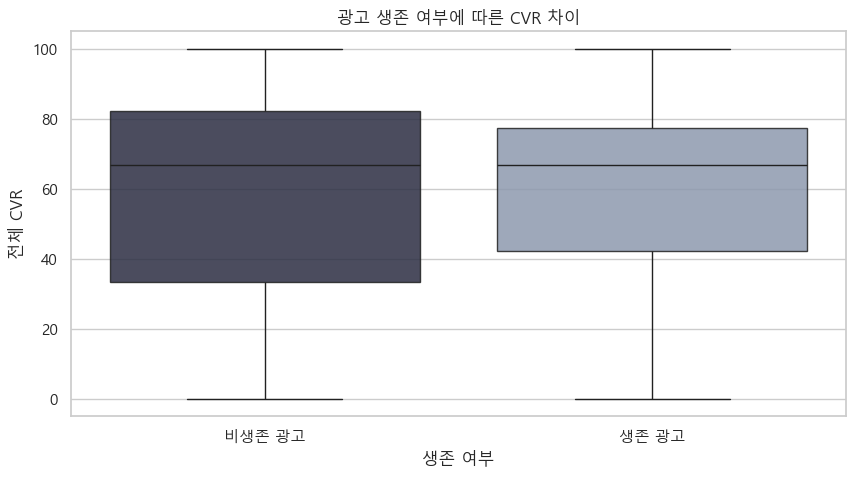

In [87]:
# 분포 비교

plt.figure(figsize=(10,5))
ax = sns.boxplot(data=ads_eval.to_pandas(), x="is_alive", y="total_cvr")

apply_box_colors(ax)

ax.set_xlabel("생존 여부")
ax.set_ylabel("전체 CVR")

ax.set_xticklabels(["비생존 광고", "생존 광고"])
plt.title("광고 생존 여부에 따른 CVR 차이")
plt.show()

In [88]:
# 생존 확률 곡선 클릭수 기준
click_order = ["~50", "50~100", "100~300", "300~1k", "1k~5k", "5k+"]
click_order_map = {value: idx for idx, value in enumerate(click_order)}

click_survival = (
    ads_eval
    .with_columns([
        pl.col("total_click_cnt").cut(
            [50, 100, 300, 1000, 5000],
            labels=click_order,
        ).alias("click_bin")
    ])
    .group_by("click_bin")
    .agg([
        pl.col("is_alive").mean().alias("survival_rate"),
        pl.len().alias("cnt"),
    ])
    .with_columns([
        pl.col("click_bin")
        .cast(pl.String)
        .replace_strict(
            click_order_map,
            default=pl.lit(999),
            return_dtype=pl.Int64,
        )
        .alias("order")
    ])
    .sort("order")
    .drop("order")
    .to_pandas()
)

click_survival


,click_bin,survival_rate,cnt
0,~50,0.00,442671
1,50~100,0.40,1069
2,100~300,0.33,1113
3,300~1k,0.58,255
4,1k~5k,0.88,82
5,5k+,0.81,70


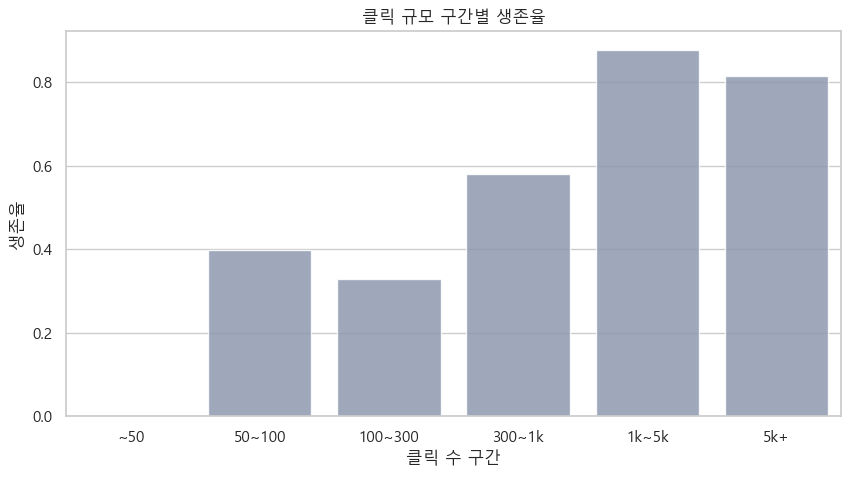

In [89]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=click_survival, x="click_bin", y="survival_rate")

apply_box_colors(ax)

plt.title("클릭 규모 구간별 생존율")
plt.xlabel("클릭 수 구간")
plt.ylabel("생존율")
plt.xticks(rotation=0)
plt.show()

In [90]:
# 생존 확률 곡선: 클릭당 정상 마진 기준
margin_order = [
    "0 이하",
    "0~10",
    "10~50",
    "50~100",
    "100~300",
    "300~1k",
    "1k+",
]

margin_order_map = {value: idx for idx, value in enumerate(margin_order)}

margin_survival = (
    ads_eval
    .with_columns([
        pl.col("total_valid_margin_per_click").cut(
            [0, 10, 50, 100, 300, 1000],
            labels=margin_order,
        ).alias("margin_pc_bin")
    ])
    .group_by("margin_pc_bin")
    .agg([
        pl.col("is_alive").mean().alias("survival_rate"),
        pl.len().alias("cnt"),
        pl.col("total_valid_margin_per_click").median().alias("median_margin_pc"),
    ])
    .with_columns([
        pl.col("margin_pc_bin")
        .cast(pl.String)
        .replace_strict(
            margin_order_map,
            default=pl.lit(999),
            return_dtype=pl.Int64,
        )
        .alias("order")
    ])
    .sort("order")
    .drop("order")
    .to_pandas()
)

margin_survival


,margin_pc_bin,survival_rate,cnt,median_margin_pc
0,0 이하,0.09,1247,0.00
1,0~10,0.28,7757,3.01
2,10~50,0.79,329,17.60
3,50~100,0.75,51,69.24
4,100~300,0.64,73,155.53
5,300~1k,0.59,27,457.56
6,1k+,0.76,33,"6,454.67"
7,NaN,0.00,435743,NaN


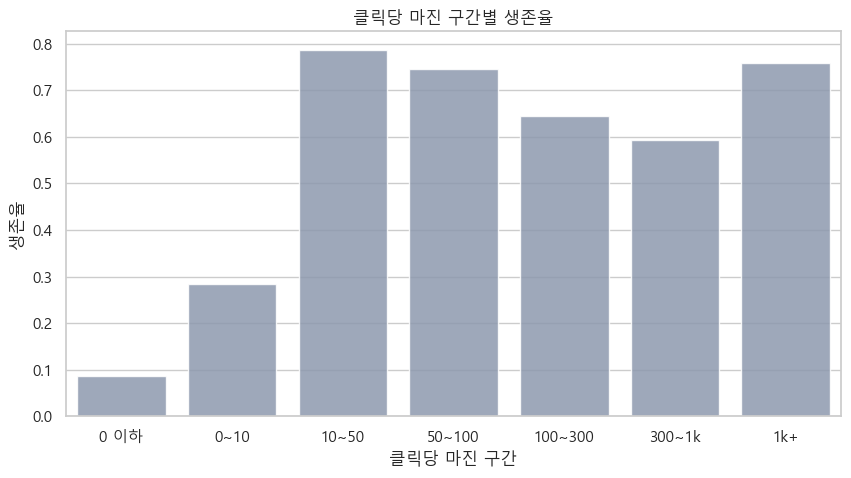

In [91]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=margin_survival, x="margin_pc_bin", y="survival_rate")

apply_box_colors(ax)

plt.title("클릭당 마진 구간별 생존율")
plt.xlabel("클릭당 마진 구간")
plt.ylabel("생존율")
plt.xticks(rotation=0)
plt.show()

#### 생존 광고의 특징
- 생존 광고는 평균 클릭수가 매우 높아 규모가 큰 편이다.
    - 생존 광고: 평균 1,296
    - 비생존 광고: 평균 3
- 클릭당 마진 평균도 생존 광고에서 더 높아 수익성이 상대적으로 좋다.
    - 생존 광고: 평균 909
    - 비생존 광고: 평균 17
- 관측구간 간 변화량은 생존 광고에서 더 크게 나타난다.
    - 생존 광고: 17
    - 비생존 광고: 0.8
- 300~499원 구간에서 생존 비율이 상대적으로 높다(9.3%).
- 퀘스트형 광고에서 생존 비율이 상대적으로 높다(19%).


- 광고는 클릭수 300을 넘기기 전까지 대부분 생존하지 못한다.
- 클릭수 1,000 이상부터 생존 확률이 급격히 상승한다.
- 광고 생존에는 일정 수준 이상의 임계 트래픽이 존재한다.

- 클릭당 마진 50 이하 광고는 장기 생존이 어렵다.
- 50~100 구간부터 생존 확률이 급격히 증가한다.
- 100 이상에서는 안정적인 생존 구조를 보인다.

- 높은 CVR은 광고 생존을 보장하지 않는다.
- 오히려 중간 수준의 CVR(20~40%)에서 생존율이 가장 높다.
- 이는 저노출 광고에서 CVR이 과대평가되는 구조 때문으로 해석된다.

#### 안정성 기준 활용
> 이 생존율 분석은 후속 점수화 모델에서 임계 트래픽과 클릭당 마진 기준을 설정할 때 후보 변수로 활용할 수 있다.


##### 안정성 세부 진단 기준

> 안정성 축에서는 광고 성과가 일시적 현상이 아니라 관측 기간 동안 유지되는지 확인한다.

1. 관측 지속성
2. 성과 변동성
3. 성과 지속 패턴
4. 실패 안정성
5. 데이터 신뢰도


---
### 5-4. 관측 지속성 확인
- 광고가 얼마나 오래 관측되었는지
- 단발성 광고와 지속 운영된 광고 구분
#### 5-4-1. 광고별 관측 지속성 테이블 만들기
- 기준 데이터: mart (광고 x 날짜 단위)

In [92]:
# 광고별 관측 지속성 테이블

ads_persistence = (
    mart
    .group_by("ads_idx")
    .agg([
        # 광고가 처음 관측된 날짜
        pl.col("click_day").min().alias("first_day"),

        # 광고가 마지막으로 관측된 날짜
        pl.col("click_day").max().alias("last_day"),

        # 실제로 데이터에 등장한 날짜 수
        pl.col("click_day").n_unique().alias("active_days"),

        # 광고별 전체 클릭 수
        pl.col("click_cnt").sum().alias("total_click_cnt"),

        # 광고별 전체 완료 수
        pl.col("complete_cnt").sum().alias("total_complete_cnt"),

        # 광고별 일평균 클릭 수
        # 꾸준히 관측됐더라도 하루 평균 클릭이 너무 낮으면 신뢰도가 낮을 수 있음
        pl.col("click_cnt").mean().alias("avg_daily_click_cnt"),

        # 광고별 일평균 CVR
        pl.col("daily_cvr").mean().alias("avg_daily_cvr"),
    ])
    .with_columns([
        # first_day부터 last_day까지의 전체 기간
        (
            (pl.col("last_day") - pl.col("first_day")).dt.total_days() + 1
        ).alias("observed_period_days")
    ])
    .with_columns([
        # 관측 기간 중 실제로 등장한 날짜 비율
        (
            pl.col("active_days") / pl.col("observed_period_days")
        ).alias("active_day_ratio"),

        # 광고 전체 기준 CVR
        # 전체 완료 수 / 전체 클릭 수로 계산한다.
        pl.when(pl.col("total_click_cnt") > 0)
        .then(pl.col("total_complete_cnt") / pl.col("total_click_cnt") * 100)
        .otherwise(None)
        .alias("total_cvr")
    ])
)

ads_persistence.head()

ads_idx,first_day,last_day,active_days,total_click_cnt,total_complete_cnt,avg_daily_click_cnt,avg_daily_cvr,observed_period_days,active_day_ratio,total_cvr
str,date,date,u32,u32,i64,f64,f64,i64,f64,f64
"""179674""",null,null,1,0,0,0.0,null,null,null,null
"""93999""",null,null,1,0,0,0.0,null,null,null,null
"""133418""",null,null,1,0,0,0.0,null,null,null,null
"""407634""",null,null,1,0,0,0.0,null,null,null,null
"""188832""",null,null,1,0,0,0.0,null,null,null,null


In [93]:
# 2단계: 관측 지속성 요약 확인
## 광고들의 관측일 수가 전반적으로 긴지 짧은지
## 안정성 평가 기준을 정하기 전에 분포를 먼저 확인

ads_persistence.select([
    # 전체 광고 수
    pl.len().alias("ads_cnt"),

    # 실제 등장 날짜 수 요약
    pl.col("active_days").mean().alias("avg_active_days"),
    pl.col("active_days").quantile(0.25).alias("q1_active_days"),
    pl.col("active_days").median().alias("median_active_days"),
    pl.col("active_days").quantile(0.75).alias("q3_active_days"),
    pl.col("active_days").max().alias("max_active_days"),

    # 관측 기간 대비 실제 등장 비율 요약
    pl.col("active_day_ratio").mean().alias("avg_active_day_ratio"),
    pl.col("active_day_ratio").median().alias("median_active_day_ratio"),

    # 클릭 수 요약
    pl.col("total_click_cnt").median().alias("median_total_click_cnt"),
    pl.col("total_click_cnt").max().alias("max_total_click_cnt"),
])

ads_cnt,avg_active_days,q1_active_days,median_active_days,q3_active_days,max_active_days,avg_active_day_ratio,median_active_day_ratio,median_total_click_cnt,max_total_click_cnt
u32,f64,f64,f64,f64,u32,f64,f64,f64,u32
445260,1.062449,1.0,1.0,1.0,31,0.853135,1.0,0.0,205304


In [94]:
# 3단계: active_days 구간별 광고 수 확인
## 광고들이 며칠 정도 관측되는지 구간화

day_bin_order = {
    "초기 (1~4일)": 1,
    "단기 유지 (5~14일)": 2,
    "장기 유지 (15일+)": 3,
}

ads_persistence_day_bin = (
    ads_persistence
    .with_columns([
        # active_days 구간화
        pl.when(pl.col("active_days") <= 4)
        .then(pl.lit("초기 (1~4일)"))
        .when(pl.col("active_days") <= 14)
        .then(pl.lit("단기 유지 (5~14일)"))
        .otherwise(pl.lit("장기 유지 (15일+)"))
        .alias("active_days_bin")
    ])
    .group_by("active_days_bin")
    .agg([
        # 구간별 광고 수
        pl.len().alias("ads_cnt"),
        # 구간별 전체 클릭 수 중앙값
        pl.col("total_click_cnt").median().alias("median_click_cnt"),
        # 구간별 전체 CVR 중앙값
        pl.col("total_cvr").median().alias("median_total_cvr"),
        # 구간별 active_day_ratio 중앙값
        pl.col("active_day_ratio").median().alias("median_active_day_ratio"),
    ])
    .with_columns([
        # 전체 광고 중 해당 구간이 차지하는 비율
        (pl.col("ads_cnt") / pl.col("ads_cnt").sum() * 100).alias("ads_ratio"),
        pl.col("active_days_bin")
        .replace_strict(
            day_bin_order,
            default=pl.lit(999),
            return_dtype=pl.Int64,
        )
        .alias("order"),
    ])
    .sort("order")
    .drop("order")
)

ads_persistence_day_bin


active_days_bin,ads_cnt,median_click_cnt,median_total_cvr,median_active_day_ratio,ads_ratio
str,u32,f64,f64,f64,f64
"""초기 (1~4일)""",443026,0.0,67.924528,1.0,99.498271
"""단기 유지 (5~14일)""",1792,35.0,62.455674,0.833333,0.402461
"""장기 유지 (15일+)""",442,121.0,10.676292,0.888889,0.099268


In [95]:
# 안정성 분석 대상 

ads_persistence_stable = (
    ads_persistence
    .filter(pl.col("active_days") >= MIN_ACTIVE_DAYS)
    .to_pandas()
)

print("안정성 분석 대상 광고 수:", ads_persistence_stable.shape[0])

안정성 분석 대상 광고 수: 2234


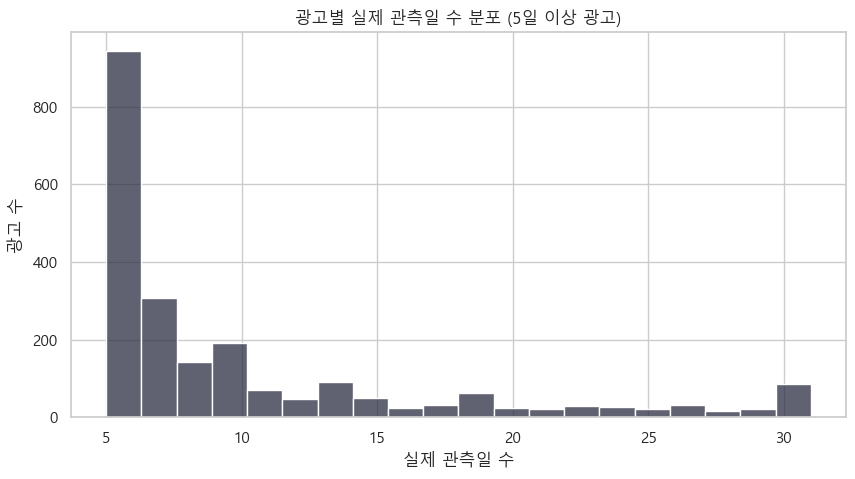

In [96]:
# active_days 분포 (안정성 분석 대상만)


plt.figure(figsize=(10, 5))

sns.histplot(
    data=ads_persistence_stable,
    x="active_days",
    bins=20
)

plt.title("광고별 실제 관측일 수 분포 (5일 이상 광고)")
plt.xlabel("실제 관측일 수")
plt.ylabel("광고 수")
plt.show()

---
### 부록 — 광고별 관측 지속 비율 분포

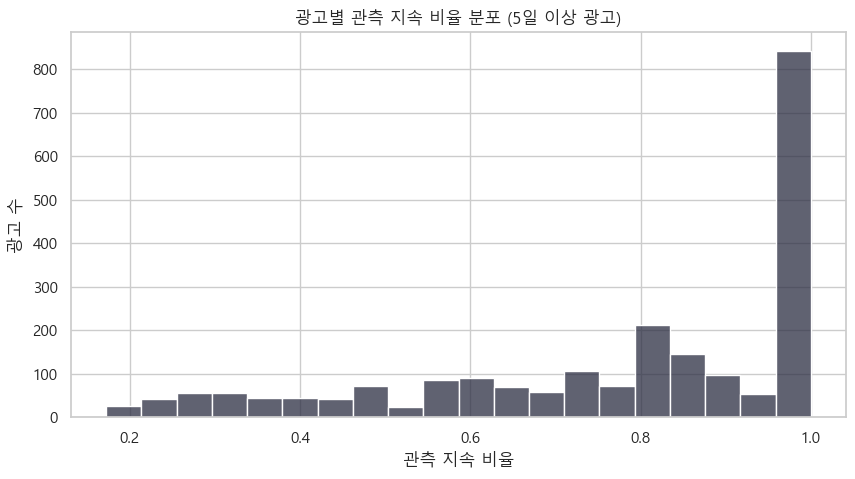

In [97]:
# active_day_ratio 분포 (안정성 분석 대상만)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=ads_persistence_stable,
    x="active_day_ratio",
    bins=20
)

plt.title("광고별 관측 지속 비율 분포 (5일 이상 광고)")
plt.xlabel("관측 지속 비율")
plt.ylabel("광고 수")
plt.show()

- `avg_active_days ≈ 1.06`으로, 대부분의 광고는 관측 기간이 매우 짧다.
- 5일 이상 지속된 광고는 2234 제한적이다.
- `median_total_click_cnt = 0`으로, 절반 이상의 광고는 클릭이 거의 발생하지 않는다.
- 광고가 오래될수록 CVR이 낮아지는 경향이 관측된다.
    - 초반에는 관심이 높은 유저가 먼저 반응하고, 이후에는 관심도가 낮은 유저까지 노출이 확장될 수 있다.
    - 광고 피로도 역시 CVR 하락에 영향을 줄 수 있다.
- 따라서 광고 성과는 관측 기간에 따라 크게 왜곡될 수 있다.
- 안정성 지표는 모든 광고에 일괄 적용하기보다, 일정 수준 이상 관측된 광고에 대한 고신뢰 지표로 해석하는 것이 적절하다.

- 실제 관측일 수 분포에서는 8~10일 구간에 많이 몰린다.
- 일부 광고는 30일 가까이 관측된다.
- 다수 광고는 관측 기간이 짧고, 장기 관측 광고는 소수에 그친다.
- active_day_ratio는 active_days가 짧을수록 높게 나타날 수 있으므로 관측 기간과 함께 해석해야 한다.


### 5-5. 성과 변동성 분석
- 등장한 날들 사이에서 성과가 얼마나 흔들리는가

In [98]:
# 1단계: 성과 변동성 테이블 생성


volatility = (
    mart
    .group_by("ads_idx")
    .agg([
        # 일별 CVR 평균
        pl.col("daily_cvr").mean().alias("avg_cvr"),

        # 일별 CVR 표준편차
        pl.col("daily_cvr").std().alias("std_cvr"),

        # CVR이 0인 날 비율 (%) (성과 끊김)
        ((pl.col("daily_cvr") == 0).mean() * 100).alias("zero_cvr_ratio"),

        # 일별 클릭수 평균 (참고용)
        pl.col("click_cnt").mean().alias("avg_click_cnt"),

        # 관측일 수 (안정성 필터용)
        pl.col("click_day").n_unique().alias("active_days"),
    ])
    .with_columns([
        # 변동계수 (CV)
        (pl.col("std_cvr") / (pl.col("avg_cvr") + 1e-6)).alias("cvr_cv")
    ])
)

volatility.head()

ads_idx,avg_cvr,std_cvr,zero_cvr_ratio,avg_click_cnt,active_days,cvr_cv
str,f64,f64,f64,f64,u32,f64
"""173611""",null,null,null,0.0,1,null
"""129689""",null,null,null,0.0,1,null
"""211957""",null,null,null,0.0,1,null
"""27527""",null,null,null,0.0,1,null
"""100764""",null,null,null,0.0,1,null


In [99]:
# 안정성 분석 대상 필터 (8일 이상)

volatility_stable = (
    volatility
    .filter(pl.col("active_days") >= MIN_ACTIVE_DAYS)
    .to_pandas()
)

print("변동성 분석 대상 광고 수:", volatility_stable.shape[0])

변동성 분석 대상 광고 수: 2234


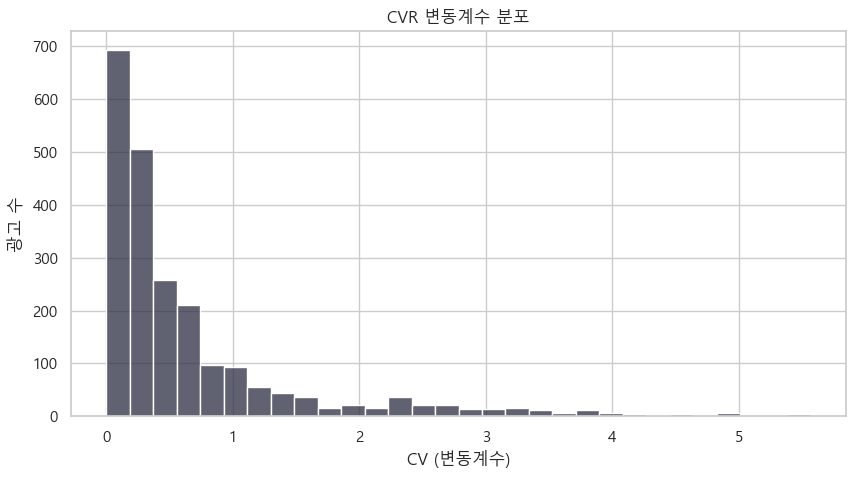

In [100]:
plt.figure(figsize=(10, 5))
sns.histplot(volatility_stable["cvr_cv"].replace([np.inf, -np.inf], np.nan).dropna(), bins=30)

plt.title("CVR 변동계수 분포")
plt.xlabel("CV (변동계수)")
plt.ylabel("광고 수")

plt.show()

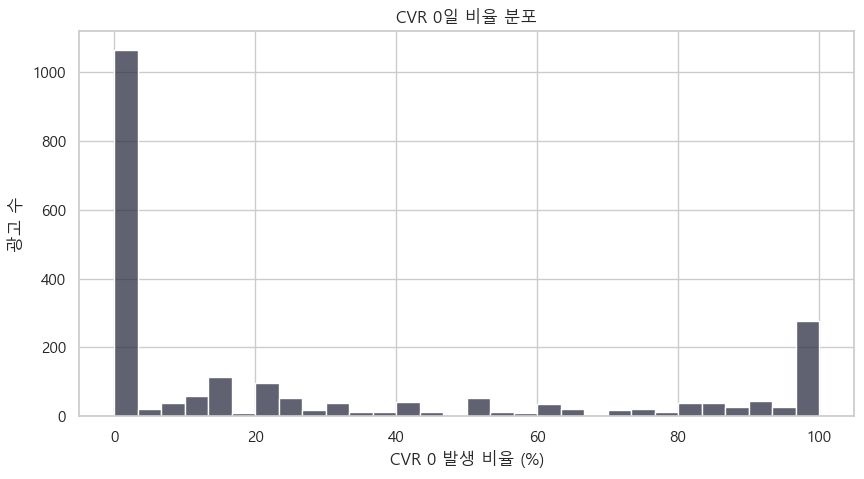

In [101]:
plt.figure(figsize=(10, 5))
sns.histplot(volatility_stable["zero_cvr_ratio"], bins=30)

plt.title("CVR 0일 비율 분포")
plt.xlabel("CVR 0 발생 비율 (%)")
plt.ylabel("광고 수")

plt.show()

#### 관측 기간이 긴 광고의 변동성 해석

- CV 분포상 대부분의 광고는 비교적 안정적이지만, 일부 광고는 극단적으로 큰 변동성을 보인다.
- CVR 0일 비율 분포는 0 근처와 1 근처가 모두 관측되어, 꾸준히 성과가 나는 광고와 성과가 거의 없는 광고가 함께 존재한다.
- active_days 구간별 CVR 변동성을 보면, 오래 관측된 광고일수록 변동성이 큰 광고도 포함된다.
- 이는 생존 편향과 노출 확장 효과로 해석할 수 있다.
- 초기 광고는 특정 유저에게 제한적으로 노출되어 CVR이 비교적 일정할 수 있지만, 오래된 광고는 다양한 유저에게 확장 노출되면서 유저 특성 차이에 따른 변동성이 커질 수 있다.
- 트래픽 변화, 시간대 영향, 광고 피로도 역시 변동성에 영향을 줄 수 있다.


---
### #부록 안정성 분석: 성과 지속 패턴

이 절에서는 시간이 지나면서 광고 성과가 유지, 증가, 감소 중 어떤 방향으로 변화하는지 확인한다.


- 0 근처에 대부분이 몰려 있어, 다수 광고는 초기 대비 후기 성과 변화가 크지 않다.
- 운영 기간이 짧은 광고도 0 근처에 몰려 보일 수 있으므로 관측 기간을 함께 고려해야 한다.
- 음수 구간은 성과 감소형, 양수 구간은 성과 증가형으로 해석한다.
- `cvr_diff`는 표본 규모가 작을 때 변동성이 커질 수 있으므로, 클릭수와 함께 해석해야 한다.


In [102]:
# 광고별 early / late CVR 차이를 보되,
# 패턴 해석이 가능한 광고만 보기 위해 active_days를 붙임
# CVR 변화가 표본 부족 때문인지 확인하기 위해
# early_click_cnt, late_click_cnt도 함께 계산

trend_df = mart.with_columns([
    # observed_n_day 1~3일차는 early, 4일차 이후는 late로 구분
    pl.when(pl.col("observed_n_day") <= 3)
    .then(pl.lit("early"))
    .otherwise(pl.lit("late"))
    .alias("period")
])

trend_summary = (
    trend_df
    .group_by(["ads_idx", "period"])
    .agg([
        # period별 평균 CVR
        pl.col("daily_cvr").mean().alias("avg_cvr"),

        # period별 클릭 수 합계
        pl.col("click_cnt").sum().alias("click_cnt"),

        # period별 완료 수 합계
        pl.col("complete_cnt").sum().alias("complete_cnt"),

        # period별 관측일 수
        pl.col("click_day").n_unique().alias("period_active_days"),
    ])
    .pivot(
        values=["avg_cvr", "click_cnt", "complete_cnt", "period_active_days"],
        index="ads_idx",
        columns="period"
    )
)

trend_summary.head()

ads_idx,avg_cvr_late,avg_cvr_early,click_cnt_late,click_cnt_early,complete_cnt_late,complete_cnt_early,period_active_days_late,period_active_days_early
str,f64,f64,u32,u32,i64,i64,u32,u32
"""185270""",null,null,0,null,0,null,1,null
"""336125""",null,null,0,null,0,null,1,null
"""110304""",null,null,0,null,0,null,1,null
"""198581""",null,null,0,null,0,null,1,null
"""351239""",null,null,0,null,0,null,1,null


In [103]:
# CVR 변화량 & 클릭수 >= 30

trend_summary = trend_summary.with_columns([
    # 후기 CVR - 초기 CVR
    (pl.col("avg_cvr_late") - pl.col("avg_cvr_early")).alias("cvr_diff"),

    # 변화량의 절댓값
    (pl.col("avg_cvr_late") - pl.col("avg_cvr_early")).abs().alias("abs_diff"),

    # 초기/후기 클릭수가 모두 충분한지 여부
    (
        (pl.col("click_cnt_early") >= MIN_AD_CLICKS) &
        (pl.col("click_cnt_late") >= MIN_AD_CLICKS)
    ).alias("enough_click_for_pattern")
])

In [104]:
# active_days (active_days >= 5)

trend_summary = trend_summary.join(
    ads_persistence.select(["ads_idx", "active_days", "active_day_ratio"]),
    on="ads_idx",
    how="left"
)

trend_5 = (
    trend_summary
    .filter(pl.col("active_days") >= MIN_ACTIVE_DAYS)
)

print("5일 이상 광고 수:", trend_5.shape[0])

trend_5.select([
    pl.len().alias("ads_cnt"),
    pl.col("cvr_diff").median().alias("median_cvr_diff"),
    pl.col("abs_diff").median().alias("median_abs_diff"),
    pl.col("click_cnt_early").median().alias("median_early_click"),
    pl.col("click_cnt_late").median().alias("median_late_click"),
    pl.col("enough_click_for_pattern").mean().alias("enough_click_ratio"),
])

5일 이상 광고 수: 2234


ads_cnt,median_cvr_diff,median_abs_diff,median_early_click,median_late_click,enough_click_ratio
u32,f64,f64,f64,f64,f64
2234,0.0,9.475831,13.0,23.0,0.244852


In [105]:
# cvr_diff > 5  : 상승형
# cvr_diff < -5 : 감소형
# 그 외        : 유지형

trend_5_pd = trend_5.to_pandas()

trend_5_pd["pattern"] = np.select(
    [
        trend_5_pd["cvr_diff"] > 5,
        trend_5_pd["cvr_diff"] < -5,
    ],
    [
        "상승형",
        "감소형",
    ],
    default="유지형",
)

pattern_summary = (
    trend_5_pd["pattern"]
    .value_counts()
    .rename_axis("pattern")
    .reset_index(name="ads_cnt")
)

pattern_summary["ratio"] = pattern_summary["ads_cnt"] / pattern_summary["ads_cnt"].sum() * 100

pattern_summary


,pattern,ads_cnt,ratio
0,유지형,822,36.79
1,상승형,724,32.41
2,감소형,688,30.80


In [106]:
# 클릭수가 충분한 광고만 필터링 (click_cnt >= 30)

trend_5_click = trend_5_pd[
    trend_5_pd["enough_click_for_pattern"] == True
].copy()

print("5일 이상 광고 수:", len(trend_5_pd))
print("5일 이상 & 클릭수 충분 광고 수:", len(trend_5_click))

pattern_summary_click_ok = (
    trend_5_click["pattern"]
    .value_counts()
    .rename_axis("pattern")
    .reset_index(name="ads_cnt")
)

pattern_summary_click_ok["ratio"] = (
    pattern_summary_click_ok["ads_cnt"] 
    / pattern_summary_click_ok["ads_cnt"].sum() 
    * 100
)

pattern_summary_click_ok

5일 이상 광고 수: 2234
5일 이상 & 클릭수 충분 광고 수: 547


,pattern,ads_cnt,ratio
0,유지형,249,45.52
1,감소형,164,29.98
2,상승형,134,24.50


### 부록 (CVR 변화량 절댓값 분포 비교 & 클릭수와 CVR 변화량 관계)

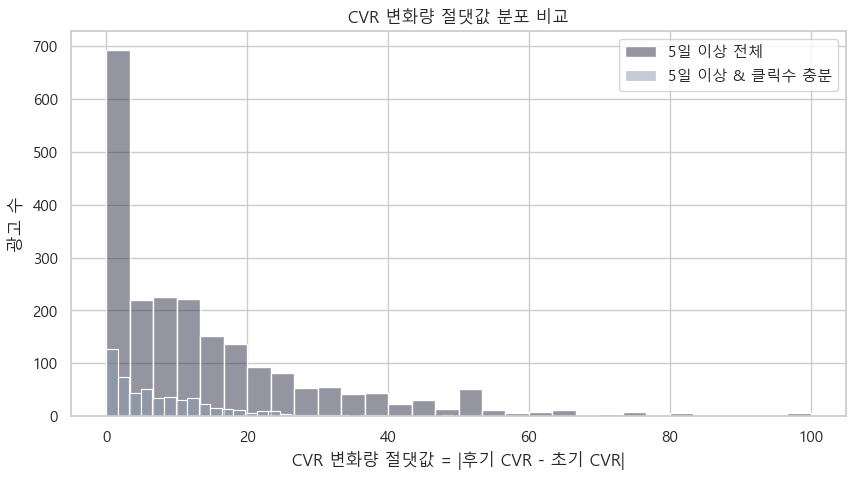

In [107]:
# CVR 변화량 절댓값 분포 비교
## 전체 8일 이상 광고와
## 클릭수가 충분한 광고의 변화량 분포가 다른지 확인

plt.figure(figsize=(10, 5))

sns.histplot(
    trend_5_pd["abs_diff"].dropna(),
    bins=30,
    label="5일 이상 전체",
    alpha=0.5
)

sns.histplot(
    trend_5_click["abs_diff"].dropna(),
    bins=30,
    label="5일 이상 & 클릭수 충분",
    alpha=0.5
)

plt.title("CVR 변화량 절댓값 분포 비교")
plt.xlabel("CVR 변화량 절댓값 = |후기 CVR - 초기 CVR|")
plt.ylabel("광고 수")
plt.legend()
plt.show()

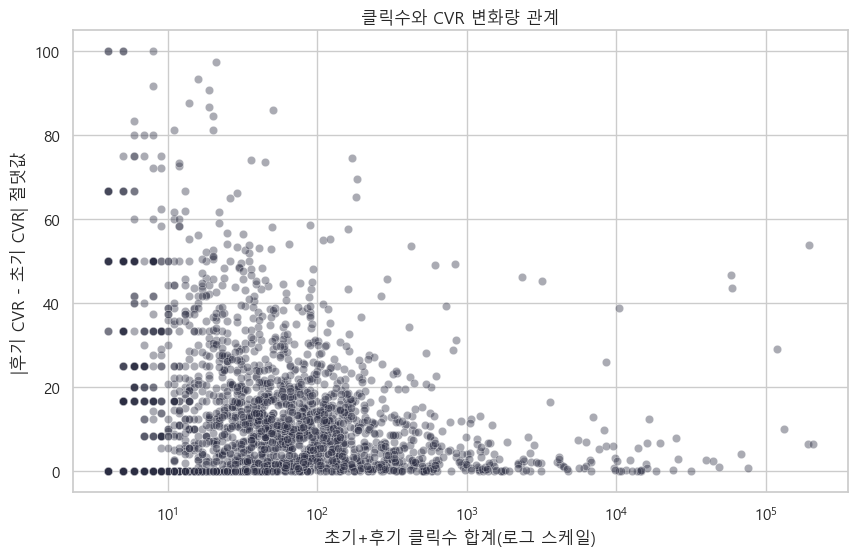

In [108]:
# 클릭수와 CVR 변화량 관계 확인
## 클릭수가 적은 광고일수록 CVR 변화량이 크게 튀는지
## 만약 그런 패턴이 강하면, 패턴 안정성에 클릭수 조건이 필수

trend_5_pd["total_pattern_click"] = (
    trend_5_pd["click_cnt_early"] + trend_5_pd["click_cnt_late"]
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=trend_5_pd,
    x="total_pattern_click",
    y="abs_diff",
    alpha=0.4
)

plt.xscale("log")

plt.title("클릭수와 CVR 변화량 관계")
plt.xlabel("초기+후기 클릭수 합계(로그 스케일)")
plt.ylabel("|후기 CVR - 초기 CVR| 절댓값")
plt.show()


- CVR 변화량 절댓값 분포를 비교하면, 전체 분포는 오른쪽으로 긴 꼬리를 보이지만 클릭수가 충분한 케이스에서는 꼬리가 크게 줄어든다.
- 클릭수가 충분한 케이스는 대부분 0~20 구간에 집중되어 있다.
- 극단적인 CVR 변화는 실제 성과 변화라기보다 표본 부족에 따른 변동일 가능성이 크다.

- 클릭수와 CVR 변화량 관계를 보면, 클릭이 적은 광고는 CVR이 불안정하고 클릭이 많은 광고는 상대적으로 안정적이다.

- 따라서 클릭수가 충분한 광고는 패턴과 변동성을 안정성 판단에 반영할 수 있지만, 클릭수가 부족한 광고는 패턴과 변동성의 신뢰도를 낮게 반영해야 한다.


---
## 5-6. 안정성 정리
#### 5-6-1. 관측 지속성
- 대부분의 광고는 관측 기간이 짧아 안정성 평가가 제한된다.
- 일정 기간 이상 관측된 광고에 한해 안정성 지표를 적극적으로 해석한다.
#### 5-6-2. 관측 지속 비율
- 5~14일 관측된 광고보다 15일 이상 관측된 광고가 더 꾸준히 관측되는 경향이 있다(`관측 지속 비율(active_day_ratio)`).
#### 5-6-3. 성과 변동성
- 오래된 광고는 관측 지속성은 높지만 CVR 변동성이 큰 광고도 포함한다.
- 지속성은 운영 지속 가능성, 변동성은 예측 가능성과 연결된다.
#### 5-6-4. 성과 지속 패턴
- 대부분의 광고는 초기 대비 후기 성과가 크게 변하지 않는다.
- 극단적인 CVR 변화는 실제 성과 변화라기보다 표본 부족에 따른 변동일 가능성이 크다.
#### 5-6-5. 신뢰도 조건의 필요성
- 패턴 분석에서 5일 이상 광고는 2234개였지만, 클릭수 30 이상 조건을 적용하면 547개로 줄어든다.
- 따라서 패턴을 신뢰할 수 있는지 판단하기 위한 신뢰도 조건이 추가로 필요하다.


### 5-7. 안정성 신뢰도 조건 구체화
#### A. 안정성 평가 불가
- active_days < 5

#### B. 안정성 평가 가능, 단 신뢰도 낮음
- active_days >= 5
- 초기 클릭수 < 30   
  또는 후기 클릭수 < 30

#### C. 안정성 평가 가능, 신뢰도 충분
- active_days >= 5
- 초기 클릭수 >= 30
- 후기 클릭수 >= 30

#### 점수화 반영 시
- A: 안정성 점수 미부여 (신뢰도 가중치 = 0)
- B: 안정성 점수는 계산하되 confidence 낮게 반영 (신뢰도 가중치 = 0.5)
- C: 안정성 점수 정상 반영 (신뢰도 가중치 = 1.0)

---
## 6. 규모 분석

광고가 전체 운영에 미치는 영향력과 확장 가능성을 확인한다.

규모는 독립적인 우열 판단 기준이 아니라, 반응성 / 수익성 / 안정성이 실제 운영에 미치는 영향력을 보정하는 축으로 해석한다.


### 6-1. 광고 클릭/완료 집중도 분석

**분석 질문** : 일부 광고에 클릭과 완료가 과도하게 집중되어 있는가?

**사용 지표** : 클릭 점유율, 완료 점유율, HHI 지수, 로렌츠 곡선, 상위 광고 비중

**핵심 해석** : 상위 소수 광고가 전체 클릭과 완료의 상당 부분을 차지한다면, 플랫폼 성과는 특정 광고에 의존하고 있어 운영 안정성 리스크가 있다.  
마진 집중과 매체 의존도는 수익성 분석의 매체 의존 리스크 파트에서 별도로 확인한다.


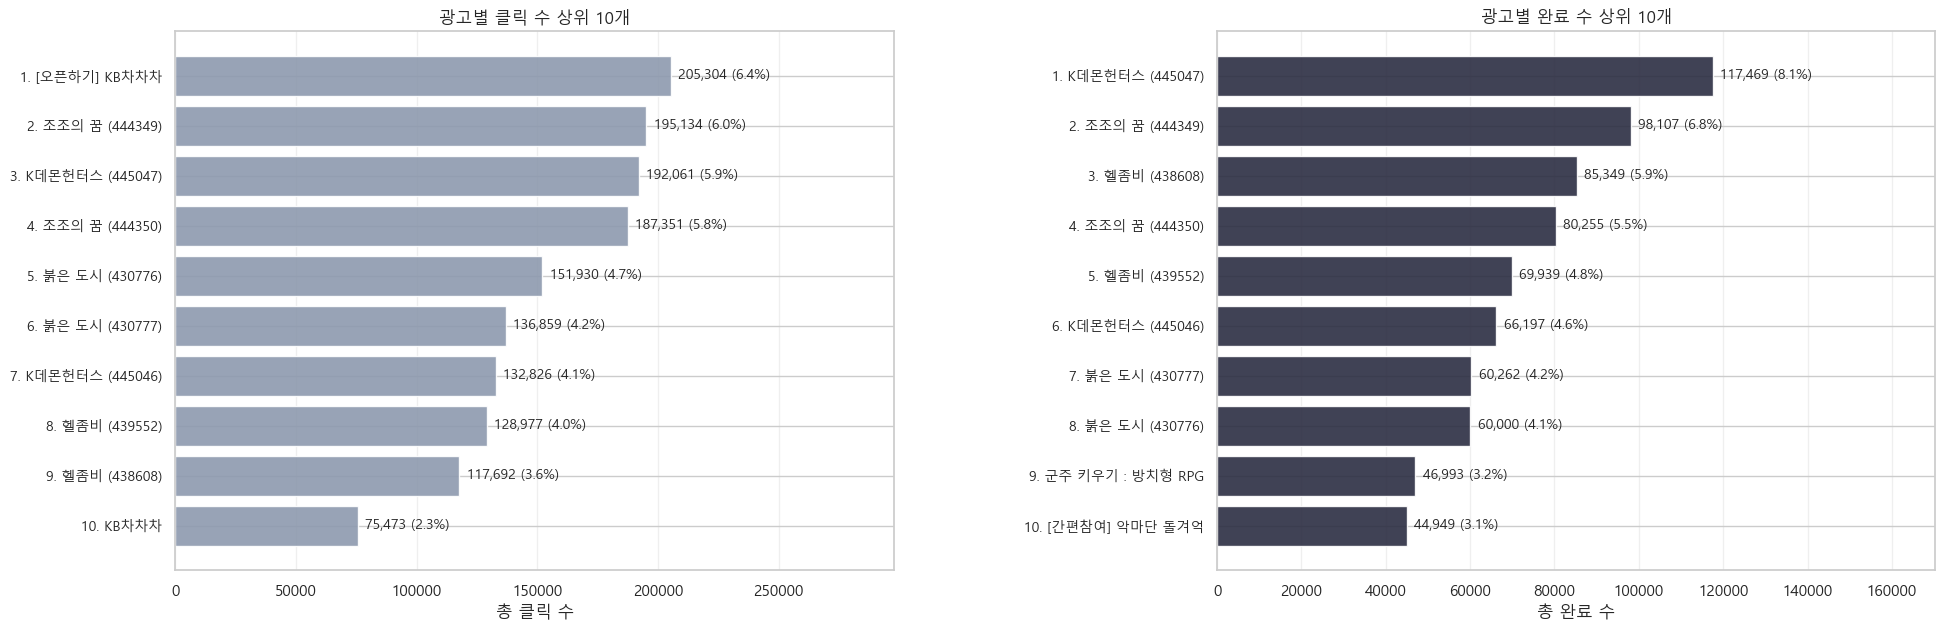

In [109]:
# 광고별 클릭/완료 상위 10개
total_click_sum = ad_df["click_cnt"].sum()
total_complete_sum = ad_df["complete_cnt"].sum()

top_clicks = (
    ad_df
    .sort_values("click_cnt", ascending=False)
    .head(10)[["ads_idx", "ads_name", "click_cnt"]]
    .copy()
)

top_completes = (
    ad_df
    .sort_values("complete_cnt", ascending=False)
    .head(10)[["ads_idx", "ads_name", "complete_cnt"]]
    .copy()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7))
fig.subplots_adjust(left=0.16, right=0.96, wspace=0.45)

plot_ranked_barh(
    ax1,
    top_clicks,
    value_col="click_cnt",
    title="광고별 클릭 수 상위 10개",
    xlabel="총 클릭 수",
    color=BASE_COLOR,
    total_value=total_click_sum,
    max_label_len=16,
)

plot_ranked_barh(
    ax2,
    top_completes,
    value_col="complete_cnt",
    title="광고별 완료 수 상위 10개",
    xlabel="총 완료 수",
    color=LINE_COLOR,
    total_value=total_complete_sum,
    max_label_len=16,
)

plt.show()


**광고 클릭 집중도 요약 (클릭 30건 이상 광고 기준)**

,구분,클릭수,클릭 비중(%)
0,상위 10개 광고,1523607,47.20
1,상위 50개 광고,2427771,75.21
2,상위 100개 광고,2689485,83.32


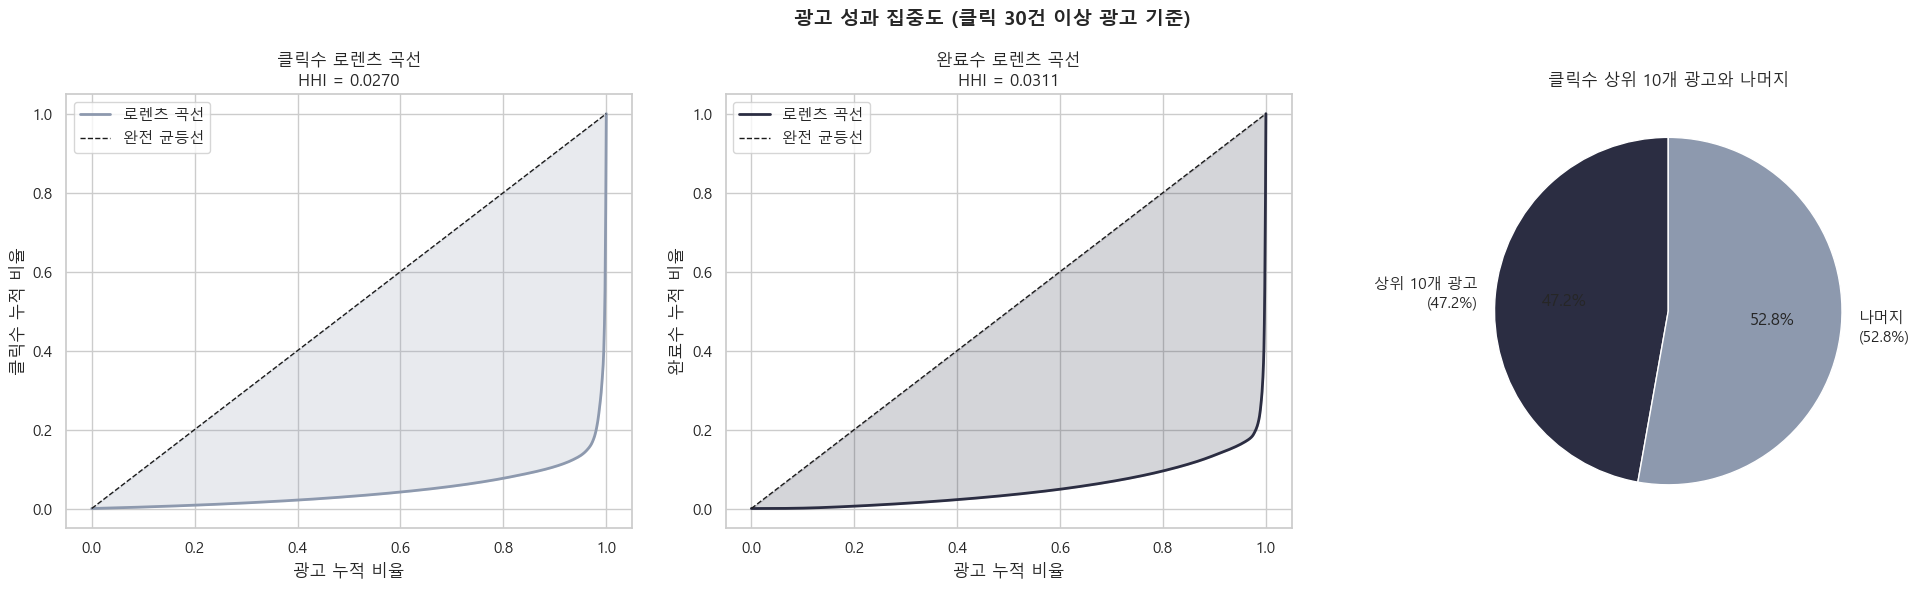

클릭수 기준 HHI: 0.0270
완료수 기준 HHI: 0.0311
상위 10개 광고가 전체 클릭의 47.2% 차지


In [110]:
# 광고 성과 집중도
# 0클릭/저클릭 광고의 영향이 과도해지지 않도록 클릭 30건 이상 광고만 사용한다.
concentration_df = ad_df.copy()
concentration_df["click_cnt"] = pd.to_numeric(concentration_df["click_cnt"], errors="coerce").fillna(0)
concentration_df["complete_cnt"] = pd.to_numeric(concentration_df["complete_cnt"], errors="coerce").fillna(0)

total_clicks_for_conc = concentration_df["click_cnt"].sum()
concentration_summary = []
for n in [10, 50, 100]:
    top_n_clicks = concentration_df.nlargest(n, "click_cnt")["click_cnt"].sum()
    concentration_summary.append({
        "구분": f"상위 {n}개 광고",
        "클릭수": top_n_clicks,
        "클릭 비중(%)": top_n_clicks / total_clicks_for_conc * 100 if total_clicks_for_conc > 0 else np.nan,
    })
concentration_summary = pd.DataFrame(concentration_summary)
show_table("광고 클릭 집중도 요약 (클릭 30건 이상 광고 기준)", concentration_summary, n=10)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("광고 성과 집중도 (클릭 30건 이상 광고 기준)", fontsize=14, fontweight="bold")

hhi_click = hhi(concentration_df["click_cnt"])
hhi_complete = hhi(concentration_df["complete_cnt"])

click_lorenz = make_lorenz(concentration_df["click_cnt"])
complete_lorenz = make_lorenz(concentration_df["complete_cnt"])
#클릭 수와 완료 수 각각에 대해 로렌츠 곡선을 그리고, HHI 지표도 계산해서 제목에 표시한다. 클릭 수 기준으로 상위 10개 광고가 전체 클릭에서 차지하는 비중을 원형 그래프로 시각화한다.
axes[0].plot(click_lorenz["x"], click_lorenz["y"], color=BASE_COLOR, linewidth=2, label="로렌츠 곡선")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="완전 균등선")
axes[0].fill_between(click_lorenz["x"], click_lorenz["y"], click_lorenz["x"], alpha=0.2, color=BASE_COLOR)
axes[0].set_title(f"클릭수 로렌츠 곡선\nHHI = {hhi_click:.4f}")
axes[0].set_xlabel("광고 누적 비율")
axes[0].set_ylabel("클릭수 누적 비율")
axes[0].legend()

axes[1].plot(complete_lorenz["x"], complete_lorenz["y"], color=LINE_COLOR, linewidth=2, label="로렌츠 곡선")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="완전 균등선")
axes[1].fill_between(complete_lorenz["x"], complete_lorenz["y"], complete_lorenz["x"], alpha=0.2, color=LINE_COLOR)
axes[1].set_title(f"완료수 로렌츠 곡선\nHHI = {hhi_complete:.4f}")
axes[1].set_xlabel("광고 누적 비율")
axes[1].set_ylabel("완료수 누적 비율")
axes[1].legend()

top10_clicks = concentration_df.sort_values("click_cnt", ascending=False).head(10)["click_cnt"].sum()
rest_clicks = concentration_df["click_cnt"].sum() - top10_clicks
top10_pct = top10_clicks / concentration_df["click_cnt"].sum() * 100 if concentration_df["click_cnt"].sum() > 0 else np.nan
axes[2].pie(
    [top10_clicks, rest_clicks],
    labels=[f"상위 10개 광고\n({top10_pct:.1f}%)", f"나머지\n({100 - top10_pct:.1f}%)"],
    colors=get_plot_colors(2),
    autopct="%1.1f%%",
    startangle=90,
)
axes[2].set_title("클릭수 상위 10개 광고와 나머지")

plt.tight_layout()
plt.show()

print(f"클릭수 기준 HHI: {hhi_click:.4f}")
print(f"완료수 기준 HHI: {hhi_complete:.4f}")
print(f"상위 10개 광고가 전체 클릭의 {top10_pct:.1f}% 차지")


### 6-2. 운영 영향력 진단 기준

규모 축은 개별 광고의 성과가 전체 운영에 미치는 영향력을 확인한다.

- CVR이 높더라도 트래픽이 매우 작으면 운영상 영향력은 제한적이다.
- CVR이 낮더라도 트래픽이 매우 크면 전체 운영 성과에 미치는 영향이 크다.
- 따라서 규모 지표는 반응성·수익성·안정성 해석을 보정하는 보조 축으로 사용한다.

1. 트래픽 규모(`click_cnt` 분포)
2. 규모와 성과 유지 여부
3. 유입 다양성 및 확장 가능성
4. 소진 속도 보조 지표


### 6-3. 트래픽 규모 및 규모 티어 정의

In [111]:
# 광고별 총 트래픽 집계
# 이후 집중도, 상위 광고 요약, 규모 티어 분석에서 같은 traffic 테이블을 재사용한다.

traffic = (
    mart
    .group_by("ads_idx")
    .agg([
        pl.col("click_cnt").sum().alias("total_click_cnt"),
        pl.col("complete_cnt").sum().alias("total_complete_cnt"),
    ])
    .to_pandas()
    .sort_values("total_click_cnt", ascending=False)
    .reset_index(drop=True)
)

total_click = traffic["total_click_cnt"].sum()
total_ads = len(traffic)

traffic["cum_click"] = traffic["total_click_cnt"].cumsum()
traffic["cum_ratio"] = traffic["cum_click"] / total_click
traffic["rank"] = np.arange(1, total_ads + 1)
traffic["rank_ratio"] = traffic["rank"] / total_ads

TIER_ORDER = ["Ultra Top (0.1%)", "Top (1%)", "Others"]
TIER_DISPLAY_LABELS = {
    "Ultra Top (0.1%)": "초상위 0.1%",
    "Top (1%)": "상위 0.1~1%",
    "Others": "기타",
}

def apply_tier_xticklabels(ax):
    ax.set_xticklabels([
        TIER_DISPLAY_LABELS.get(label.get_text(), label.get_text())
        for label in ax.get_xticklabels()
    ])


traffic["tier"] = np.select(
    [
        traffic["rank_ratio"] <= 0.001,
        traffic["rank_ratio"] <= 0.01,
    ],
    [
        "Ultra Top (0.1%)",
        "Top (1%)",
    ],
    default="Others",
)

traffic.head()


,ads_idx,total_click_cnt,total_complete_cnt,cum_click,cum_ratio,rank,rank_ratio,tier
0,440167,205304,31256,205304,0.06,1,0.00,Ultra Top (0.1%)
1,444349,195134,98107,400438,0.13,2,0.00,Ultra Top (0.1%)
2,445047,192061,117469,592499,0.19,3,0.00,Ultra Top (0.1%)
3,444350,187351,80255,779850,0.25,4,0.00,Ultra Top (0.1%)
4,430776,151930,60000,931780,0.29,5,0.00,Ultra Top (0.1%)


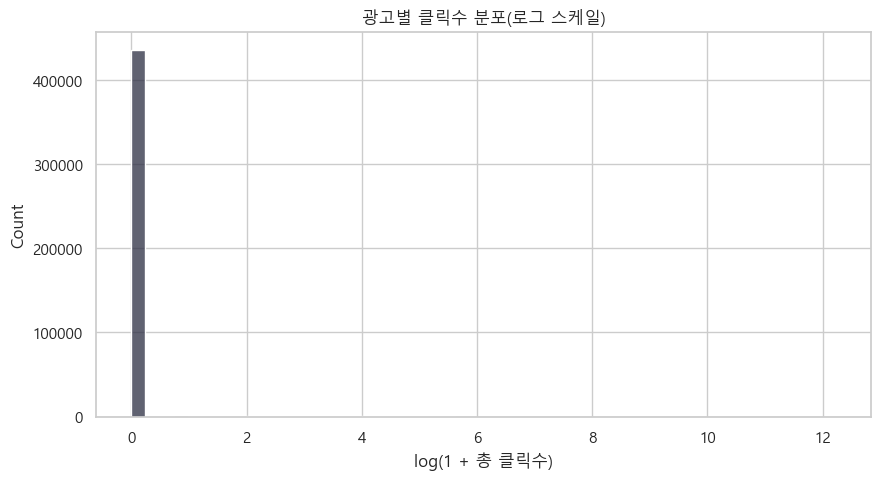

In [112]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(traffic["total_click_cnt"]),
    bins=50
)

plt.title("광고별 클릭수 분포(로그 스케일)")
plt.xlabel("log(1 + 총 클릭수)")
plt.show()

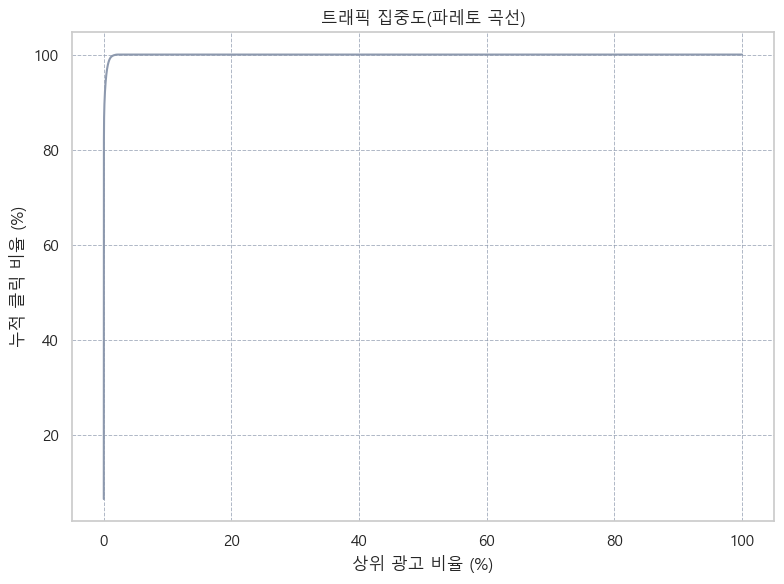

In [113]:
plt.figure(figsize=(8, 6))

plt.plot(
    traffic["rank_ratio"] * 100,
    traffic["cum_ratio"] * 100,
    color=BASE_COLOR
)

plt.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.7,
    color=GRAY_COLOR  
)

plt.xlabel("상위 광고 비율 (%)")
plt.ylabel("누적 클릭 비율 (%)")
plt.title("트래픽 집중도(파레토 곡선)")

plt.tight_layout()
plt.show()

- 거의 모든 광고가 로그값 0 근처에 위치해 극단적인 롱테일 구조를 보인다.
- 대부분의 광고는 클릭이 거의 없고, 소수 광고가 매우 큰 트래픽 볼륨을 차지한다.
- 상위 1~2% 광고가 전체 트래픽의 대부분을 차지한다.
- 따라서 다수 광고의 실질 운영 영향력은 제한적이다.
- 운영 판단은 상위 광고의 안정성과 수익성을 중심으로 하되, 나머지 광고는 표본 신뢰도와 테스트 목적을 함께 고려해 해석한다.


#### 6-3-1. 상위 광고와 기타 광고 비교

In [114]:
# Top 광고 기준별 요약 확인

thresholds = [0.8, 0.9, 0.95]

for threshold in thresholds:
    col = f"is_top_{int(threshold * 100)}"
    traffic[col] = traffic["cum_ratio"] <= threshold

top_summary_list = []

for threshold in thresholds:
    col = f"is_top_{int(threshold * 100)}"
    top_ads = traffic[traffic[col]]

    top_summary_list.append({
        "threshold": f"Top {int(threshold * 100)}% traffic",
        "top_ads_cnt": len(top_ads),
        "top_ads_ratio_pct": len(top_ads) / total_ads * 100,
        "covered_click_cnt": top_ads["total_click_cnt"].sum(),
        "covered_click_ratio_pct": top_ads["total_click_cnt"].sum() / total_click * 100,
        "min_click_in_top": top_ads["total_click_cnt"].min(),
        "max_click_in_top": top_ads["total_click_cnt"].max(),
        "median_click_in_top": top_ads["total_click_cnt"].median(),
    })

top_summary = pd.DataFrame(top_summary_list)

top_summary


,threshold,top_ads_cnt,top_ads_ratio_pct,covered_click_cnt,covered_click_ratio_pct,min_click_in_top,max_click_in_top,median_click_in_top
0,Top 80% traffic,72,0.02,2542121,79.90,4762,205304,"13,280.50"
1,Top 90% traffic,498,0.11,2863440,90.00,251,205304,507.50
2,Top 95% traffic,1505,0.34,3022656,95.00,102,205304,191.00


In [115]:
# 광고 개수 상위 비율별 트래픽 점유율 확인

rank_summary_list = []

for rank_pct in [0.1, 0.5, 1, 2, 5, 10]:
    n_top = max(1, int(total_ads * rank_pct / 100))
    top_part = traffic.head(n_top)

    rank_summary_list.append({
        "top_ads_ratio": f"상위 {rank_pct}%",
        "ads_cnt": n_top,
        "click_ratio_pct": top_part["total_click_cnt"].sum() / total_click * 100,
        "min_click": top_part["total_click_cnt"].min(),
        "median_click": top_part["total_click_cnt"].median(),
    })

rank_summary = pd.DataFrame(rank_summary_list)

rank_summary

,top_ads_ratio,ads_cnt,click_ratio_pct,min_click,median_click
0,상위 0.1%,445,89.56,277,570.00
1,상위 0.5%,2226,96.83,63,134.00
2,상위 1%,4452,99.24,16,63.00
3,상위 2%,8905,99.98,1,16.00
4,상위 5%,22263,100.00,0,0.00
5,상위 10%,44526,100.00,0,0.00


- 누적 상위 0.1% 광고는 전체 클릭의 대부분을 차지한다.
- 누적 상위 1% 광고까지 포함하면 전체 클릭 점유율이 매우 높다.
- 이후 티어 비교에서는 `초상위 0.1%`, `상위 0.1~1%`, `기타`로 구분한다.
- 상위 그룹 안에서도 트래픽 규모 차이가 크다.

#### 6-3-2. 규모 티어 정의
누적 클릭 기여도 기준으로 `초상위 0.1%`, `상위 0.1~1%`, `기타`를 구분한다. 코드 변수명은 기존과 같이 유지한다.


In [116]:
# 계층별 트래픽 요약

tier_summary = (
    traffic
    .groupby("tier")
    .agg(
        ads_cnt=("total_click_cnt", "count"),
        total_click=("total_click_cnt", "sum"),
        median_click=("total_click_cnt", "median"),
        min_click=("total_click_cnt", "min"),
        max_click=("total_click_cnt", "max"),
    )
    .reset_index()
)

tier_summary["ads_ratio_pct"] = tier_summary["ads_cnt"] / total_ads * 100
tier_summary["click_ratio_pct"] = tier_summary["total_click"] / total_click * 100

tier_summary


,tier,ads_cnt,total_click,median_click,min_click,max_click,ads_ratio_pct,click_ratio_pct
0,Others,440808,24089,0.00,0,16,99.00,0.76
1,Top (1%),4007,308211,55.00,16,276,0.90,9.69
2,Ultra Top (0.1%),445,2849476,570.00,277,205304,0.10,89.56


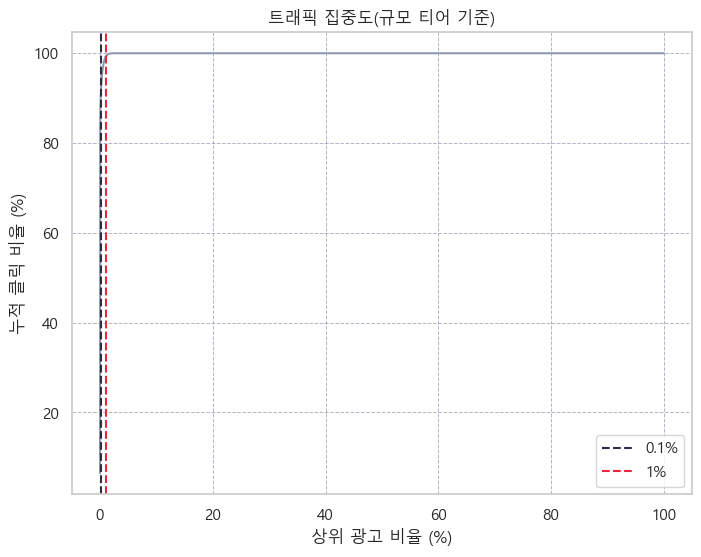

In [117]:
plt.figure(figsize=(8,6))

plt.plot(traffic["rank_ratio"] * 100, traffic["cum_ratio"] * 100, color=BASE_COLOR)

# 계층 구간 표시
plt.axvline(x=0.1, color=PALETTE_3[0], linestyle='--', label='0.1%')
plt.axvline(x=1, color=PALETTE_3[2], linestyle='--', label='1%')

plt.xlabel("상위 광고 비율 (%)")
plt.ylabel("누적 클릭 비율 (%)")
plt.title("트래픽 집중도(규모 티어 기준)")
plt.legend()
plt.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.7,
    color=GRAY_COLOR  
)

plt.show()

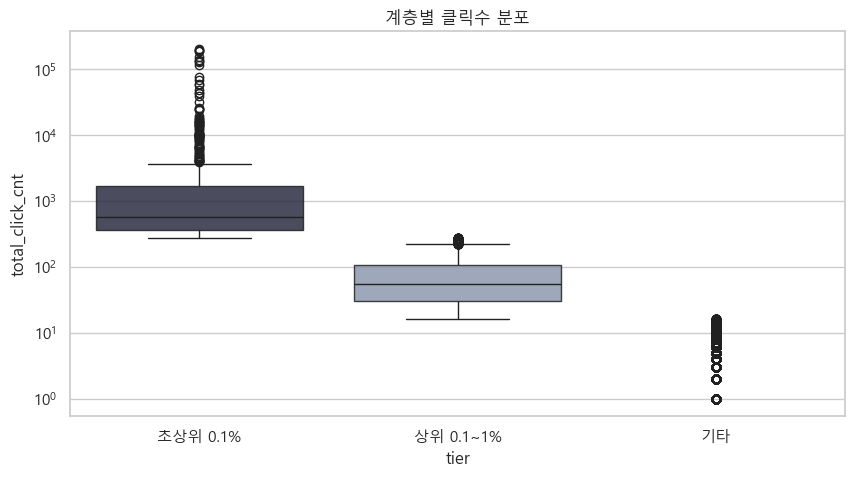

In [118]:
plt.figure(figsize=(10,5))

ax = sns.boxplot(data=traffic, x="tier", y="total_click_cnt")
apply_box_colors(ax)
apply_tier_xticklabels(ax)

plt.yscale("log")
plt.title("계층별 클릭수 분포")
plt.show()

#### 상위 0.1%
- median_click = 570
- max = 205,304
- 상위 소수 광고가 전체 트래픽과 성과의 상당 부분을 차지한다.
- 상위 광고 내부에서도 분산이 크고 이상치가 존재한다.

#### 상위 1%
- median_click = 55
- 전체 트래픽의 일부를 차지하며, 확장 가능한 후보군으로 해석할 수 있다.

#### 나머지
- median_click = 0
- 트래픽 비중이 낮아 운영 판단에 활용하기에는 표본 규모가 작으며 해석에 주의가 필요하다.

#### 후속 점수화 활용 방향
- 모든 광고에 대해 반응성, 수익성, 안정성 점수를 계산하고 신뢰도와 규모를 함께 반영한다.
- 0.1% 구간은 점수 기반으로 유지, 확대, 축소 후보를 판단한다.
- 1% 구간은 성장 가능성을 평가한다.
- 나머지 구간은 표본 신뢰도를 함께 고려해 유지 또는 개선 후보 여부를 판단한다.
- 후속 점수화에서는 `(반응성 + 수익성 + 안정성) * 신뢰도 * 규모` 구조를 후보 기준으로 활용할 수 있다.


### 6-4. 규모 티어별 성과 비교

In [119]:
# 안정성, tier 정보 mart에 붙이기

mart_tier = (
    mart
    # 안정성 컬럼 붙이기
    .join(
        ads_persistence.select(["ads_idx", "active_days", "active_day_ratio"]),
        on="ads_idx",
        how="left",
    )
    # tier 붙이기
    .join(
        pl.from_pandas(traffic[["ads_idx", "tier"]]),
        on="ads_idx",
        how="left",
    )
)


# 광고 단위 요약

ads_summary = (
    mart_tier
    .group_by(["ads_idx", "tier"])
    .agg([
        # 반응성
        pl.col("click_cnt").sum().alias("total_click"),
        pl.col("complete_cnt").sum().alias("total_complete"),
        (pl.col("complete_cnt").sum() / pl.col("click_cnt").sum() * 100).alias("cvr"),

        # 수익성
        pl.col("daily_valid_margin").sum().alias("total_margin"),
        (pl.col("daily_valid_margin").sum() / pl.col("click_cnt").sum()).alias("margin_per_click"),

        # 안정성
        pl.col("active_days").max().alias("active_days"),
        pl.col("active_day_ratio").mean().alias("active_day_ratio"),
        pl.col("daily_cvr").std().alias("cvr_std"),
    ])
    .to_pandas()
)



In [120]:
# 비교 테이블

summary_compare = (
    ads_summary
    .groupby("tier")
    .agg(
        ads_cnt=("ads_idx", "count"),

        # 반응성
        median_cvr=("cvr", "median"),
        mean_cvr=("cvr", "mean"),

        # 수익성
        median_margin=("total_margin", "median"),
        median_margin_per_click=("margin_per_click", "median"),

        # 안정성
        median_active_days=("active_days", "median"),
        median_active_ratio=("active_day_ratio", "median"),
        median_cvr_std=("cvr_std", "median")
    )
    .reset_index()
)

summary_compare

,tier,ads_cnt,median_cvr,mean_cvr,median_margin,median_margin_per_click,median_active_days,median_active_ratio,median_cvr_std
0,Others,440808,66.67,56.72,0.00,3.00,1.00,1.00,23.57
1,Top (1%),4007,69.44,60.66,162.00,2.95,3.00,1.00,15.07
2,Ultra Top (0.1%),445,34.26,36.74,"1,488.00",3.08,7.00,1.00,6.71


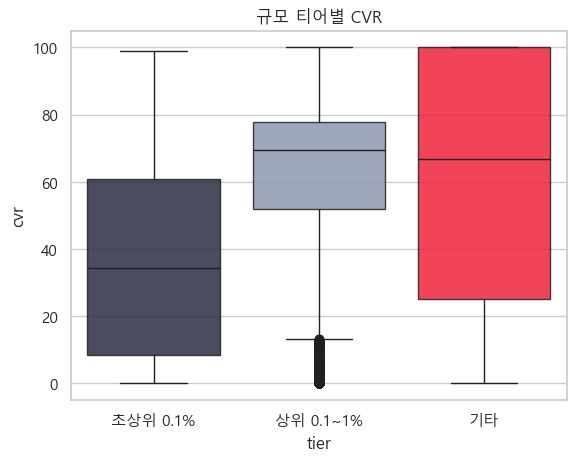

In [121]:
# cvr 시각화

ax = sns.boxplot(data=ads_summary, x="tier", y="cvr", order=TIER_ORDER)
apply_box_colors(ax)
apply_tier_xticklabels(ax)

plt.title("규모 티어별 CVR")
plt.show()


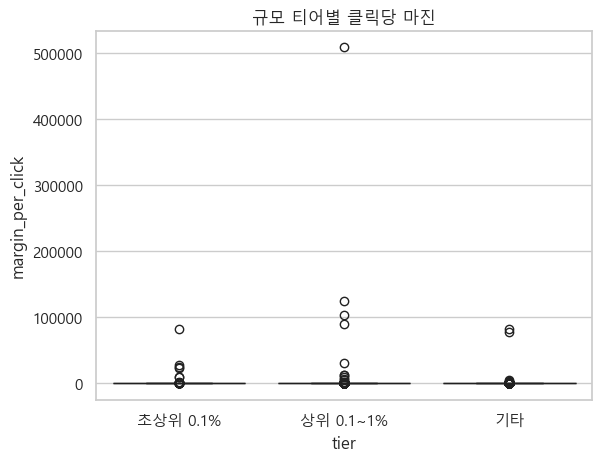

In [122]:
# 마진 시각화
ax = sns.boxplot(data=ads_summary, x="tier", y="margin_per_click", order=TIER_ORDER)
apply_box_colors(ax)
apply_tier_xticklabels(ax)

plt.title("규모 티어별 클릭당 마진")
plt.show()


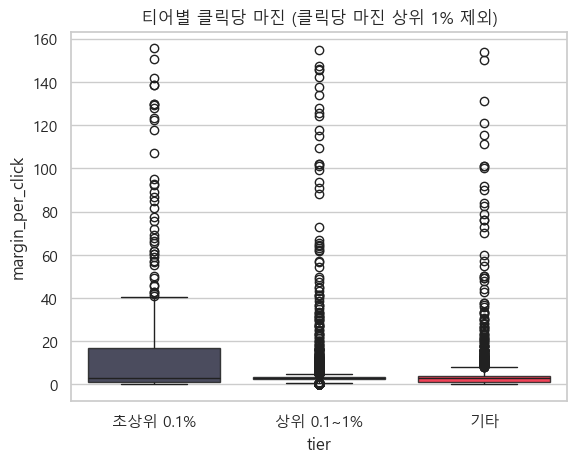

In [123]:
# 이상치(상위 1%) 제외하고 다시 확인

ads_filtered = ads_summary[
    ads_summary["margin_per_click"] <= ads_summary["margin_per_click"].quantile(0.99)
]

ax = sns.boxplot(data=ads_filtered, x="tier", y="margin_per_click", order=TIER_ORDER)
apply_box_colors(ax)
apply_tier_xticklabels(ax)
plt.title("티어별 클릭당 마진 (클릭당 마진 상위 1% 제외)")
plt.show()


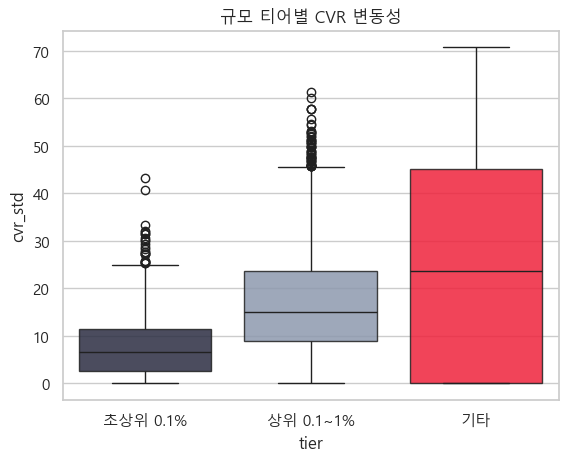

In [124]:
# 변동성 시각화
ax = sns.boxplot(data=ads_summary, x="tier", y="cvr_std", order=TIER_ORDER)
apply_box_colors(ax)
apply_tier_xticklabels(ax)
plt.title("규모 티어별 CVR 변동성")
plt.show()


### #부록 규모 분석: 티어별 성과 차이 원인 확인

`Ultra Top / Top / 기타` 간 성과 차이가 단순 규모 차이인지, 광고유형·카테고리·보상구간 구성 차이와 연결되는지 확인한다.  
본 분석에서는 규모 티어를 `Ultra Top / Top / 기타` 기준으로 통일해 해석한다.

In [125]:
# 티어별 광고 속성 구성 비교
# 광고 1개를 1행으로 고정한 뒤, 티어별 주요 구성 비율을 확인한다.

ads_level_tier = (
    mart_tier
    .select([
        "ads_idx",
        "tier",
        "reward_band",
        "analysis_ads_type_label",
        "category_name",
    ])
    .unique(subset=["ads_idx"])
    .to_pandas()
)

reward_tier_dist = (
    ads_level_tier
    .groupby(["tier", "reward_band"])
    .size()
    .reset_index(name="ads_cnt")
)
reward_tier_dist["ratio_pct"] = (
    reward_tier_dist["ads_cnt"]
    / reward_tier_dist.groupby("tier")["ads_cnt"].transform("sum")
    * 100
)
reward_tier_dist["tier"] = pd.Categorical(
    reward_tier_dist["tier"],
    categories=TIER_ORDER,
    ordered=True,
)
reward_tier_dist["reward_band"] = pd.Categorical(
    reward_tier_dist["reward_band"],
    categories=reward_order,
    ordered=True,
)
reward_tier_dist = reward_tier_dist.sort_values(["tier", "reward_band"])

print("[티어별 reward_band 구성]")
display(reward_tier_dist)

type_tier_dist = (
    ads_level_tier
    .groupby(["tier", "analysis_ads_type_label"])
    .size()
    .reset_index(name="ads_cnt")
)
type_tier_dist["ratio_pct"] = (
    type_tier_dist["ads_cnt"]
    / type_tier_dist.groupby("tier")["ads_cnt"].transform("sum")
    * 100
)
type_tier_dist["tier"] = pd.Categorical(
    type_tier_dist["tier"],
    categories=TIER_ORDER,
    ordered=True,
)
type_tier_top = (
    type_tier_dist
    .sort_values(["tier", "ratio_pct"], ascending=[True, False])
    .groupby("tier")
    .head(5)
)

print("[티어별 광고유형 TOP5 구성]")
display(type_tier_top)

category_tier_dist = (
    ads_level_tier
    .groupby(["tier", "category_name"])
    .size()
    .reset_index(name="ads_cnt")
)
category_tier_dist["ratio_pct"] = (
    category_tier_dist["ads_cnt"]
    / category_tier_dist.groupby("tier")["ads_cnt"].transform("sum")
    * 100
)
category_tier_dist["tier"] = pd.Categorical(
    category_tier_dist["tier"],
    categories=TIER_ORDER,
    ordered=True,
)
category_tier_top = (
    category_tier_dist
    .sort_values(["tier", "ratio_pct"], ascending=[True, False])
    .groupby("tier")
    .head(5)
)

print("[티어별 카테고리 TOP5 구성]")
display(category_tier_top)

[티어별 reward_band 구성]


,tier,reward_band,ads_cnt,ratio_pct
14,Ultra Top (0.1%),50원 미만,226,50.79
13,Ultra Top (0.1%),50~99원,6,1.35
10,Ultra Top (0.1%),100~299원,110,24.72
11,Ultra Top (0.1%),300~499원,10,2.25
12,Ultra Top (0.1%),500원 이상,93,20.90
9,Top (1%),50원 미만,3691,92.11
8,Top (1%),50~99원,1,0.02
5,Top (1%),100~299원,40,1.00
6,Top (1%),300~499원,51,1.27
7,Top (1%),500원 이상,224,5.59


[티어별 광고유형 TOP5 구성]


,tier,analysis_ads_type_label,ads_cnt,ratio_pct
25,Ultra Top (0.1%),참여형,331,74.38
20,Ultra Top (0.1%),설치형,51,11.46
21,Ultra Top (0.1%),실행형,30,6.74
26,Ultra Top (0.1%),퀘스트,13,2.92
18,Ultra Top (0.1%),CPS(물건구매),9,2.02
15,Top (1%),참여형,3888,97.03
16,Top (1%),퀘스트,76,1.90
12,Top (1%),CPS(물건구매),32,0.80
14,Top (1%),실행형,7,0.17
13,Top (1%),설치형,3,0.07


[티어별 카테고리 TOP5 구성]


,tier,category_name,ads_cnt,ratio_pct
25,Ultra Top (0.1%),간편미션-퀴즈,214,48.09
31,Ultra Top (0.1%),무료참여,49,11.01
27,Ultra Top (0.1%),경험하기(CPI/CPE),41,9.21
34,Ultra Top (0.1%),앱(간편적립),33,7.42
26,Ultra Top (0.1%),경험하기(CPA),26,5.84
13,Top (1%),간편미션-퀴즈,3688,92.04
14,Top (1%),경험하기(CPA),84,2.10
18,Top (1%),멀티보상(게임),57,1.42
23,Top (1%),유료참여,51,1.27
19,Top (1%),무료참여,44,1.10


- CVR(반응성)
    - top 1% > others > top 0.1% 순으로 나타난다.
    - top 1%는 반응성이 가장 높은 구간으로 해석된다.
    - top 0.1%는 트래픽 규모가 크지만 반드시 가장 높은 반응성을 보이는 것은 아니다.
    - others는 분산이 커서 표본 착시 가능성이 있다.
- margin
    - ultra top은 분포가 넓고 중앙값은 낮지만 상위 꼬리가 존재한다.
    - top은 상대적으로 좁고 안정적인 분포를 보인다.
    - others는 top과 유사하거나 약간 낮으며, 분산은 더 넓은 편이다.
- CVR 변동성
    - others > top > ultra top 순으로 나타난다.
    - 규모가 큰 광고일수록 CVR 변동성이 상대적으로 안정적이다.
    - ultra top 광고는 트래픽이 많고 운영 기간이 길며 성과도 안정적인 경향을 보인다.
    - 큰 광고가 무조건 좋은 광고는 아니지만, 규모가 크기 때문에 전체 수익 기여도가 높다.
    - 수익 기여도는 효율뿐 아니라 규모의 영향을 크게 받는다.
    - 반응성은 top 광고 구간에서 더 높게 나타난다.


---
### #부록 규모 분석: 시간대별 트래픽 집중도
**분석 질문** : 특정 시간대에 클릭 수요가 몰리거나, 일부 광고에 클릭이 과도하게 집중되는가?

**사용 테이블** : `main_funnel_work`

**역할 구분** : 이 절의 시간대 분석은 반응성 판단이 아니라, 시간대별 클릭·완료 집중도를 통해 트래픽이 특정 시간대에 몰리는지 확인하는 규모 진단이다.

**핵심 기준** :  
- 시간대별 클릭 수와 완료율  
- 시간대별 활성 광고 수  
- 시간대별 top1 광고 클릭 비중  
- 시간대별 광고 클릭 HHI  
- 시간대별 광고유형 클릭 HHI  

**운영 연결** : 특정 시간대에 수요는 높지만 완료율이 낮은 경우 시간대 타겟 운영 또는 노출 조정 후보로 본다. 특정 광고 집중도가 높은 시간대는 광고 다양성 부족 또는 메인 슬롯 쏠림 리스크로 해석한다.


In [126]:
# 시간대별 수요 쏠림 / 집중도 진단

# 시간대별 기본 수요/성과 요약
hour_summary = (
    main_funnel_work
    .groupby("click_hour")
    .agg(
        click_cnt=("click_key", "count"),
        complete_cnt=("is_completed", "sum"),
        active_ads_cnt=("ads_idx", "nunique"),
        active_type_cnt=(type_col, "nunique"),
    )
    .reset_index()
)

# 시간대별 완료율
hour_summary["hour_cvr"] = safe_divide(
    hour_summary["complete_cnt"],
    hour_summary["click_cnt"],
    100,
)

# 활성 광고 1개당 클릭 수
# - 클릭 수요가 특정 시간대에 과하게 몰리는지 보는 보조 지표
hour_summary["click_per_active_ad"] = safe_divide(
    hour_summary["click_cnt"],
    hour_summary["active_ads_cnt"],
    1,
)


In [127]:
# 시간대 × 광고 기준 집중도
# 시간대별 광고 클릭 수 집계
hour_ad = (
    main_funnel_work
    .groupby(["click_hour", "ads_idx"])
    .agg(ad_click_cnt=("click_key", "count"))
    .reset_index()
)

# 각 시간대에서 클릭 수가 가장 많은 top1 광고
hour_top_ad = (
    hour_ad
    .sort_values(["click_hour", "ad_click_cnt"], ascending=[True, False])
    .drop_duplicates("click_hour")
)

# 시간대별 광고 클릭 HHI
# - HHI가 높을수록 클릭이 소수 광고에 집중됨
hour_ad_hhi = (
    hour_ad
    .groupby("click_hour")["ad_click_cnt"]
    .apply(hhi)
    .reset_index(name="hhi_ad_click")
)

In [128]:
# 시간대 × 광고유형 기준 집중도
# 시간대별 광고유형 클릭 수 집계
hour_type = (
    main_funnel_work
    .groupby(["click_hour", type_col])
    .agg(type_click_cnt=("click_key", "count"))
    .reset_index()
)

# 시간대별 광고유형 클릭 HHI
# - HHI가 높을수록 특정 광고유형에 클릭이 집중됨
hour_type_hhi = (
    hour_type
    .groupby("click_hour")["type_click_cnt"]
    .apply(hhi)
    .reset_index(name="hhi_type_click")
)

# 시간대 집중도 지표 통합
hour_concentration = (
    hour_summary
    .merge(
        hour_top_ad[["click_hour", "ads_idx", "ad_click_cnt"]],
        on="click_hour",
        how="left",
    )
    .merge(hour_ad_hhi, on="click_hour", how="left")
    .merge(hour_type_hhi, on="click_hour", how="left")
)

# top1 광고 클릭 비중
# - 해당 시간대 전체 클릭 중 1등 광고가 차지하는 비중
hour_concentration["top1_ad_click_share_pct"] = safe_divide(
    hour_concentration["ad_click_cnt"],
    hour_concentration["click_cnt"],
    100,
)

hour_concentration = hour_concentration.rename(
    columns={
        "ads_idx": "top1_ads_idx",
        "ad_click_cnt": "top1_ad_click_cnt",
    }
)


In [129]:
# 시간대별 진단 신호 생성
# 상대 기준을 사용한다.
# - 클릭 수 상위 25% 시간대
# - 광고 집중도 상위 25% 시간대
# - 완료율 하위 25% 시간대
click_q75_hour = hour_concentration["click_cnt"].quantile(0.75)
hhi_q75_hour = hour_concentration["hhi_ad_click"].quantile(0.75)
cvr_q25_hour = hour_concentration["hour_cvr"].quantile(0.25)

hour_concentration["진단 신호"] = ""

# 클릭은 많이 발생하지만 완료율은 낮은 시간대
# - 시간대 타겟 운영 또는 노출 구성 점검 후보
hour_concentration.loc[
    (hour_concentration["click_cnt"] >= click_q75_hour)
    & (hour_concentration["hour_cvr"] <= cvr_q25_hour),
    "진단 신호"
] += "수요 높지만 완료율 낮음; "

# 특정 광고에 클릭이 집중된 시간대
# - 메인 슬롯 쏠림 또는 광고 다양성 부족 가능성
hour_concentration.loc[
    hour_concentration["hhi_ad_click"] >= hhi_q75_hour,
    "진단 신호"
] += "특정 광고 집중; "

# 마지막 세미콜론 제거
hour_concentration["진단 신호"] = hour_concentration["진단 신호"].str.rstrip("; ")

show_table(
    "시간대별 수요 쏠림 / 집중도 진단",
    hour_concentration.sort_values("click_cnt", ascending=False),
    n=24,
)


**시간대별 수요 쏠림 / 집중도 진단**

,click_hour,click_cnt,complete_cnt,active_ads_cnt,active_type_cnt,hour_cvr,click_per_active_ad,top1_ads_idx,top1_ad_click_cnt,hhi_ad_click,hhi_type_click,top1_ad_click_share_pct,진단 신호
0,0,248871,126359,2993,8,50.77,83.15,445047,19876,0.02,0.34,7.99,
1,1,199683,96195,2260,7,48.17,88.36,445046,12628,0.02,0.36,6.32,
7,7,164557,80174,3005,9,48.72,54.76,445046,12099,0.03,0.32,7.35,
6,6,162124,82304,3159,9,50.77,51.32,445046,11179,0.03,0.30,6.90,
8,8,155890,73750,3653,9,47.31,42.67,445046,10913,0.02,0.32,7.00,
12,12,142130,60640,2417,9,42.67,58.80,444350,17648,0.04,0.32,12.42,
9,9,139153,62429,2510,9,44.86,55.44,444350,9489,0.03,0.31,6.82,
2,2,132198,63566,1405,7,48.08,94.09,445046,8792,0.03,0.38,6.65,
11,11,130977,52372,1739,9,39.99,75.32,444350,14360,0.04,0.32,10.96,
10,10,128110,55164,2438,9,43.06,52.55,440167,9103,0.02,0.31,7.11,


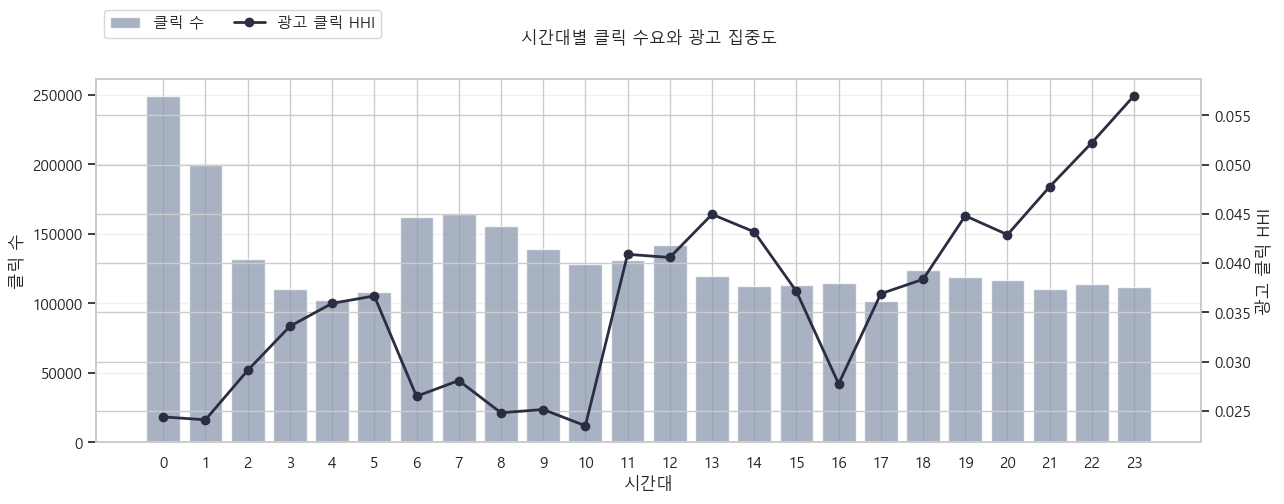

In [130]:
# 규모 분석: 시간대별 수요 집중도 시각화
# 목적:
# - 시간대별 클릭 수요와 광고 클릭 집중도를 함께 확인한다.
# - 범례는 그래프 영역 밖으로 빼서 막대/선을 가리지 않게 한다.

plot_df = (
    hour_concentration
    .sort_values("click_hour")
    .copy()
)

fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.bar(
    plot_df["click_hour"],
    plot_df["click_cnt"],
    color=BASE_COLOR,
    alpha=0.75,
    label="클릭 수",
)

ax1.set_xlabel("시간대")
ax1.set_ylabel("클릭 수")
ax1.set_xticks(range(0, 24))
ax1.grid(axis="y", alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    plot_df["click_hour"],
    plot_df["hhi_ad_click"],
    color=LINE_COLOR,
    marker="o",
    linewidth=2,
    label="광고 클릭 HHI",
)

ax2.set_ylabel("광고 클릭 HHI")

# 범례를 그래프 왼쪽 상단 바깥으로 이동
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

fig.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    bbox_to_anchor=(0.08, 1.02),
    ncol=2,
    frameon=True,
)

plt.title("시간대별 클릭 수요와 광고 집중도", pad=26)
plt.tight_layout()
plt.show()

---
### 6-5. 시간대·요일 다양성

규모가 큰 광고는 특정 시간대에만 의존하기보다 여러 시간대와 요일에서 유입을 확보하는지 확인한다.


엔트로피(분포가 얼마나 고르게 퍼져있는가) 산출방식 : H=−∑p(x)logp(x)    



In [131]:
# 베이스 테이블 생성
div_base = (
    df_fact_clean2
    .with_columns(
        pl.col("ads_idx").cast(pl.Utf8),
        pl.col("click_date").dt.weekday().alias("click_weekday")
    )   # 왼쪽 맞추기
    .join(
        pl.from_pandas(traffic[["ads_idx", "tier"]])
        .with_columns(pl.col("ads_idx").cast(pl.Utf8)),  # 오른쪽 맞추기
        on="ads_idx",
        how="left"
    )
)


div_base = div_base.with_columns(
    pl.col("click_time").cast(pl.Int64).alias("hour")
)

In [132]:
# 시간대 다양성
## 특정 시간에 집중될수록 엔트로피가 낮아진다.
## 골고루 퍼짐 -> 엔트로피 높음

# 광고별 시간 분포
hour_dist = (
    div_base
    .group_by(["ads_idx", "tier", "hour"])
    .agg(pl.len().alias("cnt"))
)

# 비율 계산
hour_dist = hour_dist.with_columns(
    (pl.col("cnt") / pl.col("cnt").sum().over("ads_idx")).alias("ratio")
)

# entropy 계산
hour_entropy = (
    hour_dist
    .with_columns(
        (-pl.col("ratio") * pl.col("ratio").log()).alias("entropy_part")
    )
    .group_by(["ads_idx", "tier"])
    .agg(pl.col("entropy_part").sum().alias("hour_entropy"))
    .to_pandas()
)

In [133]:
# 요일 다양성
weekday_dist = (
    div_base
    .group_by(["ads_idx", "tier", "click_weekday"])
    .agg(pl.len().alias("cnt"))
)

weekday_dist = weekday_dist.with_columns(
    (pl.col("cnt") / pl.col("cnt").sum().over("ads_idx")).alias("ratio")
)

weekday_entropy = (
    weekday_dist
    .with_columns(
        (-pl.col("ratio") * pl.col("ratio").log()).alias("entropy_part")
    )
    .group_by(["ads_idx", "tier"])
    .agg(pl.col("entropy_part").sum().alias("weekday_entropy"))
    .to_pandas()
)

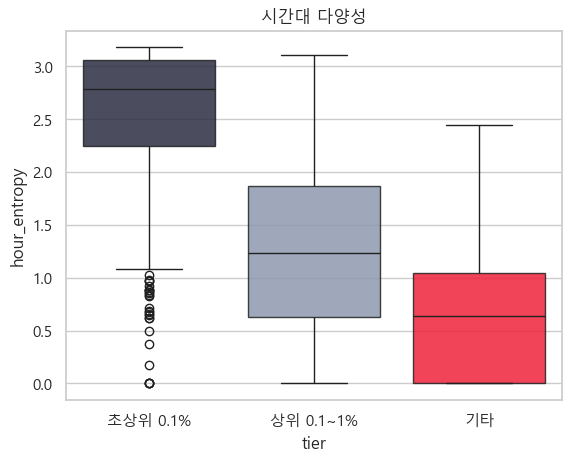

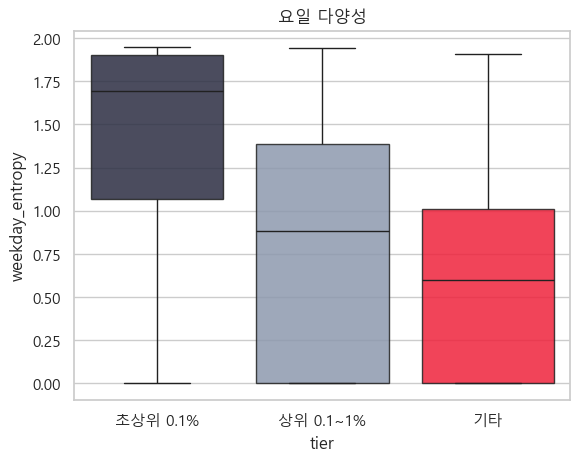

In [134]:
# 시간대 다양성 지표 시각화
ax = sns.boxplot(
    data=hour_entropy,
    x="tier",
    y="hour_entropy",
    order=TIER_ORDER,
)
apply_box_colors(ax)
apply_tier_xticklabels(ax)
plt.title("시간대 다양성")
plt.show()

# 요일 다양성 지표 시각화
ax1 = sns.boxplot(
    data=weekday_entropy,
    x="tier",
    y="weekday_entropy",
    order=TIER_ORDER,
)
apply_box_colors(ax1)
apply_tier_xticklabels(ax1)
plt.title("요일 다양성")
plt.show()


#### 시간대 다양성
- 초상위 0.1% > 상위 0.1~1% > 기타 순으로 나타난다.
- 초상위 0.1% 광고는 특정 시간대에 과도하게 의존하지 않는 경향을 보인다.

#### 요일 다양성
- 초상위 0.1% > 상위 0.1~1% > 기타 순으로 나타난다.
- 초상위 0.1% 광고는 특정 요일에 과도하게 의존하지 않는 경향을 보인다.

#### 규모와 확산성 해석
규모가 큰 광고는 다양한 시간대와 요일에서 트래픽을 확보할 수 있어 확산 가능성이 높다. 반면 기타 구간은 특정 조건에서만 제한적으로 반응하는 경우가 많아 확장 가능성을 보수적으로 해석해야 한다.


### 6-6. 매체 다양성 및 매체 집중도

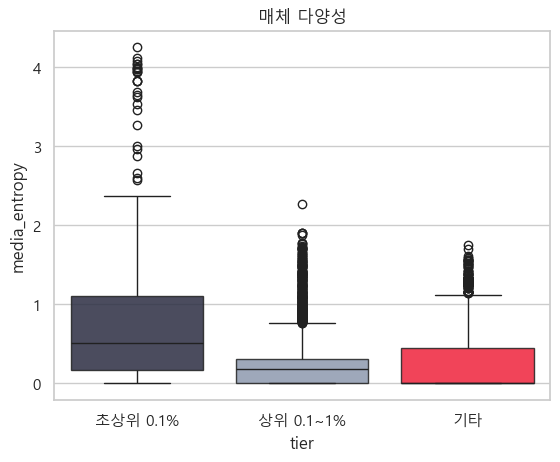

In [135]:
# 매체 다양성
media_dist = (
    div_base
    .group_by(["ads_idx", "tier", "mda_idx"])
    .agg(pl.len().alias("cnt"))
)

media_dist = media_dist.with_columns(
    (pl.col("cnt") / pl.col("cnt").sum().over("ads_idx")).alias("ratio")
)

media_entropy = (
    media_dist
    .with_columns(
        (-pl.col("ratio") * pl.col("ratio").log()).alias("entropy_part")
    )
    .group_by(["ads_idx", "tier"])
    .agg(pl.col("entropy_part").sum().alias("media_entropy"))
    .to_pandas()
)

ax = sns.boxplot(
    data=media_entropy,
    x="tier",
    y="media_entropy",
    order=TIER_ORDER,
)
apply_box_colors(ax)
apply_tier_xticklabels(ax)


plt.title("매체 다양성")
plt.show()


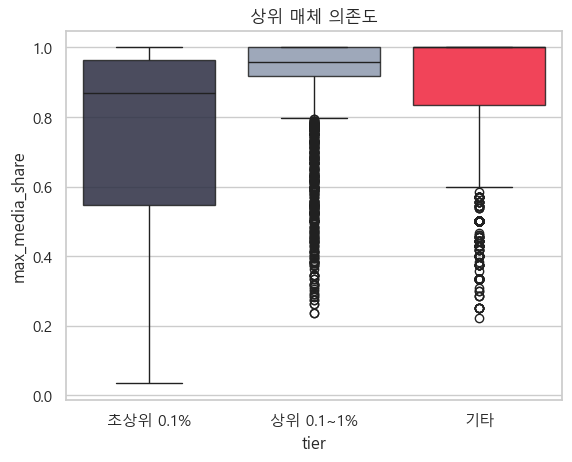

In [136]:
# 매체 집중도

media_concentration = (
    media_dist
    .group_by(["ads_idx", "tier"])
    .agg(
        pl.col("ratio").max().alias("max_media_share")
    )
    .to_pandas()
)

ax = sns.boxplot(
    data=media_concentration,
    x="tier",
    y="max_media_share",
    order=TIER_ORDER,
)

apply_box_colors(ax)
apply_tier_xticklabels(ax)

plt.title("상위 매체 의존도")
plt.show()


#### 6-6-1. 매체 다양성 / 매체 집중도 해석

매체 다양성은 광고가 어디에서 확산되는지 보여준다. 규모가 큰 광고라도 특정 매체에 과도하게 의존하면 운영 리스크가 존재한다.


### 6-7. 유저 다양성

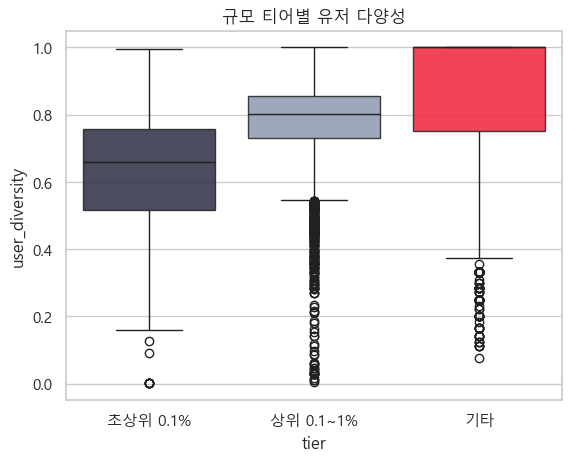

In [137]:
# 유저 다양성 계산용 테이블

user_div = (
    div_base
    .group_by(["ads_idx", "tier"])
    .agg([
        pl.col("dvc_idx").n_unique().alias("unique_users"),
        pl.len().alias("total_click"),
    ])
    .with_columns(
        (pl.col("unique_users") / pl.col("total_click")).alias("user_diversity")
    )
    .to_pandas()
)

ax = sns.boxplot(
    data=user_div,
    x="tier",
    y="user_diversity",
    order=TIER_ORDER,
)

apply_box_colors(ax)
apply_tier_xticklabels(ax)

plt.title("규모 티어별 유저 다양성")
plt.show()


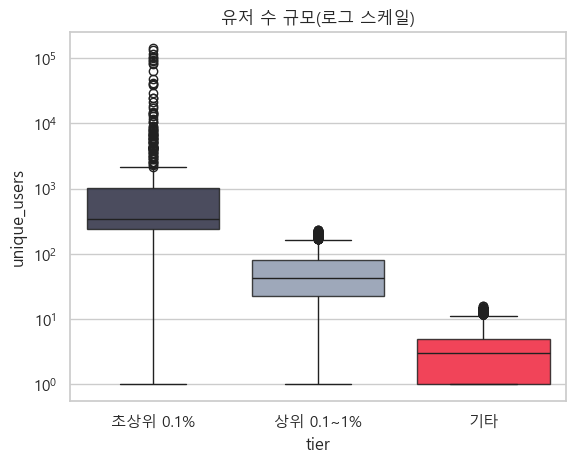

In [138]:
ax = sns.boxplot(
    data=user_div,
    x="tier",
    y="unique_users",
    order=TIER_ORDER,
)
apply_box_colors(ax)
apply_tier_xticklabels(ax)

plt.yscale("log")
plt.title("유저 수 규모(로그 스케일)")
plt.show()


- 유저 다양성: 기타 > 상위 0.1~1% > 초상위 0.1% 순으로 나타난다.
    - 기타 구간은 클릭 유저가 분산되어 보이지만, 절대 유저 규모가 작아 비율만으로 확장성을 판단하기 어렵다.
    - 예를 들어 다양성 비율이 1에 가깝더라도 실제 유저 수가 매우 적으면 운영상 의미는 제한적이다.
    - 초상위 0.1%는 다양성 비율이 중간 수준이며, 재참여 유저가 존재하기 때문으로 해석된다.
- 유저 수 규모: 초상위 0.1% > 상위 0.1~1% > 기타 순으로 나타난다.
- 광고 성과의 차이는 다양성 비율뿐 아니라 실제 유저 수 규모에서 크게 발생한다.

#### 6-7-1. 유저 다양성 해석 기준
- 유저 다양성은 비율보다 실제 규모를 함께 고려해야 한다.


## 7. 운영 후보 분류


앞에서 만든 `ads_eval`, `ads_analysis_base`를 기반으로 반응성, 수익성, 안정성, 규모 후보 지표를 광고 단위로 모은다.

이 표는 다음 장에서 `operation_candidates`를 생성하고 운영 후보를 분류하기 위한 입력 기반으로 사용되며, 실제 점수화 모델은 후속 모델링 단계에서 확정한다.


### 7-1. 축 통합 평가 테이블 생성

In [139]:
axis_eval_base = (
    ads_eval
    .join(
        ads_persistence.select([
            "ads_idx",
            "active_days",
            "active_day_ratio",
        ]),
        on="ads_idx",
        how="left",
    )
)

axis_eval_columns = [
    "ads_idx",
    "ads_name",
    "analysis_ads_type_label",
    "category_name",
    "reward_band",

    "total_click_cnt",
    "total_complete_cnt",
    "total_cvr",

    "total_valid_margin",
    "total_valid_margin_per_click",
    "total_valid_margin_per_complete",

    "active_days",
    "active_day_ratio",
    "delta_stage_cvr",
]

axis_eval_table = axis_eval_base.select(axis_eval_columns)

show_table("축 통합 평가 테이블 미리보기", axis_eval_table.head(10).to_pandas(), n=10)


**축 통합 평가 테이블 미리보기**

,ads_idx,ads_name,analysis_ads_type_label,category_name,reward_band,total_click_cnt,total_complete_cnt,total_cvr,total_valid_margin,total_valid_margin_per_click,total_valid_margin_per_complete,active_days,active_day_ratio,delta_stage_cvr
0,328100,수영복 반바지 커플... (검색 후 퀴즈맞추기) 5988,참여형,간편미션-퀴즈,50원 미만,0,0,NaN,0.00,NaN,NaN,1,NaN,NaN
1,177238,[플레이스 퀴즈] 백만그릇파스타 (14079),참여형,간편미션-퀴즈,50원 미만,0,0,NaN,0.00,NaN,NaN,1,NaN,NaN
2,220489,서울우유맛 원컵 자... (검색 후 퀴즈맞추기) 0437,참여형,간편미션-퀴즈,50원 미만,0,0,NaN,0.00,NaN,NaN,1,NaN,NaN
3,264242,[쇼핑 퀴즈] 오토노스 사무용의자 컴퓨터 책상 의자 TX370 리닛 화이트바디+그레...,참여형,간편미션-퀴즈,50원 미만,0,0,NaN,0.00,NaN,NaN,1,NaN,NaN
4,247735,킹리치 바디필로우 ... (검색 후 퀴즈맞추기) 2143,참여형,간편미션-퀴즈,50원 미만,0,0,NaN,0.00,NaN,NaN,1,NaN,NaN
5,50345,강릉홍게 무한리필 강릉교동택지점 (검색 후 플레이스 저장),참여형,간편미션-퀴즈,50원 미만,0,0,NaN,0.00,NaN,NaN,1,NaN,NaN
6,185039,LS 사다리 접이식... (검색 후 퀴즈맞추기) 5018,참여형,간편미션-퀴즈,50원 미만,0,0,NaN,0.00,NaN,NaN,1,NaN,NaN
7,34774,편편집 청주미평점 (플레이스 URL 입력),참여형,간편미션-퀴즈,50원 미만,0,0,NaN,0.00,NaN,NaN,1,NaN,NaN
8,72115,밀스온 쭈꾸미볶음 맞추기 7.17,참여형,간편미션-퀴즈,50원 미만,0,0,NaN,0.00,NaN,NaN,1,NaN,NaN
9,123763,포항맛집 플레이스 퀴즈 포인트 받기,참여형,간편미션-퀴즈,50원 미만,0,0,NaN,0.00,NaN,NaN,1,NaN,NaN


### 7-2. 운영 후보 분류 기준 및 최종 전략

**분석 질문** : 반응성 / 수익성 / 안정성 / 규모 후보 지표를 결합해 각 광고를 어떻게 운영해야 하는가?

이 장의 운영 후보 분류는 **최종 확정 처분이 아니라 1차 운영 분류**이다.  
즉, 광고별 클릭 규모, CVR, 완료당 마진, 음수 마진, 매체 의존도를 기준으로 먼저 큰 운영 방향을 나누고, 이어지는 운영 리스크 심화 진단에서 D3 재완료율·시간대 의존·비효율 사유를 추가로 점검한다.

**운영 분류 기준**

| 운영 액션 | 기준 | 의미 |
|---|---|---|
| 확대 후보 | 클릭 수, CVR, 완료당 마진이 모두 높고 매체 의존 리스크가 낮음 | 노출 확대 가능 |
| 매체 의존 리스크 후보 | 성과가 특정 매체에 과도하게 의존함 | 매체 분산 또는 대체 매체 확보 필요 |
| 점검 후보 | 클릭 수는 많지만 CVR이 낮음 | 트래픽은 많지만 완료로 이어지지 않음 |
| 시간대/수익성 조정 후보 | CVR은 높지만 완료당 마진이 낮음 | 단가·보상·노출 시간대 조정 필요 |
| 운영 검토 후보 | 음수 마진 또는 음수 마진 비율이 높음 | 마진 구조 재검토 또는 중단 검토 |
| 대시보드 모니터링 | 주요 운영 조건에 즉시 해당하지 않는 광고 | 정기 모니터링 대상 |

운영 후보 분류 결과는 단순 확대보다 점검·수익성 조정·매체 의존 리스크 관리 쪽에 더 무게가 실린다. 
각 액션은 CVR 단독 기준이 아니라 클릭 규모, 완료당 마진, 음수 마진, 매체 의존도를 함께 반영해 해석한다.

운영 검토 후보는 클릭 수 기준과 별개로 음수 마진 또는 음수 마진 비율이 높은 광고를 포함한다.  
이는 표본이 작더라도 손실 구조가 확인된 광고는 운영 검토 대상이 될 수 있기 때문이다.

이어지는 비효율 진단은 이 1차 분류를 뒤집기 위한 것이 아니라, 같은 광고 안에서도 어떤 리스크가 추가로 존재하는지 설명하기 위한 보조 진단이다.

클릭수나 CVR만으로 좋은 광고를 판단하기 어렵기 때문에, 반응성, 수익성, 안정성, 규모를 함께 고려해야 한다. 운영 후보 분류는 최종 처분이 아니라 광고 점수화와 운영 대시보드로 확장하기 위한 1차 판단 기준이다.


In [140]:
# 운영 후보 분류용 통합 테이블
# - 광고 성과: ad_df
# - 마진 지표: finance_clean1의 ive_margin을 ads_idx 기준으로 집계
# - 매체 의존도: 앞 셀에서 생성한 ad_top1_media 사용
ad_base = (
    ad_df
    .merge(
        ad_margin_summary[["ads_idx", "total_margin", "margin_per_complete", "negative_margin_pct"]],
        on="ads_idx",
        how="left",
    )
    .merge(
        ad_top1_media[["ads_idx", "top1_mda_idx", "top1_media_share_pct"]],
        on="ads_idx",
        how="left",
    )
)

valid_ads = ad_base[ad_base["click_cnt"] >= MIN_OPERATION_CLICKS].copy()

cvr_q25 = valid_ads["cvr_pct"].quantile(0.25)
cvr_q75 = valid_ads["cvr_pct"].quantile(0.75)
margin_q25 = valid_ads["margin_per_complete"].quantile(0.25)
margin_q75 = valid_ads["margin_per_complete"].quantile(0.75)
click_q75 = valid_ads["click_cnt"].quantile(0.75)



In [141]:
operation_candidates = ad_base.copy()

operation_candidates["is_valid_volume"] = operation_candidates["click_cnt"] >= MIN_OPERATION_CLICKS
operation_candidates["is_high_cvr"] = operation_candidates["cvr_pct"] >= cvr_q75
operation_candidates["is_low_cvr"] = operation_candidates["cvr_pct"] <= cvr_q25
operation_candidates["is_high_margin"] = operation_candidates["margin_per_complete"] >= margin_q75
operation_candidates["is_low_margin"] = operation_candidates["margin_per_complete"] <= margin_q25
operation_candidates["is_negative_margin_risk"] = operation_candidates["negative_margin_pct"] >= 30
operation_candidates["is_media_dependency_risk"] = operation_candidates["top1_media_share_pct"] >= 80

conditions = [
    (
        operation_candidates["is_valid_volume"]
        & operation_candidates["is_high_cvr"]
        & operation_candidates["is_high_margin"]
        & (operation_candidates["total_margin"] > 0)
        & (~operation_candidates["is_media_dependency_risk"].fillna(False))
    ),
    (
        operation_candidates["is_valid_volume"]
        & operation_candidates["is_media_dependency_risk"].fillna(False)
        & (operation_candidates["total_margin"] > 0)
    ),
    (
        operation_candidates["is_valid_volume"]
        & operation_candidates["is_low_cvr"]
        & (operation_candidates["click_cnt"] >= click_q75)
    ),
    (
        operation_candidates["is_negative_margin_risk"].fillna(False)
        | (operation_candidates["total_margin"] < 0)
    ),
    (
        operation_candidates["is_valid_volume"]
        & operation_candidates["is_high_cvr"]
        & operation_candidates["is_low_margin"]
    ),
]

choices = [
    "확대 후보",
    "매체 의존 리스크 후보",
    "점검 후보",
    "운영 검토 후보",
    "시간대/수익성 조정 후보",
]

operation_candidates["운영 액션"] = np.select(
    conditions,
    choices,
    default="대시보드 모니터링",
)


### 7-3. 운영 액션별 요약

In [142]:
# 운영 액션별 요약
# - 운영 액션별 대표 CVR은 광고별 CVR 평균이 아니라 집계CVR을 사용한다.
# - 집계CVR = 해당 운영 액션 그룹의 총완료수 / 총클릭수 * 100
# - CVR만으로 판단하지 않기 위해 total_margin, avg_margin_per_complete도 함께 확인한다.

action_summary = (
    operation_candidates
    .groupby("운영 액션")
    .agg(
        ads_cnt=("ads_idx", "nunique"),
        click_cnt=("click_cnt", "sum"),
        complete_cnt=("complete_cnt", "sum"),
        total_margin=("total_margin", "sum"),
        avg_margin_per_complete=("margin_per_complete", "mean"),
    )
    .reset_index()
)

action_summary["집계CVR"] = safe_divide(
    action_summary["complete_cnt"],
    action_summary["click_cnt"],
    100,
)

action_summary = (
    action_summary[
        [
            "운영 액션",
            "ads_cnt",
            "click_cnt",
            "complete_cnt",
            "집계CVR",
            "total_margin",
            "avg_margin_per_complete",
        ]
    ]
    .sort_values("ads_cnt", ascending=False)
)

action_summary_display = action_summary.rename(
    columns={
        "ads_cnt": "광고수",
        "click_cnt": "클릭수",
        "complete_cnt": "완료수",
        "total_margin": "총마진",
        "avg_margin_per_complete": "평균 완료당 마진",
    }
)

show_table("운영 후보 요약표", action_summary_display, n=20)

**운영 후보 요약표**

,운영 액션,광고수,클릭수,완료수,집계CVR,총마진,평균 완료당 마진
0,대시보드 모니터링,3490,2653784,1282439,48.32,"179,912,106.00",304.64
3,운영 검토 후보,78,15563,3380,21.72,"-1,241,152.00",-287.62
1,매체 의존 리스크 후보,43,204093,51170,25.07,"156,902,391.00","5,907.62"
4,점검 후보,9,210618,4601,2.18,"1,103,329.00",842.11
2,시간대/수익성 조정 후보,8,143991,106780,74.16,"4,049,091.00",32.44


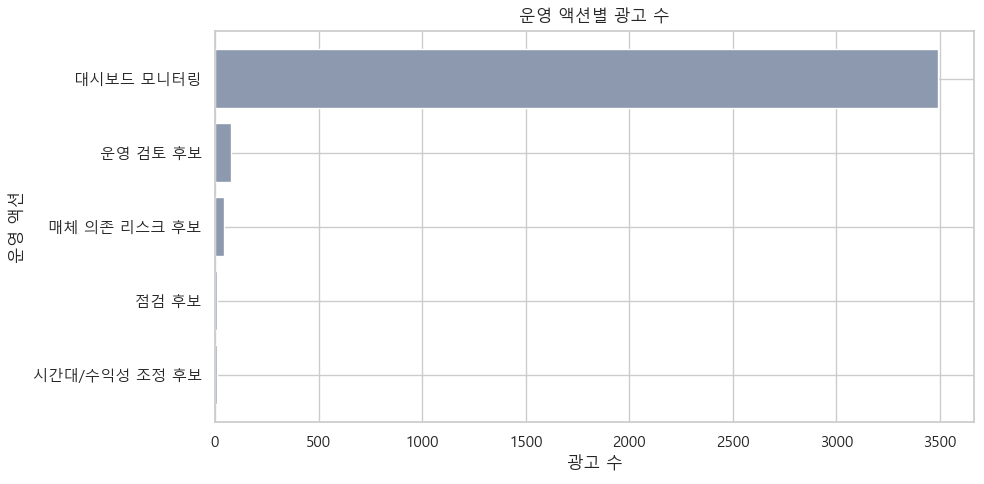

In [143]:
plot_action = action_summary.sort_values("ads_cnt", ascending=True)

bar_colors = get_plot_colors(len(plot_action))

plt.figure(figsize=(10, 5))
plt.barh(plot_action["운영 액션"], plot_action["ads_cnt"], color=bar_colors)
plt.title("운영 액션별 광고 수")
plt.xlabel("광고 수")
plt.ylabel("운영 액션")
plt.tight_layout()
plt.show()

operation_candidates.to_csv(
    OUTPUT_DIR / "operation_candidates.csv",
    index=False,
    encoding="utf-8-sig",
)


대시보드 모니터링은 문제가 없다는 뜻이 아니라, 현재 1차 운영 액션 기준에 즉시 걸리지 않은 광고군이다. 이후 비효율 플래그나 대시보드 지표 변화에 따라 점검 대상으로 이동할 수 있다.

### 7-4. 운영 리스크 심화 진단

운영 후보 분류의 근거를 구체화하기 위해 비효율 광고와 시간대별 수요 집중도를 확인한다.  
새로운 분류 체계를 만드는 것이 아니라, 기존 운영 액션에 대한 보조 진단 근거를 추가하는 파트이다.

운영 후보 분류 파트의 시간대 분석은 특정 시간대에 과도하게 의존하는 광고를 운영 리스크 후보로 분류하기 위한 목적이다. 반응성 파트의 시간대별 CVR·CTIT 분석이나 규모 파트의 시간대별 트래픽 집중도 분석과 역할이 다르다.

따라서 `대시보드 모니터링`으로 분류된 광고라도 세부 비효율 사유가 확인될 수 있다.  
이 경우 “문제가 없다”는 의미가 아니라, 7장의 1차 분류 기준에서는 별도 액션에 걸리지 않았지만 본 절의 세부 리스크 플래그로 추가 점검할 수 있다는 의미로 해석한다.


첫 완료율은 높지만 D3 재완료율이 낮은 광고는 재참여 유도 후보로 본다. 단순 재노출보다 데일리 참여 문구, 다음날 추가 포인트, 재방문 리마인드 실험이 필요하다.

예시: 내일 다시 방문하면 추가 포인트를 받을 수 있어요.


### 7-5. 비효율 광고 진단 플래그

**분석 질문** : 어떤 광고가 클릭, 완료, 재참여, 시간대 의존, 매체 의존, 수익성 측면에서 운영 점검이 필요한가?

**사용 테이블** :  
- `operation_candidates` : 광고 단위 운영 후보 분류 결과  
- `completed` / `d3_recomplete` : 첫 완료 후 D3 재완료율 계산  
- `main_funnel_work` : 광고별 시간대 의존도 계산  

**핵심 기준** :  
- 클릭은 많지만 CVR이 낮은 광고  
- 첫 완료는 발생하지만 D3 재완료율이 낮은 광고  
- 특정 시간대에 클릭 또는 완료가 과도하게 집중된 광고  
- 특정 매체 의존도가 높은 광고  
- 완료당 마진이 낮거나 총마진이 음수인 광고  

**운영 연결** : 메인 슬롯 노출 축소, 광고 조건 점검, 온보딩 후보 재검토, 시간대 타겟 운영, 수익성 조정, 매체 의존 리스크 분류에 활용한다.


In [144]:
# 첫 완료 광고 기준 D3 재완료율 분석
# - 첫 완료 광고: dvc_idx별 regdate, click_date_dt 기준 첫 번째 완료 광고
# - D3 재완료 유저: 앞에서 만든 d3_recomplete 결과 재사용

first_complete_ad_base = completed[
    ["dvc_idx", "ads_idx", "regdate", "click_date_dt"]
].copy()

first_complete_ad = (
    first_complete_ad_base
    .sort_values(["dvc_idx", "regdate", "click_date_dt"])
    .drop_duplicates("dvc_idx")
    [["dvc_idx", "ads_idx"]]
)

d3_recomplete_user = d3_recomplete[["dvc_idx"]].drop_duplicates().copy()
d3_recomplete_user["d3_recomplete_flag"] = 1

first_complete_ad = first_complete_ad.merge(
    d3_recomplete_user,
    on="dvc_idx",
    how="left",
)

first_complete_ad["d3_recomplete_flag"] = (
    first_complete_ad["d3_recomplete_flag"]
    .fillna(0)
    .astype("int8")
)

ad_d3 = (
    first_complete_ad
    .groupby("ads_idx")
    .agg(
        first_complete_user_cnt=("dvc_idx", "count"),
        d3_recomplete_user_cnt=("d3_recomplete_flag", "sum"),
    )
    .reset_index()
)

ad_d3["d3_recomplete_rate"] = safe_divide(
    ad_d3["d3_recomplete_user_cnt"],
    ad_d3["first_complete_user_cnt"],
    100,
)


In [145]:
# 시간대 의존도 기반 운영 리스크 분석
# 목적:
# - 광고별 클릭/완료가 특정 시간대에 과도하게 몰리는지 확인한다.
#
# 기준:
# - top_click_hour: 광고별 클릭이 가장 많이 발생한 시간대
# - top_hour_click_share_pct: 광고 전체 클릭 중 top1 시간대 클릭 비중
# - top_hour_complete_share_pct: 광고 전체 완료 중 top1 시간대 완료 비중

ad_hour = (
    main_funnel_work
    .groupby(["ads_idx", "click_hour"])
    .agg(
        hour_click_cnt=("click_key", "count"),
        hour_complete_cnt=("is_completed", "sum"),
    )
    .reset_index()
)

ad_hour_total = (
    ad_hour
    .groupby("ads_idx")
    .agg(
        ad_click_cnt=("hour_click_cnt", "sum"),
        ad_complete_cnt=("hour_complete_cnt", "sum"),
    )
    .reset_index()
)

ad_top_hour = (
    ad_hour
    .sort_values(["ads_idx", "hour_click_cnt"], ascending=[True, False])
    .drop_duplicates("ads_idx")
    .rename(
        columns={
            "click_hour": "top_click_hour",
            "hour_click_cnt": "top_hour_click_cnt",
            "hour_complete_cnt": "top_hour_complete_cnt",
        }
    )
)

ad_time_dependency = ad_top_hour.merge(
    ad_hour_total,
    on="ads_idx",
    how="left",
)

ad_time_dependency["top_hour_click_share_pct"] = safe_divide(
    ad_time_dependency["top_hour_click_cnt"],
    ad_time_dependency["ad_click_cnt"],
    100,
)

ad_time_dependency["top_hour_complete_share_pct"] = safe_divide(
    ad_time_dependency["top_hour_complete_cnt"],
    ad_time_dependency["ad_complete_cnt"],
    100,
)

ad_time_dependency_display = ad_time_dependency.merge(
    ad_df[["ads_idx", "ads_name", "click_cnt", "complete_cnt", "cvr_pct"]],
    on="ads_idx",
    how="left",
)

ad_time_dependency_display = ad_time_dependency_display[
    ad_time_dependency_display["click_cnt"] >= 1000
].copy()

# show_table(
#     "광고별 시간대 의존도(클릭 1000건 이상)",
#     ad_time_dependency_display.sort_values("top_hour_click_share_pct", ascending=False),
#     n=10,
# )

In [146]:
# 비효율 광고 진단 플래그
# 목적:
# - 기존 operation_candidates에 비효율 사유를 추가한다.
#
# 진단 대상:
# - 운영 조정이 의미 있는 click_cnt >= 1000 광고 중심
#
# 진단 유형:
# 1) 클릭은 많지만 CVR 낮음
# 2) 첫 완료 후 D3 재완료 낮음
# 3) 특정 시간대 의존
# 4) 특정 매체 의존
# 5) 수익성 낮음

inefficiency = (
    operation_candidates
    .merge(
        ad_d3[["ads_idx", "first_complete_user_cnt", "d3_recomplete_rate"]],
        on="ads_idx",
        how="left",
    )
    .merge(
        ad_time_dependency[
            [
                "ads_idx",
                "top_click_hour",
                "top_hour_click_share_pct",
                "top_hour_complete_share_pct",
            ]
        ],
        on="ads_idx",
        how="left",
    )
)

d3_base = inefficiency[
    inefficiency["is_valid_volume"]
    & (inefficiency["first_complete_user_cnt"] >= MIN_FIRST_COMPLETE_USERS)
].copy()

d3_low_cut = d3_base["d3_recomplete_rate"].quantile(0.25)


In [147]:
# 클릭은 많지만 완료율이 낮은 광고
inefficiency["flag_click_waste"] = (
    inefficiency["is_valid_volume"]
    & inefficiency["is_low_cvr"]
    & (inefficiency["click_cnt"] >= click_q75)
)

# 첫 완료는 발생하지만 D3 재완료율이 낮은 광고
inefficiency["flag_low_recomplete"] = (
    inefficiency["is_valid_volume"]
    & (inefficiency["first_complete_user_cnt"] >= MIN_FIRST_COMPLETE_USERS)
    & (inefficiency["d3_recomplete_rate"] <= d3_low_cut)
)

# 특정 시간대에 클릭 또는 완료가 몰리는 광고
inefficiency["flag_time_dependency"] = (
    inefficiency["is_valid_volume"]
    & (
        (inefficiency["top_hour_click_share_pct"] >= 30)
        | (inefficiency["top_hour_complete_share_pct"] >= 35)
    )
)

# 특정 매체에 의존하는 광고
inefficiency["flag_media_dependency"] = (
    inefficiency["is_valid_volume"]
    & inefficiency["is_media_dependency_risk"]
)

# 수익성이 낮은 광고
inefficiency["flag_low_profit"] = (
    inefficiency["is_valid_volume"]
    & (
        inefficiency["is_low_margin"]
        | (inefficiency["total_margin"] < 0)
    )
)

inefficiency["비효율 사유"] = ""

inefficiency.loc[
    inefficiency["flag_click_waste"],
    "비효율 사유"
] += "클릭은 많지만 CVR 낮음; "

inefficiency.loc[
    inefficiency["flag_low_recomplete"],
    "비효율 사유"
] += "첫 완료 후 D3 재완료 낮음; "

inefficiency.loc[
    inefficiency["flag_time_dependency"],
    "비효율 사유"
] += "특정 시간대 의존; "

inefficiency.loc[
    inefficiency["flag_media_dependency"],
    "비효율 사유"
] += "특정 매체 의존; "

inefficiency.loc[
    inefficiency["flag_low_profit"],
    "비효율 사유"
] += "수익성 낮음; "

inefficiency["비효율 사유"] = inefficiency["비효율 사유"].str.rstrip("; ")


### 7-6. 비효율 광고 진단 요약

In [148]:
reason_specs = [
    ("flag_click_waste", "클릭은 많지만 CVR 낮음"),
    ("flag_low_recomplete", "첫 완료 후 D3 재완료 낮음"),
    ("flag_time_dependency", "특정 시간대 의존"),
    ("flag_media_dependency", "특정 매체 의존"),
    ("flag_low_profit", "수익성 낮음"),
]

summary_rows = []

for flag_col, label in reason_specs:
    target = inefficiency[inefficiency[flag_col]].copy()

    target_click = target["click_cnt"].sum()
    target_complete = target["complete_cnt"].sum()
    target_cvr = target_complete / target_click * 100

    summary_rows.append({
        "비효율 유형": label,
        "광고 수": target["ads_idx"].nunique(),
        "총 클릭 수": target_click,
        "총 완료 수": target_complete,
        "집계 CVR": target_cvr,
        "평균 완료당 마진": target["margin_per_complete"].mean(),
        "평균 D3 재완료율": target["d3_recomplete_rate"].mean(),
        "평균 최다 클릭 시간대 비중": target["top_hour_click_share_pct"].mean(),
        "평균 최대 기여 매체 비중": target["top1_media_share_pct"].mean(),
    })

inefficiency_summary = pd.DataFrame(summary_rows)

show_table("비효율 광고 진단 요약", inefficiency_summary, n=10)


**비효율 광고 진단 요약**

,비효율 유형,광고 수,총 클릭 수,총 완료 수,집계 CVR,평균 완료당 마진,평균 D3 재완료율,평균 최다 클릭 시간대 비중,평균 최대 기여 매체 비중
0,클릭은 많지만 CVR 낮음,14,284725,5760,2.02,"1,170.22",9.66,6.91,65.19
1,첫 완료 후 D3 재완료 낮음,26,594673,220001,37.00,77.53,1.12,19.25,34.42
2,특정 시간대 의존,27,119040,63702,53.51,371.01,7.83,56.47,54.67
3,특정 매체 의존,43,204093,51170,25.07,"5,907.62",20.58,19.88,94.76
4,수익성 낮음,38,1530969,780326,50.97,-12.61,17.92,18.29,60.33


In [149]:
show_table(
    "비효율 광고 대표 목록",
    inefficiency[inefficiency["비효율 사유"] != ""][
        [
            "ads_idx",
            "ads_name",
            type_col,
            "click_cnt",
            "complete_cnt",
            "cvr_pct",
            "margin_per_complete",
            "first_complete_user_cnt",
            "d3_recomplete_rate",
            "top_click_hour",
            "top_hour_click_share_pct",
            "top1_media_share_pct",
            "운영 액션",
            "비효율 사유",
        ]
    ].sort_values("click_cnt", ascending=False),
    n=10,  # 필요하면 n 값만 조절
)


**비효율 광고 대표 목록**

,ads_idx,ads_name,analysis_ads_type_label,click_cnt,complete_cnt,cvr_pct,margin_per_complete,first_complete_user_cnt,d3_recomplete_rate,top_click_hour,top_hour_click_share_pct,top1_media_share_pct,운영 액션,비효율 사유
2911,440167,[오픈하기] KB차차차,실행형,205304,31256,15.22,60.05,"20,454.00",0.66,17,4.69,31.10,대시보드 모니터링,첫 완료 후 D3 재완료 낮음
1818,444349,조조의 꿈,실행형,195134,98107,50.28,41.07,"38,302.00",36.52,23,7.37,38.54,대시보드 모니터링,수익성 낮음
3138,445047,K데몬헌터스,실행형,192061,117469,61.16,41.23,"41,279.00",12.82,0,10.35,39.09,대시보드 모니터링,수익성 낮음
2226,444350,조조의 꿈,설치형,187351,80255,42.84,23.80,"38,534.00",10.40,12,9.42,32.39,대시보드 모니터링,수익성 낮음
2039,430776,붉은 도시,설치형,151930,60000,39.49,21.37,"23,792.00",3.09,7,5.47,49.00,대시보드 모니터링,수익성 낮음
2461,430777,붉은 도시,실행형,136859,60262,44.03,41.27,"37,767.00",4.99,0,10.16,37.10,대시보드 모니터링,수익성 낮음
2228,445046,K데몬헌터스,설치형,132826,66197,49.84,21.18,"28,781.00",4.15,1,9.51,21.81,대시보드 모니터링,수익성 낮음
3139,439552,헬좀비,설치형,128977,69939,54.23,21.73,"45,588.00",2.90,1,6.58,43.67,대시보드 모니터링,수익성 낮음
231,438608,헬좀비,실행형,117692,85349,72.52,41.16,"58,419.00",4.10,0,8.91,26.97,시간대/수익성 조정 후보,수익성 낮음
443,133653,KB차차차,실행형,75473,2400,3.18,65.07,"1,440.00",1.94,15,4.61,12.49,점검 후보,클릭은 많지만 CVR 낮음; 첫 완료 후 D3 재완료 낮음


### 7-7. 비효율 유형별 광고 수 시각화

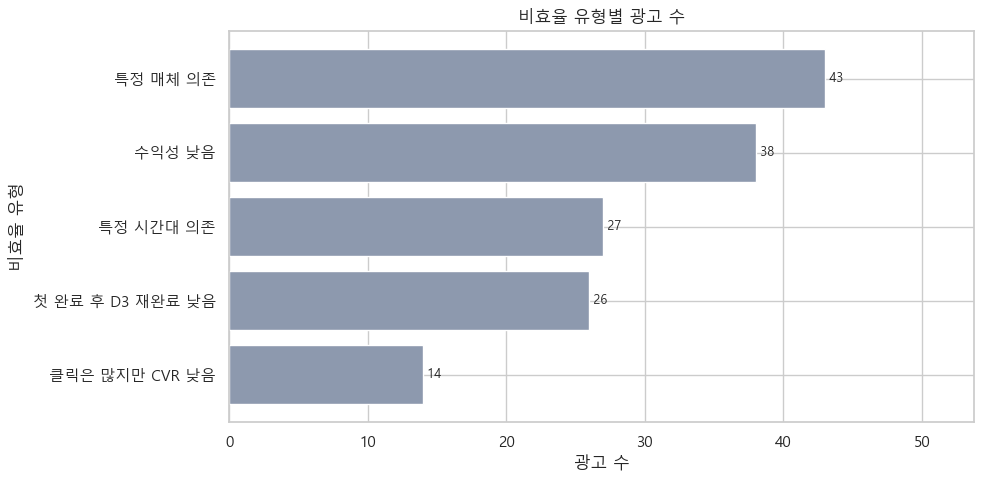

In [150]:
# 비효율 광고 진단 시각화
# 목적:
# - 비효율 유형별 광고 수를 확인한다.
# - 클릭 규모와 세부 지표는 위 요약표에서 함께 확인한다.

plot_df = (
    inefficiency_summary
    .sort_values("광고 수", ascending=True)
    .copy()
)

bar_colors = get_plot_colors(len(plot_df))

plt.figure(figsize=(10, 5))
plt.barh(
    plot_df["비효율 유형"],
    plot_df["광고 수"],
    color=bar_colors,
)
plt.title("비효율 유형별 광고 수")
plt.xlabel("광고 수")
plt.ylabel("비효율 유형")
label_barh(plt.gca(), plot_df["광고 수"])
plt.tight_layout()
plt.show()

## 8. 결론

전체 클릭 수는 3,181,777건, 완료 수는 1,383,784건으로 전체 CVR은 43.49%였다.
하지만 전체 CVR만으로는 광고 운영 가치를 판단하기 어렵다.

세부 광고 단위로 보면 클릭이 많아도 완료로 이어지지 않는 광고가 있었다.
‘클릭은 많지만 CVR 낮음’ 유형은 14개 광고에서 284,725건의 클릭이 발생했지만 완료는 5,760건에 그쳤고, 집계 CVR은 2.02%였다.
즉, 트래픽을 많이 가져와도 실제 전환 성과가 낮으면 운영 가치가 높다고 보기 어렵다.

반대로 완료율이 높아도 수익성이 낮은 광고도 있었다.
‘수익성 낮음’ 유형은 38개 광고에서 1,530,969건의 클릭과 780,326건의 완료가 발생해 집계 CVR은 50.97%였지만, 평균 완료당 마진은 -12.61로 나타났다.
이 결과는 CVR만 보고 광고를 확대하면 손실 구조를 키울 수 있다는 점을 보여준다.

또한 성과가 특정 조건에 지나치게 의존하는 광고도 확인됐다.
특정 시간대 의존 유형은 평균 최다 클릭 시간대 비중이 56.47%였고, 특정 매체 의존 유형은 평균 최대 기여 매체 비중이 94.76%였다.
성과가 좋아 보여도 특정 시간대나 특정 매체에 몰려 있으면 운영 리스크가 크다.

재참여 측면에서도 한계가 있었다.
첫 완료 후 D3 재완료 낮음 유형은 26개 광고에서 594,673건의 클릭과 220,001건의 완료가 발생했지만, 평균 D3 재완료율은 1.12%에 그쳤다.
첫 완료는 만들 수 있어도 반복 참여로 이어지지 않는 광고가 존재한다는 뜻이다.

규모 측면에서는 상위 소수 광고가 전체 트래픽의 대부분을 차지했다.
따라서 규모가 큰 광고는 단순히 클릭이 많은 광고가 아니라, 전체 운영 성과를 좌우하는 핵심 관리 대상이다.

결론적으로 클릭 수는 운영 판단의 출발점일 뿐이다.
운영 가치가 높은 광고는 클릭이 완료로 이어지고, 완료가 마진으로 남고, 성과가 특정 시간대나 매체에 과도하게 의존하지 않으며, 일정 규모 이상에서 안정적으로 유지되는 광고다.

이번 EDA의 핵심 인사이트는 광고를 단일 순위로 평가하면 안 된다는 점이다.
클릭은 많지만 전환이 낮은 광고, 전환은 좋지만 수익성이 낮은 광고, 특정 시간대나 매체에 의존하는 광고, 첫 완료 이후 재참여가 약한 광고는 각각 다른 방식으로 관리해야 한다.

In [151]:
# 이상치 기준별 핵심 KPI 변화 비교

behavior_raw = main_funnel_for_eda.select([
    pl.col("ads_idx").n_unique().alias("광고수"),
    pl.len().alias("클릭수"),
    pl.col("is_completed").cast(pl.Int64, strict=False).sum().alias("완료수"),
    pl.col("dvc_idx").n_unique().alias("유저수"),
    pl.col("mda_idx").n_unique().alias("매체수"),
]).to_pandas().iloc[0]

behavior_clean = df_fact_clean2.select([
    pl.col("ads_idx").n_unique().alias("광고수"),
    pl.len().alias("클릭수"),
    pl.col("is_completed").cast(pl.Int64, strict=False).sum().alias("완료수"),
    pl.col("dvc_idx").n_unique().alias("유저수"),
    pl.col("mda_idx").n_unique().alias("매체수"),
]).to_pandas().iloc[0]

behavior_raw["집계 CVR(%)"] = behavior_raw["완료수"] / behavior_raw["클릭수"] * 100
behavior_clean["집계 CVR(%)"] = behavior_clean["완료수"] / behavior_clean["클릭수"] * 100

profit = mart.select([
    pl.col("click_cnt").sum().alias("클릭수"),
    pl.col("complete_cnt").sum().alias("완료수"),
    pl.col("daily_observed_margin").sum().alias("포함_총마진"),
    pl.col("daily_valid_margin").sum().alias("제외_총마진"),
]).to_pandas().iloc[0]

rows = []

for metric in ["광고수", "클릭수", "완료수", "유저수", "매체수", "집계 CVR(%)"]:
    rows.append({
        "구분": "반응성/규모",
        "이상치 기준": "remove_cond2_flag",
        "지표": metric,
        "적용 전": behavior_raw[metric],
        "적용 후": behavior_clean[metric],
    })

profit_before = {
    "총마진": profit["포함_총마진"],
    "클릭당 마진": profit["포함_총마진"] / profit["클릭수"],
    "완료당 마진": profit["포함_총마진"] / profit["완료수"],
}

profit_after = {
    "총마진": profit["제외_총마진"],
    "클릭당 마진": profit["제외_총마진"] / profit["클릭수"],
    "완료당 마진": profit["제외_총마진"] / profit["완료수"],
}

for metric in ["총마진", "클릭당 마진", "완료당 마진"]:
    rows.append({
        "구분": "수익성",
        "이상치 기준": "is_finance_anomaly",
        "지표": metric,
        "적용 전": profit_before[metric],
        "적용 후": profit_after[metric],
    })

anomaly_kpi_compare = pd.DataFrame(rows)

anomaly_kpi_compare["변화량"] = (
    anomaly_kpi_compare["적용 후"]
    - anomaly_kpi_compare["적용 전"]
)

anomaly_kpi_compare["증감 방향"] = np.where(
    anomaly_kpi_compare["변화량"] > 0,
    "증가",
    np.where(anomaly_kpi_compare["변화량"] < 0, "감소", "변화 없음")
)

anomaly_kpi_compare[
    ["적용 전", "적용 후", "변화량"]
] = anomaly_kpi_compare[
    ["적용 전", "적용 후", "변화량"]
].round(2)

show_table(
    "이상치 기준별 핵심 KPI 변화 비교",
    anomaly_kpi_compare,
    n=20,
)

**이상치 기준별 핵심 KPI 변화 비교**

,구분,이상치 기준,지표,적용 전,적용 후,변화량,증감 방향
0,반응성/규모,remove_cond2_flag,광고수,"9,517.00","9,517.00",0.00,변화 없음
1,반응성/규모,remove_cond2_flag,클릭수,"16,854,865.00","3,181,777.00","-13,673,088.00",감소
2,반응성/규모,remove_cond2_flag,완료수,"1,474,950.00","1,383,784.00","-91,166.00",감소
3,반응성/규모,remove_cond2_flag,유저수,"992,489.00","871,616.00","-120,873.00",감소
4,반응성/규모,remove_cond2_flag,매체수,189.00,189.00,0.00,변화 없음
5,반응성/규모,remove_cond2_flag,집계 CVR(%),8.75,43.49,34.74,증가
6,수익성,is_finance_anomaly,총마진,"341,873,394.00","342,894,036.00","1,020,642.00",증가
7,수익성,is_finance_anomaly,클릭당 마진,107.45,107.77,0.32,증가
8,수익성,is_finance_anomaly,완료당 마진,247.06,247.79,0.74,증가


In [152]:
# 운영 액션별 이상치 플래그 포함 광고수
# - 최종 operation_candidates 안에 이상치 플래그 이력이 있는 광고가 얼마나 포함되어 있는지 확인한다.

ad_anomaly_flag = (
    main_funnel_for_eda
    .with_columns(pl.col("ads_idx").cast(pl.Utf8))
    .group_by("ads_idx")
    .agg([
        pl.col("remove_cond2_flag").any().alias("remove_cond2_flag_포함"),
        pl.col("is_finance_anomaly").any().alias("is_finance_anomaly_포함"),
    ])
    .to_pandas()
)

operation_anomaly_check = operation_candidates.copy()
operation_anomaly_check["ads_idx"] = operation_anomaly_check["ads_idx"].astype(str)

operation_anomaly_check = (
    operation_anomaly_check
    .merge(ad_anomaly_flag, on="ads_idx", how="left")
)

flag_cols = [
    "remove_cond2_flag_포함",
    "is_finance_anomaly_포함",
]

operation_anomaly_check[flag_cols] = (
    operation_anomaly_check[flag_cols]
    .fillna(False)
    .astype(bool)
)

operation_anomaly_check["이상치_플래그_포함"] = (
    operation_anomaly_check["remove_cond2_flag_포함"]
    | operation_anomaly_check["is_finance_anomaly_포함"]
)

operation_action_anomaly_summary = (
    operation_anomaly_check
    .groupby("운영 액션")
    .agg(
        전체_광고수=("ads_idx", "nunique"),
        remove_cond2_flag_포함_광고수=("remove_cond2_flag_포함", "sum"),
        is_finance_anomaly_포함_광고수=("is_finance_anomaly_포함", "sum"),
        이상치_플래그_포함_광고수=("이상치_플래그_포함", "sum"),
    )
    .reset_index()
)

operation_action_anomaly_summary["이상치_플래그_포함_비율(%)"] = (
    operation_action_anomaly_summary["이상치_플래그_포함_광고수"]
    / operation_action_anomaly_summary["전체_광고수"]
    * 100
).round(2)

operation_action_anomaly_summary = operation_action_anomaly_summary.sort_values(
    "전체_광고수",
    ascending=False,
)

show_table(
    "운영 액션별 이상치 플래그 포함 광고수",
    operation_action_anomaly_summary,
    n=20,
)

**운영 액션별 이상치 플래그 포함 광고수**

,운영 액션,전체_광고수,remove_cond2_flag_포함_광고수,is_finance_anomaly_포함_광고수,이상치_플래그_포함_광고수,이상치_플래그_포함_비율(%)
0,대시보드 모니터링,3490,741,1,742,21.26
3,운영 검토 후보,78,44,78,78,100.00
1,매체 의존 리스크 후보,43,29,0,29,67.44
4,점검 후보,9,3,0,3,33.33
2,시간대/수익성 조정 후보,8,1,0,1,12.50
